# Analysis of different implementations to improve MPPI performance

In [45]:
# --- diagnostic: confirm which Python the kernel is running and time each import ---
import sys, time
print("python:", sys.executable)
print("prefix:", sys.prefix)

def _t(label, fn):
    t0 = time.perf_counter()
    fn()
    print(f"{label:50s} {time.perf_counter() - t0:7.3f} s")

_t("import numpy",                       lambda: __import__("numpy"))
_t("import mujoco",                      lambda: __import__("mujoco"))
_t("import mujoco.rollout",              lambda: __import__("mujoco.rollout"))
_t("from analytic_mppi.tasks ...",       lambda: __import__("analytic_mppi.tasks", fromlist=["make_task"]))
_t("from analytic_mppi.dynamics ...",    lambda: __import__("analytic_mppi.dynamics", fromlist=["MujocoBackend"]))
_t("from analytic_mppi.controllers ...", lambda: __import__("analytic_mppi.controllers", fromlist=["SAMPLING_CONTROLLERS"]))

python: /Users/abin_george/Basis/code/Analytic-MPPI/.venv/bin/python
prefix: /Users/abin_george/Basis/code/Analytic-MPPI/.venv
import numpy                                         0.000 s
import mujoco                                        0.000 s
import mujoco.rollout                                0.000 s
from analytic_mppi.tasks ...                         0.000 s
from analytic_mppi.dynamics ...                      0.000 s
from analytic_mppi.controllers ...                   0.000 s


In [46]:
import numpy as np

from analytic_mppi.tasks import make_task
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import SAMPLING_CONTROLLERS

In [47]:
# shared task + backend (swap TASK_NAME to test on a different env)
TASK_NAME = "pendulum"

task = make_task(TASK_NAME)
backend = MujocoBackend(task.model_path)
print(f"task={TASK_NAME}  nq={task.nq} nv={task.nv} nu={task.nu} dt={backend.dt}")

task=pendulum  nq=1 nv=1 nu=1 dt=0.02


In [48]:
# kwargs shared by every SamplingController subclass
COMMON = dict(
    num_samples=5,
    num_knots=11,
    plan_horizon=1.0,
    spline_type="zero",
    iterations=1,
    seed=0,
)

# algo-specific kwargs (mirrors analytic_mppi/run.py:_ALGO_PARAMS)
ALGO_KWARGS = {
    "mppi":                dict(noise_level=0.5, temperature=1.0),
    "mppi_cma":            dict(initial_noise_level=0.5, temperature=1.0,
                                minimum_noise_level=0.1, covariance_adaptation_rate=0.1),
    "cem":                 dict(sigma_start=1.0, sigma_min=0.1, num_elites=32,
                                explore_fraction=0.0),
    "dial":                dict(noise_level=0.5, temperature=1.0,
                                beta_opt_iter=3.0, beta_horizon=3.0),
    "predictive_sampling": dict(noise_level=0.5),
}

controllers = {
    name: SAMPLING_CONTROLLERS[name](task, backend, **COMMON, **ALGO_KWARGS[name])
    for name in SAMPLING_CONTROLLERS
}

for name, ctrl in controllers.items():
    print(f"{name:22s} -> {type(ctrl).__name__:18s} K={ctrl.num_samples} knots={ctrl.num_knots} H={ctrl.H}")

mppi                   -> MPPIv2             K=5 knots=11 H=50
mppi_cma               -> MppiCma            K=5 knots=11 H=50
cem                    -> CEM                K=5 knots=11 H=50
dial                   -> DIAL               K=5 knots=11 H=50
predictive_sampling    -> PredictiveSampling K=5 knots=11 H=50


## Random Sampling for each of the controller

In [49]:
sample_knots = {}
for name, ctrl in controllers.items():
    sample_knots[name] = ctrl.sample_knots()


## Plotting the knots & horizons

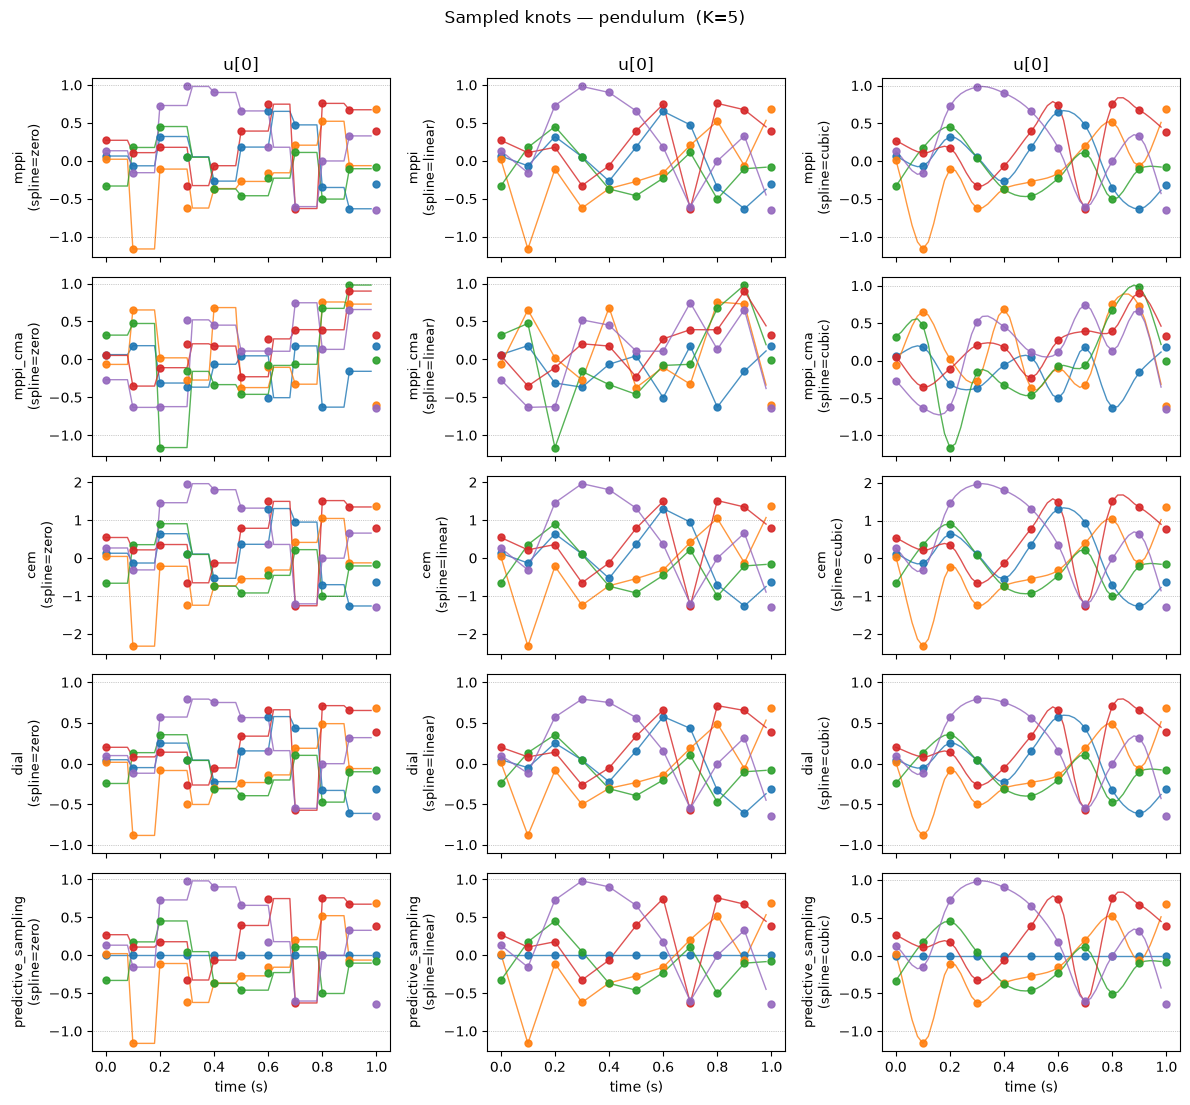

In [50]:
import matplotlib.pyplot as plt
from analytic_mppi.controllers.spline import interpolate

nu = task.nu
fig, axes = plt.subplots(
    len(sample_knots), nu*3,
    figsize=(3 * 4 * nu, 2.2 * len(sample_knots)),
    sharex=True, squeeze=False,
)

for row, (name, knots) in enumerate(sample_knots.items()):
    ctrl = controllers[name]
    ctrl.spline_type = 'zero'
    # expand (K, num_knots, nu) -> (K, H, nu) using the controller's spline type
    controls = interpolate(knots, ctrl.tk, ctrl.t_eval, ctrl.spline_type)

    for j in range(nu):
        ax = axes[row, j]
        # interpolated per-step controls — solid line, one per sample
        lines = ax.plot(ctrl.t_eval, controls[:, :, j].T, lw=1.0, alpha=0.8)
        # overlay the knot points in matching colors
        for k, line in enumerate(lines):
            ax.plot(ctrl.tk, knots[k, :, j], ls="", marker="o", ms=5,
                    color=line.get_color(), alpha=0.9)
        ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
        ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
        if j == 0:
            ax.set_ylabel(f"{name}\n(spline={ctrl.spline_type})", fontsize=9)
        if row == 0:
            ax.set_title(f"u[{j}]")
        if row == len(sample_knots) - 1:
            ax.set_xlabel("time (s)")

fig.suptitle(
    f"Interpolated controls vs. knots — {TASK_NAME}  "
    f"(H={controllers[next(iter(controllers))].H} steps, dt={backend.dt}s)",
    y=1.0,
)

for row, (name, knots) in enumerate(sample_knots.items()):
    ctrl = controllers[name]
    ctrl.spline_type = 'linear'
    # expand (K, num_knots, nu) -> (K, H, nu) using the controller's spline type
    controls = interpolate(knots, ctrl.tk, ctrl.t_eval, ctrl.spline_type)

    for j in range(nu):
        ax = axes[row, nu + j]
        # interpolated per-step controls — solid line, one per sample
        lines = ax.plot(ctrl.t_eval, controls[:, :, j].T, lw=1.0, alpha=0.8)
        # overlay the knot points in matching colors
        for k, line in enumerate(lines):
            ax.plot(ctrl.tk, knots[k, :, j], ls="", marker="o", ms=5,
                    color=line.get_color(), alpha=0.9)
        ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
        ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
        if j == 0:
            ax.set_ylabel(f"{name}\n(spline={ctrl.spline_type})", fontsize=9)
        if row == 0:
            ax.set_title(f"u[{j}]")
        if row == len(sample_knots) - 1:
            ax.set_xlabel("time (s)")


for row, (name, knots) in enumerate(sample_knots.items()):
    
    ctrl = controllers[name]
    ctrl.spline_type = 'cubic'
    # expand (K, num_knots, nu) -> (K, H, nu) using the controller's spline type
    controls = interpolate(knots, ctrl.tk, ctrl.t_eval, ctrl.spline_type)

    for j in range(nu):
        ax = axes[row, 2*nu + j]
        # interpolated per-step controls — solid line, one per sample
        lines = ax.plot(ctrl.t_eval, controls[:, :, j].T, lw=1.0, alpha=0.8)
        # overlay the knot points in matching colors
        for k, line in enumerate(lines):
            ax.plot(ctrl.tk, knots[k, :, j], ls="", marker="o", ms=5,
                    color=line.get_color(), alpha=0.9)
        ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
        ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
        if j == 0:
            ax.set_ylabel(f"{name}\n(spline={ctrl.spline_type})", fontsize=9)
        if row == 0:
            ax.set_title(f"u[{j}]")
        if row == len(sample_knots) - 1:
            ax.set_xlabel("time (s)")




fig.tight_layout()

fig.suptitle(f"Sampled knots — {TASK_NAME}  (K={controllers[next(iter(controllers))].num_samples})", y=1.0)
fig.tight_layout()
plt.show()

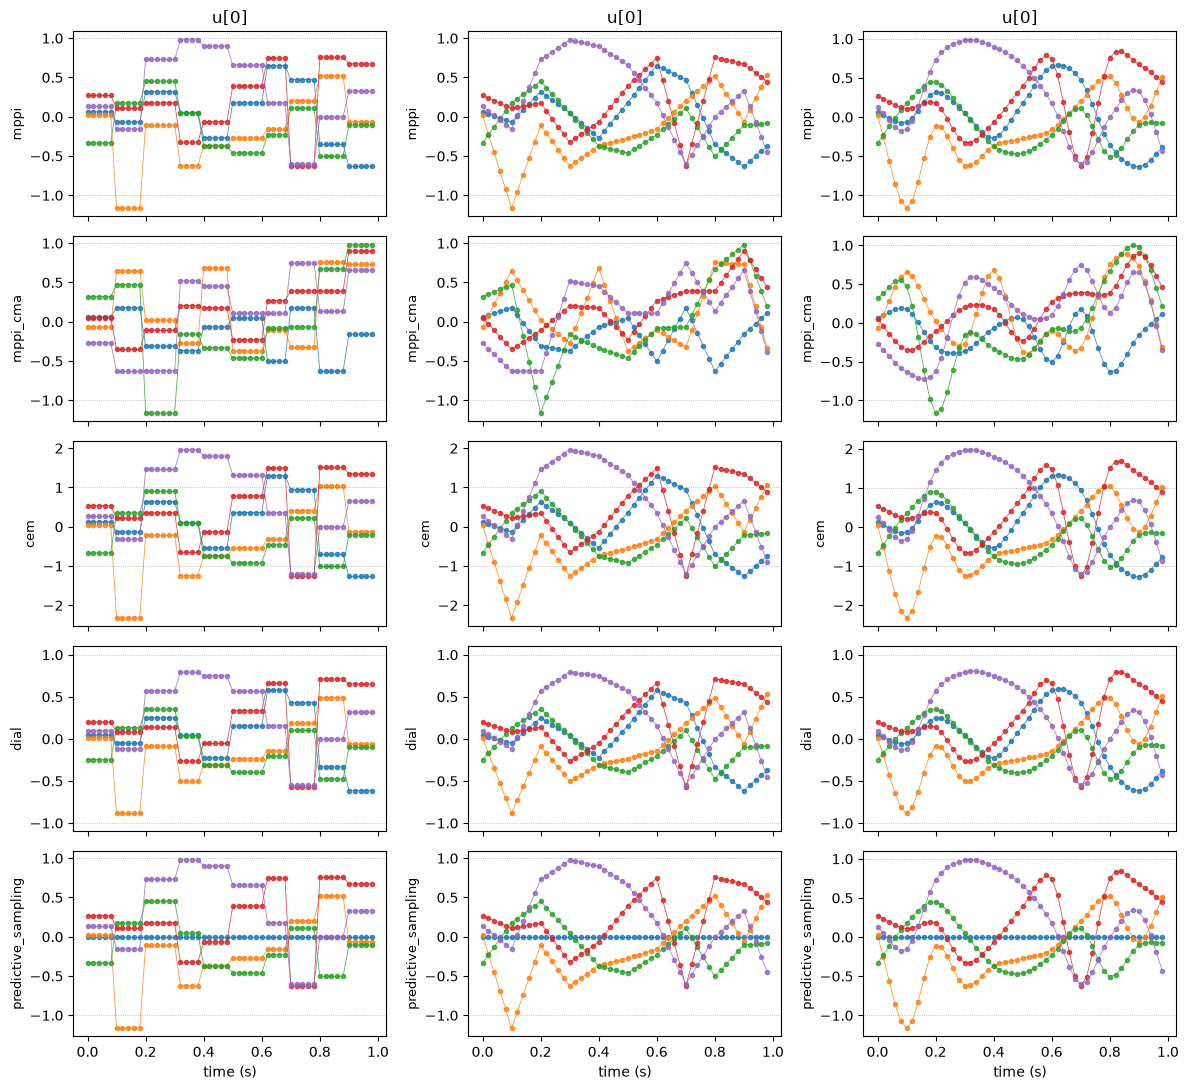

In [51]:
from analytic_mppi.controllers.spline import interpolate

# Plot the H per-step horizon values — i.e., the controls the MPPI algorithm
# actually applies at each MuJoCo step. H = round(plan_horizon / backend.dt),
# and the values are spaced by backend.dt on [0, plan_horizon).
#
# Each dot is one (t = i*dt, u_i) pair. The line connecting them is a
# visual guide only — the controller sees the discrete samples.

nu = task.nu
n_rows = len(sample_knots)
H = controllers[next(iter(controllers))].H
K = controllers[next(iter(controllers))].num_samples

fig, axes = plt.subplots(
        n_rows, nu * 3,
        figsize=(3 * 4 * nu, 2.2 * n_rows),
        sharex=True, squeeze=False,
    )
    
spline_num = 0
for spline_type in ("zero", "linear", "cubic"):
    
    for row, (name, knots) in enumerate(sample_knots.items()):
        ctrl = controllers[name]
        controls = interpolate(knots, ctrl.tk, ctrl.t_eval, spline_type)   # (K, H, nu)
        for j in range(nu):
            ax = axes[row, j + spline_num*nu]
            # the H per-step horizon values, one curve per sampled rollout
            ax.plot(
                ctrl.t_eval, controls[:, :, j].T,
                marker="o", ms=3, lw=0.6, alpha=0.8,
            )
            ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
            ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
            if j == 0:
                ax.set_ylabel(name, fontsize=9)
            if row == 0:
                ax.set_title(f"u[{j}]")
            if row == n_rows - 1:
                ax.set_xlabel("time (s)")

    spline_num += 1
    
# fig.suptitle(
#     f"spline_type = {spline_type!r}   "
#     f"{TASK_NAME}   K={K}, H={H} step values, dt={backend.dt}s",
#     y=1.0,
# )
fig.tight_layout()
plt.show()

## Smoothness as an FPL fulfillment value

Map the raw smoothness penalty $S = \sum_i \lVert u_{i+1} - u_i \rVert^2$ into a per-rollout fulfillment value in $[0, 1]$, matching the Gaussian-on-error convention used by `walker.py`, `hopper.py`, and `cube.py`:

$$
f \;=\; \exp\!\left( -\frac{S / (H-1)}{\sigma^2} \right)
$$

`sigma` is auto-calibrated from the current population so the median rollout lands near $f = 0.5$.

In [52]:
def smoothness_generic(h):
    """Raw smoothness penalty for one rollout h of shape (H, nu).

    Returns S = sum_i ||u_{i+1} - u_i||^2.  Larger = rougher.
    """
    diff = h[1:] - h[:-1]
    return float((diff ** 2).sum())


def smoothness_fpl(h, sigma):
    """Map one rollout's smoothness to a fulfillment value in (0, 1].

    Uses the Gaussian-on-error convention from walker/hopper/cube:
        f = exp( -(S / (H-1)) / sigma^2 )
    Dividing by (H-1) makes the score horizon-length invariant — the
    quantity in the exponent is the mean squared per-step control change.
    """
    diff = h[1:] - h[:-1]
    rate2 = float((diff ** 2).sum()) / max(1, diff.shape[0])
    return float(np.exp(-rate2 / sigma ** 2))


spline_types = ("zero", "linear", "cubic")
algo_names = list(sample_knots.keys())

# Calibration pass — collect S and the per-step rate^2 for every (algo, spline,
# rollout) in the current grid, then pick sigma so the *median* rate^2 maps to
# f = 0.5  =>  sigma^2 = median(rate^2) / ln(2).
rate2_pop = []
S_grid = np.zeros((len(algo_names), len(spline_types), COMMON["num_samples"]))
for c, spline_type in enumerate(spline_types):
    for r, name in enumerate(algo_names):
        ctrl = controllers[name]
        controls = interpolate(sample_knots[name], ctrl.tk, ctrl.t_eval, spline_type)
        Kc = controls.shape[0]
        for k in range(Kc):
            S = smoothness_generic(controls[k])
            S_grid[r, c, k] = S
            rate2_pop.append(S / max(1, controls.shape[1] - 1))
rate2_pop = np.asarray(rate2_pop)
sigma = float(np.sqrt(np.median(rate2_pop) / np.log(2.0)))
print(f"calibration:  N={len(rate2_pop)} rollouts   "
      f"median rate^2 = {np.median(rate2_pop):.4f}   "
      f"sigma = {sigma:.4f}")

calibration:  N=75 rollouts   median rate^2 = 0.0214   sigma = 0.1755


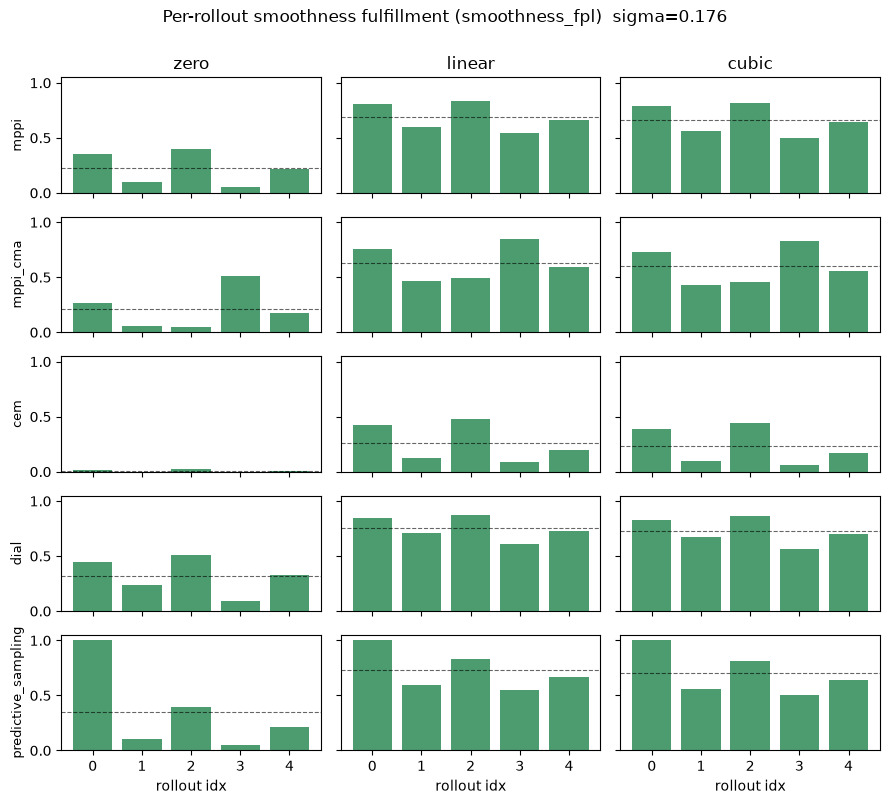

In [53]:
# Build the FPL grid by computing fulfillment using `smoothness_fpl` per rollout
F_grid = np.zeros_like(S_grid)
for c, spline_type in enumerate(spline_types):
    for r, name in enumerate(algo_names):
        ctrl = controllers[name]
        controls = interpolate(sample_knots[name], ctrl.tk, ctrl.t_eval, spline_type)
        Kc = controls.shape[0]
        for k in range(Kc):
            F_grid[r, c, k] = smoothness_fpl(controls[k], sigma)

# Plot the per-rollout fulfillment values as bar charts
n_rows, n_cols = len(algo_names), len(spline_types)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 1.6 * n_rows),
    sharex=True, sharey=True, squeeze=False,
)
K = COMMON["num_samples"]
for c, spline_type in enumerate(spline_types):
    for r, name in enumerate(algo_names):
        scores = F_grid[r, c]
        ax = axes[r, c]
        ax.bar(range(K), scores, color="seagreen", alpha=0.85)
        ax.axhline(scores.mean(), color="k", lw=0.8, ls="--", alpha=0.6)
        ax.set_ylim(0.0, 1.05)
        if c == 0:
            ax.set_ylabel(name, fontsize=9)
        if r == 0:
            ax.set_title(spline_type)
        if r == n_rows - 1:
            ax.set_xlabel("rollout idx")
        ax.set_xticks(range(K))

fig.suptitle(
    f"Per-rollout smoothness fulfillment (smoothness_fpl)  sigma={sigma:.3f}",
    y=1.0,
)
fig.tight_layout()
plt.show()

## Part 1 — Uniform horizon sampling (no knots)

Instead of sampling `(K, num_knots, nu)` knots and interpolating, draw the
full `(K, H, nu)` control sequence directly, independent across the H
horizon steps. The `dist` argument lets us swap distributions without
touching the call sites.

In [54]:
def sample_horizon(K, H, nu, u_min, u_max, rng, dist="uniform", scale=1.0):
    """Sample K action sequences of shape (K, H, nu), independent across the H horizon steps.

    dist:
      "uniform"   -> per step, per dim Uniform(u_min, u_max)
      "gaussian"  -> per step, per dim N(0, scale^2), clipped to [u_min, u_max]
      "bernoulli" -> per step, per dim Bernoulli over {u_min, u_max} (bang-bang baseline)
    """
    u_min = np.asarray(u_min, dtype=np.float64)
    u_max = np.asarray(u_max, dtype=np.float64)
    if dist == "uniform":
        return rng.uniform(u_min, u_max, size=(K, H, nu))
    if dist == "gaussian":
        return np.clip(rng.normal(0.0, scale, size=(K, H, nu)), u_min, u_max)
    if dist == "bernoulli":
        return np.where(rng.random((K, H, nu)) < 0.5, u_min, u_max).astype(np.float64)
    raise ValueError(f"unknown dist {dist!r}")

In [55]:
# Bounds-normalized smoothness fulfillment — replaces the population-calibrated FPL.
# The FPL above puts its f=0.5 anchor wherever the calibration population's median
# happened to land, so absolute values are meaningless across distributions.  This
# metric anchors to the action bounds instead, giving fixed task-invariant
# reference values:
#
#   constant trajectory                ->  1.000
#   iid Uniform[u_min, u_max]          ->  ~0.667   (theoretical)
#   iid Bernoulli{u_min, u_max} p=0.5  ->  0.500
#   bang-bang (flip every step)        ->  0.000
def smoothness_l1(u, u_min, u_max):
    """Smoothness fulfillment in [0, 1] using a bounds-normalized L1 rate.

    f = 1 - mean over (H-1) gaps and nu dims of |u[i+1, j] - u[i, j]| / (u_max[j] - u_min[j])

    Vectorised over leading batch dims:  u (..., H, nu) -> (...).
    Pass a single rollout (H, nu) to get a scalar.
    """
    rng = np.asarray(u_max, dtype=np.float64) - np.asarray(u_min, dtype=np.float64)
    diff = np.abs(u[..., 1:, :] - u[..., :-1, :]) / rng
    return 1.0 - diff.mean(axis=(-2, -1))

dist=gaussian  K=5  H=50  nu=1
f per rollout : [0.6698 0.5456 0.6205 0.5886 0.5692]
mean f        : 0.5987    (theory ≈ 0.4358)


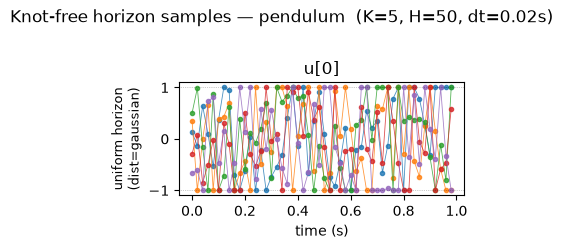

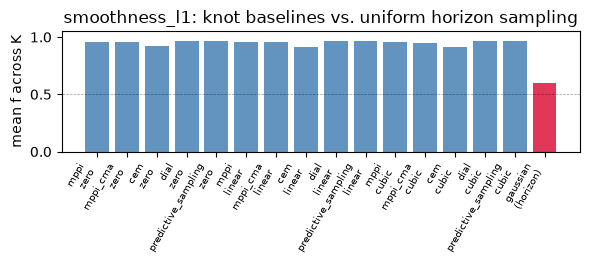

In [56]:
# Draw K rollouts straight onto the H-step grid, then score with smoothness_l1
# (bounds-normalized, anchored). Knot baselines are also re-scored with the
# same metric so the bar chart is an apples-to-apples comparison.

ctrl = controllers["mppi"]                   # any controller works — we only borrow H and t_eval
H = ctrl.H
nu = task.nu
K = COMMON["num_samples"]
DIST = "gaussian"                              # try "gaussian" or "bernoulli" too

rng = np.random.default_rng(0)
controls_uni = sample_horizon(K, H, nu, task.u_min, task.u_max, rng, dist=DIST)

F_uni = smoothness_l1(controls_uni, task.u_min, task.u_max)        # (K,)

# Theoretical anchors for the chosen dist, summed over nu dims (mean over (H-1) gaps).
# For independent components, E[|Δu_j|] depends only on dist & range_j.
range_ = np.asarray(task.u_max) - np.asarray(task.u_min)
exp_abs_diff = {                                                   # E[|Δu_j|] per dim
    "uniform":   range_ / 3.0,                                     # E|U1 - U2| for U~Uniform
    "gaussian":  np.full_like(range_, 2.0 / np.sqrt(np.pi)),       # for σ=1; ignores clipping
    "bernoulli": range_ / 2.0,                                     # P(flip)=0.5
}[DIST]
exp_f = float(1.0 - (exp_abs_diff / range_).mean())
print(f"dist={DIST}  K={K}  H={H}  nu={nu}")
print(f"f per rollout : {np.round(F_uni, 4)}")
print(f"mean f        : {F_uni.mean():.4f}    (theory ≈ {exp_f:.4f})")

# --- plot: per-step controls (one row, nu columns), matching cell ae5976be style ---
fig, axes = plt.subplots(1, nu, figsize=(4 * nu, 2.4), sharex=True, squeeze=False)
for j in range(nu):
    ax = axes[0, j]
    ax.plot(ctrl.t_eval, controls_uni[:, :, j].T, marker="o", ms=3, lw=0.6, alpha=0.8)
    ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.set_title(f"u[{j}]")
    ax.set_xlabel("time (s)")
axes[0, 0].set_ylabel(f"uniform horizon\n(dist={DIST})", fontsize=9)
fig.suptitle(f"Knot-free horizon samples — {TASK_NAME}  (K={K}, H={H}, dt={backend.dt}s)", y=1.02)
fig.tight_layout()
plt.show()

# --- bar chart: smoothness_l1 for uniform vs. the three knot/spline baselines ---
F_grid_l1 = np.zeros_like(S_grid)
for c, spline_type in enumerate(spline_types):
    for r, name in enumerate(algo_names):
        ctrl_r = controllers[name]
        ctrl_controls = interpolate(sample_knots[name], ctrl_r.tk, ctrl_r.t_eval, spline_type)
        F_grid_l1[r, c] = smoothness_l1(ctrl_controls, task.u_min, task.u_max)

fig, ax = plt.subplots(figsize=(6, 2.8))
algo_means = F_grid_l1.mean(axis=2)
labels, vals = [], []
for c, st in enumerate(spline_types):
    for r, name in enumerate(algo_names):
        labels.append(f"{name}\n{st}")
        vals.append(algo_means[r, c])
labels.append(f"{DIST}\n(horizon)")
vals.append(F_uni.mean())
colors = ["steelblue"] * (len(vals) - 1) + ["crimson"]
ax.bar(range(len(vals)), vals, color=colors, alpha=0.85)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
ax.set_ylim(0.0, 1.05)
ax.axhline(0.5, color="k", lw=0.5, ls="--", alpha=0.4)
ax.set_ylabel("mean f across K")
ax.set_title("smoothness_l1: knot baselines vs. uniform horizon sampling")
fig.tight_layout()
plt.show()

## Part 2 — Gradient descent on smoothness

For $S(u) = \sum_i \lVert u_{i+1} - u_i \rVert^2$ with $u$ of shape $(H, n_u)$, the gradient is the 1-D discrete Laplacian along time:

- $\partial S / \partial u_0 = -2 (u_1 - u_0)$
- $\partial S / \partial u_{H-1} = 2 (u_{H-1} - u_{H-2})$
- $\partial S / \partial u_i = 2 (2 u_i - u_{i-1} - u_{i+1})$ for interior $i$

Vanilla GD with step size $\eta$ is therefore Jacobi smoothing on the time axis (stable for $\eta \le 0.25$, since $2L$ has spectral radius $\le 8$). We clip to $[u_\min, u_\max]$ after each step.

In [57]:
def smoothness_grad(u):
    """∂S/∂u for S = sum_i ||u_{i+1} - u_i||^2.  u: (..., H, nu) -> same shape."""
    g = np.zeros_like(u)
    d = u[..., 1:, :] - u[..., :-1, :]            # forward differences (..., H-1, nu)
    g[..., :-1, :] -= 2.0 * d
    g[..., 1:,  :] += 2.0 * d
    return g


def smooth_descent(u, n_iter, lr, u_min, u_max):
    """Vanilla GD on S, clipping to bounds each step.

    Returns (u_final, hist) where hist has shape (n_iter + 1, K) and rows
    are S per rollout at each iteration (row 0 = initial).
    """
    u = u.copy().astype(np.float64)
    K = u.shape[0]
    hist = np.empty((n_iter + 1, K))
    hist[0] = [smoothness_generic(u[k]) for k in range(K)]
    for t in range(n_iter):
        u -= lr * smoothness_grad(u)
        np.clip(u, u_min, u_max, out=u)
        hist[t + 1] = [smoothness_generic(u[k]) for k in range(K)]
    return u, hist

GD: n_iter=5, lr=0.25
  rollout 0: S   33.318 ->    8.065    f 0.6698 -> 0.8233
  rollout 1: S   57.441 ->   17.406    f 0.5456 -> 0.7463
  rollout 2: S   46.168 ->   10.721    f 0.6205 -> 0.8000
  rollout 3: S   49.369 ->    9.604    f 0.5886 -> 0.8076
  rollout 4: S   54.756 ->   13.482    f 0.5692 -> 0.7885
  monotone non-increasing on S: True


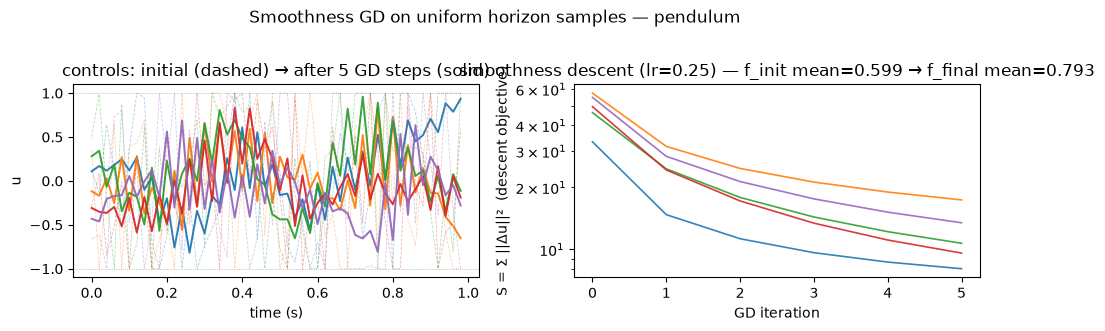

In [58]:
# Refine the Part-1 uniform samples by descending on S = sum ||Δu||^2.
# The gradient is the discrete Laplacian (closed-form), and since L1-rate
# and L2-rate are both monotone in roughness, descending L2 also drives
# smoothness_l1 fulfillment up — so we keep the closed-form descent and
# just report the new metric for evaluation.
N_ITER = 5
LR    = 0.25

controls_final, hist = smooth_descent(
    controls_uni, n_iter=N_ITER, lr=LR,
    u_min=task.u_min, u_max=task.u_max,
)

F_init  = smoothness_l1(controls_uni,   task.u_min, task.u_max)   # (K,)
F_final = smoothness_l1(controls_final, task.u_min, task.u_max)   # (K,)
S_init, S_final = hist[0], hist[-1]

print(f"GD: n_iter={N_ITER}, lr={LR}")
for k in range(K):
    print(f"  rollout {k}: S {S_init[k]:8.3f} -> {S_final[k]:8.3f}    "
          f"f {F_init[k]:.4f} -> {F_final[k]:.4f}")
print(f"  monotone non-increasing on S: {bool(np.all(np.diff(hist, axis=0) <= 1e-9))}")

# --- two-panel figure: initial vs final overlay, and S-vs-iteration curves ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for k in range(K):
    color = prop_cycle[k % len(prop_cycle)]
    for j in range(nu):
        ax.plot(ctrl.t_eval, controls_uni[k, :, j],   color=color, lw=0.6, ls="--", alpha=0.35)
        ax.plot(ctrl.t_eval, controls_final[k, :, j], color=color, lw=1.4, alpha=0.95)
for j in range(nu):
    ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
ax.set_title(f"controls: initial (dashed) → after {N_ITER} GD steps (solid)")
ax.set_xlabel("time (s)")
ax.set_ylabel("u")

ax = axes[1]
ax.plot(hist, lw=1.2, alpha=0.9)
ax.set_yscale("log")
ax.set_xlabel("GD iteration")
ax.set_ylabel("S = Σ ||Δu||²  (descent objective)")
ax.set_title(f"smoothness descent (lr={LR}) — f_init mean={F_init.mean():.3f} → f_final mean={F_final.mean():.3f}")

fig.suptitle(f"Smoothness GD on uniform horizon samples — {TASK_NAME}", y=1.02)
fig.tight_layout()
plt.show()

## Part 3 — Frequency-domain analysis and low-pass filtering

The uniform horizon samples are white noise (flat power spectrum from DC up to the Nyquist frequency $f_N = 1/(2\,dt)$). The visible zigzag is dominated by content near $f_N$, so "make the trajectory smoother" = "kill the high frequencies".

Note that Part 2's gradient descent is *already* a low-pass: each Jacobi step multiplies the $k$-th DCT mode by $1 - 2\eta(1-\cos(k\pi/H))$, which attenuates high modes most aggressively. We'll compare it head-to-head with two one-shot filters:

- **FFT brick-wall**: rFFT → zero bins above $f_\text{cut}$ → iRFFT. Sharp cutoff, but causes Gibbs ringing.
- **Gaussian convolution**: smooth roll-off in frequency, no time-domain ringing. Effective cutoff $\sim 1/(2\pi\,\sigma_t)$.

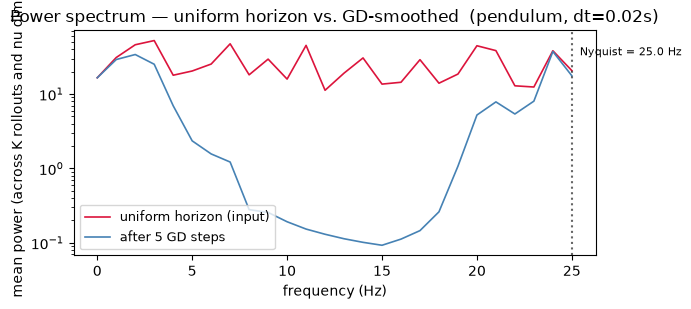

In [59]:
# Diagnostic: power spectrum of the uniform horizon samples vs. the GD-smoothed version.
# rfftfreq gives the H//2 + 1 non-negative bin frequencies in Hz given dt.

freqs = np.fft.rfftfreq(H, d=backend.dt)                  # 0 .. 1/(2*dt) Hz
P_uni = np.abs(np.fft.rfft(controls_uni,   axis=-2)) ** 2 # (K, F, nu)
P_gd  = np.abs(np.fft.rfft(controls_final, axis=-2)) ** 2

f_ny = 0.5 / backend.dt
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.semilogy(freqs, P_uni.mean(axis=(0, 2)), color="crimson",   lw=1.2, label="uniform horizon (input)")
ax.semilogy(freqs, P_gd .mean(axis=(0, 2)), color="steelblue", lw=1.2, label=f"after {N_ITER} GD steps")
ax.axvline(f_ny, color="k", ls=":", alpha=0.6)
ax.text(f_ny, ax.get_ylim()[1] * 0.6, f"  Nyquist = {f_ny:.1f} Hz", fontsize=8, va="top")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("mean power (across K rollouts and nu dims)")
ax.set_title(f"Power spectrum — uniform horizon vs. GD-smoothed  ({TASK_NAME}, dt={backend.dt}s)")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
plt.show()

In [60]:
from numpy.lib.stride_tricks import sliding_window_view


def lowpass_fft(u, dt, f_cut):
    """Brick-wall low-pass via rFFT/iRFFT along the time axis.

    u:      (..., H, nu)
    dt:     timestep in seconds
    f_cut:  cutoff frequency in Hz (bins with freq > f_cut are zeroed)
    """
    H = u.shape[-2]
    freqs = np.fft.rfftfreq(H, d=dt)
    mask_shape = [1] * u.ndim
    mask_shape[-2] = freqs.size
    mask = (freqs <= f_cut).astype(np.float64).reshape(mask_shape)
    U = np.fft.rfft(u, axis=-2) * mask
    return np.fft.irfft(U, n=H, axis=-2)


def lowpass_gaussian(u, dt, sigma_t):
    """Gaussian smoothing along the time axis (axis=-2) with edge-reflection padding.

    u:        (..., H, nu)
    dt:       timestep in seconds
    sigma_t:  kernel std in seconds. Effective frequency cutoff ~ 1/(2π·sigma_t).
    """
    sigma_n = sigma_t / dt
    radius = max(1, int(np.ceil(4.0 * sigma_n)))
    x = np.arange(-radius, radius + 1, dtype=np.float64)
    k = np.exp(-0.5 * (x / sigma_n) ** 2)
    k /= k.sum()
    pad_widths = [(0, 0)] * u.ndim
    pad_widths[-2] = (radius, radius)
    upad = np.pad(u, pad_widths, mode="edge")
    # sliding window along axis=-2: (..., H, nu, window) — contract `window` with k.
    windows = sliding_window_view(upad, window_shape=2 * radius + 1, axis=-2)
    return np.tensordot(windows, k, axes=([-1], [0]))

smoothness_l1 across K=5 rollouts (higher = smoother):
  uniform (input)                         mean=0.5987    per-rollout: [0.6698 0.5456 0.6205 0.5886 0.5692]
  GD only  (N=5, lr=0.25)                 mean=0.7931    per-rollout: [0.8233 0.7463 0.8    0.8076 0.7885]
  GD + FFT  (f_cut=5.0 Hz)                mean=0.9652    per-rollout: [0.9608 0.9698 0.9552 0.9743 0.9659]
  GD + Gauss  (σ_t=0.08s)                 mean=0.9849    per-rollout: [0.9813 0.9881 0.9791 0.9885 0.9874]


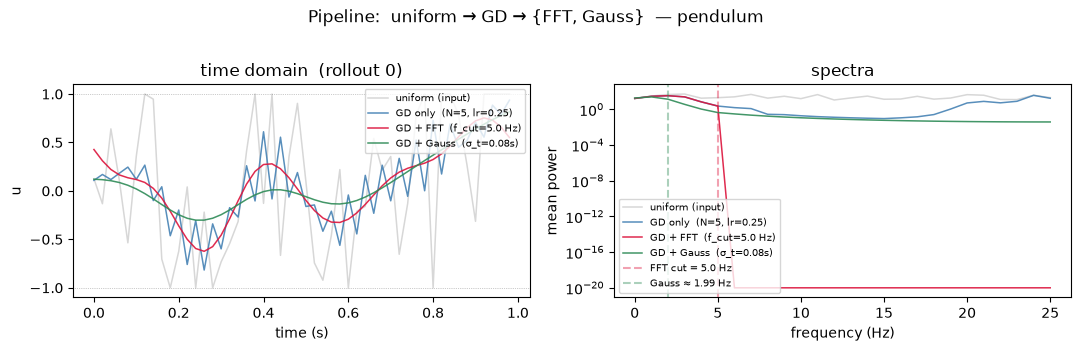

In [61]:
# Pipeline order: uniform input  →  GD smoother  →  {FFT, Gaussian} low-pass.
# Filters now take controls_final (the GD output), NOT controls_uni — so we're
# asking "does an extra low-pass on top of GD buy us anything?"
F_CUT   = 5.0     # Hz, brick-wall cutoff for FFT filter
SIGMA_T = 0.08    # seconds, Gaussian kernel std (effective cutoff ≈ 1 / (2π σ_t) ≈ 2 Hz)

controls_fft   = lowpass_fft     (controls_final, backend.dt, F_CUT)
controls_gauss = lowpass_gaussian(controls_final, backend.dt, SIGMA_T)

methods = {
    "uniform (input)":                       (controls_uni,   "lightgray"),
    f"GD only  (N={N_ITER}, lr={LR})":         (controls_final, "steelblue"),
    f"GD + FFT  (f_cut={F_CUT} Hz)":           (controls_fft,   "crimson"),
    f"GD + Gauss  (σ_t={SIGMA_T}s)":           (controls_gauss, "seagreen"),
}

print(f"smoothness_l1 across K={K} rollouts (higher = smoother):")
for name, (arr, _) in methods.items():
    f = smoothness_l1(arr, task.u_min, task.u_max)
    print(f"  {name:38s}  mean={f.mean():.4f}    per-rollout: {np.round(f, 4)}")

# Two-panel: time-domain trajectories of rollout k=0  |  post-filter power spectra
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
k0 = 0
for name, (arr, color) in methods.items():
    for j in range(nu):
        ax.plot(ctrl.t_eval, arr[k0, :, j], color=color, lw=1.1, alpha=0.9, label=name if j == 0 else None)
for j in range(nu):
    ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
ax.set_xlabel("time (s)")
ax.set_ylabel("u")
ax.set_title(f"time domain  (rollout {k0})")
ax.legend(loc="upper right", fontsize=7)

ax = axes[1]
for name, (arr, color) in methods.items():
    P = np.abs(np.fft.rfft(arr, axis=-2)) ** 2
    ax.semilogy(freqs, P.mean(axis=(0, 2)) + 1e-20, color=color, lw=1.1, alpha=0.9, label=name)
ax.axvline(F_CUT, color="crimson", ls="--", alpha=0.4, label=f"FFT cut = {F_CUT} Hz")
ax.axvline(1.0 / (2 * np.pi * SIGMA_T), color="seagreen", ls="--", alpha=0.4,
           label=f"Gauss ≈ {1.0 / (2 * np.pi * SIGMA_T):.2f} Hz")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("mean power")
ax.set_title("spectra")
ax.legend(loc="lower left", fontsize=7)

fig.suptitle(f"Pipeline:  uniform → GD → {{FFT, Gauss}}  — {TASK_NAME}", y=1.02)
fig.tight_layout()
plt.show()

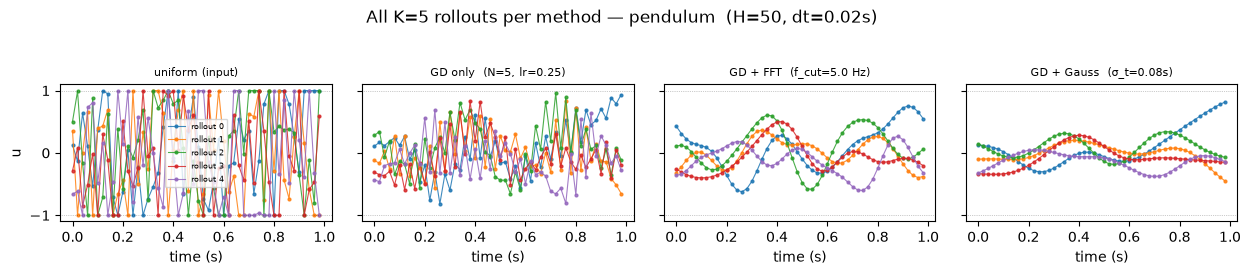

In [62]:
# Show all K=5 control rollouts per method (same style as the Part 1 plot),
# so you can see what GD and each filter do to every sample, not just one.
#
# Color = rollout index (consistent across panels).  So rollout 0 has the same
# color in every panel — easy to trace how that specific sample is transformed
# by GD vs. each filter.

cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(
    1, len(methods), figsize=(3.2 * len(methods), 2.6),
    sharex=True, sharey=True, squeeze=False,
)
for col, (name, (arr, _)) in enumerate(methods.items()):
    ax = axes[0, col]
    for k in range(K):
        color = cycle[k % len(cycle)]
        for j in range(nu):
            ax.plot(ctrl.t_eval, arr[k, :, j], color=color, marker="o", ms=2, lw=0.8,
                    alpha=0.85, label=(f"rollout {k}" if (col == 0 and j == 0) else None))
    for j in range(nu):
        ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
        ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("time (s)")

axes[0, 0].set_ylabel("u")
axes[0, 0].legend(loc="best", fontsize=6, ncol=1)
fig.suptitle(f"All K={K} rollouts per method — {TASK_NAME}  (H={H}, dt={backend.dt}s)", y=1.04)
fig.tight_layout()
plt.show()

Δf attributable to the filter (GD → GD + filter):
  GD + FFT  (f_cut=5.0 Hz)                Δf mean = +0.1721    per-rollout: [0.1375 0.2235 0.1552 0.1667 0.1775]
  GD + Gauss  (σ_t=0.08s)                 Δf mean = +0.1917    per-rollout: [0.158  0.2417 0.1791 0.1808 0.199 ]


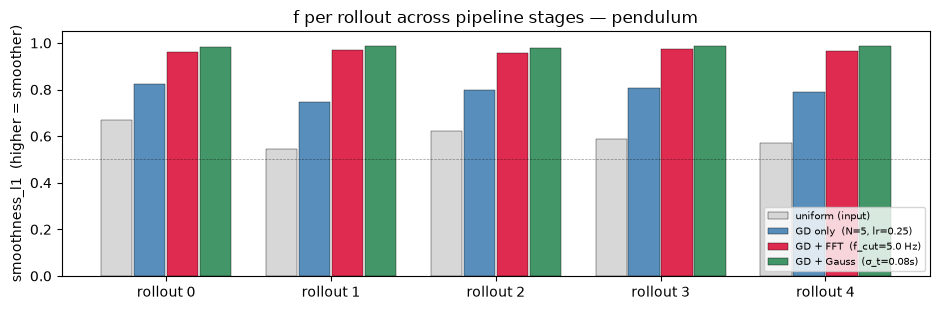

In [63]:
# Per-rollout smoothness_l1 across the four pipeline stages, plus deltas
# attributable to each filter on top of GD.

f_per_method = {name: smoothness_l1(arr, task.u_min, task.u_max)
                for name, (arr, _) in methods.items()}

# "Before filtering" = GD output;  "after" = GD+FFT or GD+Gauss.
keys = list(methods.keys())          # [uniform, GD only, GD+FFT, GD+Gauss]
KEY_UNI, KEY_GD, KEY_FFT, KEY_GAUSS = keys
print("Δf attributable to the filter (GD → GD + filter):")
for k_name in (KEY_FFT, KEY_GAUSS):
    delta = f_per_method[k_name] - f_per_method[KEY_GD]
    print(f"  {k_name:38s}  Δf mean = {delta.mean():+.4f}    per-rollout: {np.round(delta, 4)}")

# Grouped bar chart: x = rollout idx, one bar per method per rollout.
n_meth = len(methods)
x = np.arange(K)
w = 0.8 / n_meth

fig, ax = plt.subplots(figsize=(max(6.0, 1.4 * K + 2.5), 3.2))
for i, (name, (_, color)) in enumerate(methods.items()):
    offset = (i - (n_meth - 1) / 2.0) * w
    ax.bar(x + offset, f_per_method[name], width=w * 0.95,
           color=color, alpha=0.9, edgecolor="k", linewidth=0.3, label=name)

ax.axhline(0.5, color="k", lw=0.5, ls="--", alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([f"rollout {k}" for k in range(K)])
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("smoothness_l1  (higher = smoother)")
ax.set_title(f"f per rollout across pipeline stages — {TASK_NAME}")
ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()
plt.show()

In [64]:
# Curvature-based smoothness: penalises how the GRADIENT itself changes,
# not the gradient's magnitude.  A constant-slope ramp has zero curvature
# (f = 1) even though its first difference is large — so this rewards
# monotone trajectories that smoothness_l1 would dock.
#
# Definition: bounds-normalised L1 of the discrete second difference.
#   Δ²u_i = u_{i+1} - 2·u_i + u_{i-1}            # discrete Laplacian / curvature
#   f     = 1 - mean_{i,j} |Δ²u_{i,j}| / (2·(u_max_j - u_min_j))
#
# Max possible |Δ²u_{i,j}| is 2·range (u goes max → min → max in three
# consecutive steps), so dividing by 2·range bounds f to [0, 1].
def smoothness_curvature(u, u_min, u_max):
    """Smoothness fulfillment in [0, 1] using the bounds-normalised L1
    of the discrete second difference.

    Vectorised over leading batch dims:  u (..., H, nu) -> (...).

    Anchors (1D, u in [u_min, u_max]):
      constant trajectory       -> 1.000
      linear ramp end-to-end    -> 1.000   (zero curvature)
      iid Uniform on bounds     -> ~0.72   (numeric)
      iid Bernoulli, p=0.5      -> ~0.50
      bang-bang every step      -> 0.000
    """
    rng = np.asarray(u_max, dtype=np.float64) - np.asarray(u_min, dtype=np.float64)
    d2 = u[..., 2:, :] - 2.0 * u[..., 1:-1, :] + u[..., :-2, :]
    return 1.0 - (np.abs(d2) / (2.0 * rng)).mean(axis=(-2, -1))

smoothness_curvature  vs  smoothness_l1  (mean across K):
  method                                   curvature          L1
  uniform (input)                             0.6482      0.5987
  GD only  (N=5, lr=0.25)                     0.7953      0.7931
  GD + FFT  (f_cut=5.0 Hz)                    0.9932      0.9652
  GD + Gauss  (σ_t=0.08s)                     0.9981      0.9849


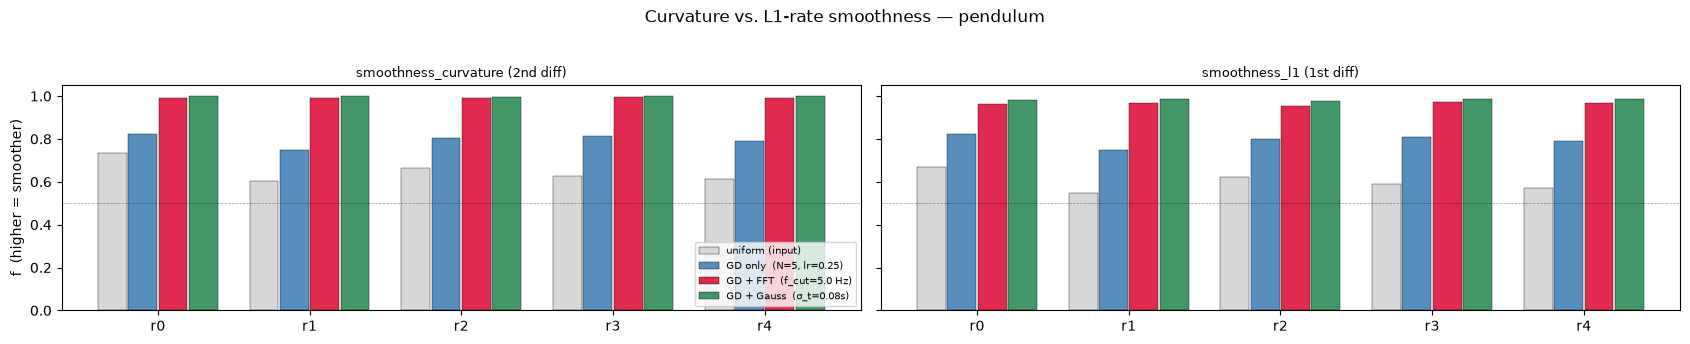

In [65]:
# Per-rollout f using the curvature metric, plus a side-by-side comparison
# with smoothness_l1 so you can see which metric tracks visual intuition better.

f_curv = {name: smoothness_curvature(arr, task.u_min, task.u_max)
          for name, (arr, _) in methods.items()}
f_l1   = f_per_method      # reused from the previous cell

print("smoothness_curvature  vs  smoothness_l1  (mean across K):")
print(f"  {'method':38s}  {'curvature':>10s}  {'L1':>10s}")
for name in methods:
    print(f"  {name:38s}  {f_curv[name].mean():10.4f}  {f_l1[name].mean():10.4f}")

# Two panels: curvature (left)  |  L1-rate (right), same grouped-bar layout.
n_meth = len(methods)
x = np.arange(K)
w = 0.8 / n_meth

fig, axes = plt.subplots(1, 2, figsize=(max(10.0, 2.6 * K + 4.0), 3.3), sharey=True)
for ax, (title, data) in zip(axes, [("smoothness_curvature (2nd diff)", f_curv),
                                    ("smoothness_l1 (1st diff)",        f_l1)]):
    for i, (name, (_, color)) in enumerate(methods.items()):
        offset = (i - (n_meth - 1) / 2.0) * w
        ax.bar(x + offset, data[name], width=w * 0.95,
               color=color, alpha=0.9, edgecolor="k", linewidth=0.3,
               label=(name if title.startswith("smoothness_curvature") else None))
    ax.axhline(0.5, color="k", lw=0.5, ls="--", alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"r{k}" for k in range(K)])
    ax.set_title(title, fontsize=9)
    ax.set_ylim(0.0, 1.05)
axes[0].set_ylabel("f  (higher = smoother)")
axes[0].legend(loc="lower right", fontsize=7)
fig.suptitle(f"Curvature vs. L1-rate smoothness — {TASK_NAME}", y=1.03)
fig.tight_layout()
plt.show()

## Part 4 — Curvature-driven pipeline (mirror of Parts 2 + 3)

Same structure as the L2-on-first-diff pipeline above, but with **curvature** driving the gradient descent.

- GD now descends on $S_\text{curv}(u) = \sum_i \lVert \Delta^2 u_i\rVert^2$ where $\Delta^2 u_i = u_{i+1} - 2 u_i + u_{i-1}$. The gradient is the discrete **biharmonic** operator $2L^2 u$ (Laplacian-of-Laplacian) — closed-form below.
- Stability requires $\eta \le 1/16 \approx 0.06$ because $L^2$ has spectral radius 16 (vs. 4 for $L$ in Part 2). We use `lr = 0.05`.
- L1- and L2-curvature are both monotone in roughness, so descending the L2 form still drives `smoothness_curvature` (the L1 form) up. Reporting stays in `smoothness_curvature`.
- **Linear ramps are fixed points** of curvature descent (zero $\Delta^2 u$), so the GD output should bend toward piecewise-linear shapes between endpoints — *not* toward a flat line like Part 2's L2-Laplacian descent converged to.

Curvature GD: n_iter=5, lr=0.05
  rollout 0: S_curv  91.2309 ->   1.6428    f_curv 0.7337 -> 0.9618
  rollout 1: S_curv 172.3938 ->   2.6654    f_curv 0.6019 -> 0.9492
  rollout 2: S_curv 139.7975 ->   1.1963    f_curv 0.6644 -> 0.9675
  rollout 3: S_curv 149.0930 ->   1.5129    f_curv 0.6286 -> 0.9637
  rollout 4: S_curv 159.3314 ->   2.8481    f_curv 0.6123 -> 0.9491
  monotone non-increasing on S_curv: True


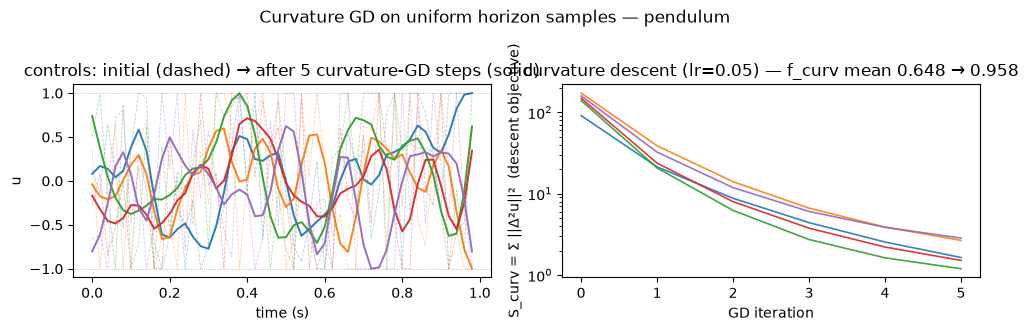

In [66]:
def smoothness_curv_grad(u):
    """∂S/∂u for S = Σ_i ||u_{i+1} - 2 u_i + u_{i-1}||².

    Returns 2·L² u where L is the 1-D discrete Laplacian along time.
    Same shape as u (..., H, nu).  Endpoints get one-sided contributions
    only (no curvature term is anchored at u_0 or u_{H-1}).
    """
    d2 = u[..., 2:, :] - 2.0 * u[..., 1:-1, :] + u[..., :-2, :]   # (..., H-2, nu)
    g = np.zeros_like(u)
    g[..., :-2,  :] += 2.0 * d2     # contribution to u_{i-1}
    g[..., 1:-1, :] -= 4.0 * d2     # contribution to u_i
    g[..., 2:,   :] += 2.0 * d2     # contribution to u_{i+1}
    return g


def _s_curv_per_rollout(u):
    d2 = u[..., 2:, :] - 2.0 * u[..., 1:-1, :] + u[..., :-2, :]
    return (d2 ** 2).sum(axis=(-2, -1))


def smooth_descent_curv(u, n_iter, lr, u_min, u_max):
    """Vanilla GD on S_curv = Σ ||Δ²u||², clipping to bounds each step.
    Returns (u_final, hist) with hist shape (n_iter+1, K).
    """
    u = u.copy().astype(np.float64)
    K = u.shape[0]
    hist = np.empty((n_iter + 1, K))
    hist[0] = _s_curv_per_rollout(u)
    for t in range(n_iter):
        u -= lr * smoothness_curv_grad(u)
        np.clip(u, u_min, u_max, out=u)
        hist[t + 1] = _s_curv_per_rollout(u)
    return u, hist


N_ITER_CURV = 5
LR_CURV     = 0.05

controls_final_curv, hist_curv = smooth_descent_curv(
    controls_uni, n_iter=N_ITER_CURV, lr=LR_CURV,
    u_min=task.u_min, u_max=task.u_max,
)

F_init  = smoothness_curvature(controls_uni,        task.u_min, task.u_max)
F_final = smoothness_curvature(controls_final_curv, task.u_min, task.u_max)
S_init, S_final = hist_curv[0], hist_curv[-1]

print(f"Curvature GD: n_iter={N_ITER_CURV}, lr={LR_CURV}")
for k in range(K):
    print(f"  rollout {k}: S_curv {S_init[k]:8.4f} -> {S_final[k]:8.4f}    "
          f"f_curv {F_init[k]:.4f} -> {F_final[k]:.4f}")
print(f"  monotone non-increasing on S_curv: {bool(np.all(np.diff(hist_curv, axis=0) <= 1e-9))}")

# Two-panel: before/after overlay  |  S_curv history (log scale)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))

ax = axes[0]
cyc = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for k in range(K):
    color = cyc[k % len(cyc)]
    for j in range(nu):
        ax.plot(ctrl.t_eval, controls_uni[k, :, j],        color=color, lw=0.6, ls="--", alpha=0.35)
        ax.plot(ctrl.t_eval, controls_final_curv[k, :, j], color=color, lw=1.4, alpha=0.95)
for j in range(nu):
    ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
ax.set_title(f"controls: initial (dashed) → after {N_ITER_CURV} curvature-GD steps (solid)")
ax.set_xlabel("time (s)"); ax.set_ylabel("u")

ax = axes[1]
ax.plot(hist_curv, lw=1.2, alpha=0.9)
ax.set_yscale("log")
ax.set_xlabel("GD iteration")
ax.set_ylabel("S_curv = Σ ||Δ²u||²  (descent objective)")
ax.set_title(f"curvature descent (lr={LR_CURV}) — f_curv mean {F_init.mean():.3f} → {F_final.mean():.3f}")

fig.suptitle(f"Curvature GD on uniform horizon samples — {TASK_NAME}", y=1.02)
fig.tight_layout()
plt.show()

smoothness_curvature per stage (mean across K):
  uniform (input)                             mean=0.6482    per-rollout: [0.7337 0.6019 0.6644 0.6286 0.6123]
  GD_curv only  (N=5, lr=0.05)                mean=0.9583    per-rollout: [0.9618 0.9492 0.9675 0.9637 0.9491]
  GD_curv + FFT  (f_cut=5.0 Hz)               mean=0.9880    per-rollout: [0.9899 0.9872 0.9867 0.9928 0.9831]
  GD_curv + Gauss  (σ_t=0.08s)                mean=0.9974    per-rollout: [0.9975 0.998  0.9958 0.9979 0.9975]

Δf_curv from filtering on top of curvature-GD:
  GD_curv + FFT  (f_cut=5.0 Hz)               Δf_curv mean = +0.0297    per-rollout: [0.0281 0.038  0.0192 0.0291 0.034 ]
  GD_curv + Gauss  (σ_t=0.08s)                Δf_curv mean = +0.0391    per-rollout: [0.0357 0.0488 0.0282 0.0343 0.0484]


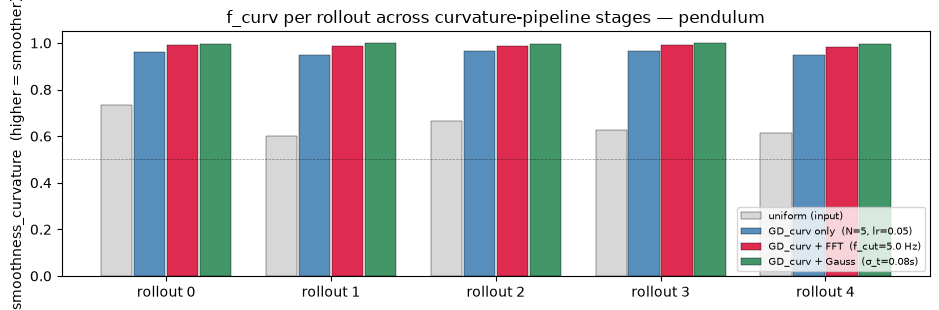

In [67]:
# Pipeline:  uniform  →  curvature-GD  →  {FFT, Gaussian} low-pass on top.
# Same knobs as Part 3 so the cutoffs match what's already plotted.
controls_fft_c   = lowpass_fft     (controls_final_curv, backend.dt, F_CUT)
controls_gauss_c = lowpass_gaussian(controls_final_curv, backend.dt, SIGMA_T)

methods_curv = {
    "uniform (input)":                                  (controls_uni,         "lightgray"),
    f"GD_curv only  (N={N_ITER_CURV}, lr={LR_CURV})":     (controls_final_curv,  "steelblue"),
    f"GD_curv + FFT  (f_cut={F_CUT} Hz)":                 (controls_fft_c,       "crimson"),
    f"GD_curv + Gauss  (σ_t={SIGMA_T}s)":                 (controls_gauss_c,     "seagreen"),
}

f_curv_stage = {name: smoothness_curvature(arr, task.u_min, task.u_max)
                for name, (arr, _) in methods_curv.items()}

print("smoothness_curvature per stage (mean across K):")
for name, vals in f_curv_stage.items():
    print(f"  {name:42s}  mean={vals.mean():.4f}    per-rollout: {np.round(vals, 4)}")

keys = list(methods_curv.keys())
print("\nΔf_curv from filtering on top of curvature-GD:")
for k_name in keys[2:]:
    delta = f_curv_stage[k_name] - f_curv_stage[keys[1]]
    print(f"  {k_name:42s}  Δf_curv mean = {delta.mean():+.4f}    per-rollout: {np.round(delta, 4)}")

# Grouped bar chart — same layout as cell 16e58ec4, but f_curv on the y-axis.
n_meth = len(methods_curv)
x = np.arange(K)
w = 0.8 / n_meth

fig, ax = plt.subplots(figsize=(max(6.0, 1.4 * K + 2.5), 3.2))
for i, (name, (_, color)) in enumerate(methods_curv.items()):
    offset = (i - (n_meth - 1) / 2.0) * w
    ax.bar(x + offset, f_curv_stage[name], width=w * 0.95,
           color=color, alpha=0.9, edgecolor="k", linewidth=0.3, label=name)

ax.axhline(0.5, color="k", lw=0.5, ls="--", alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels([f"rollout {k}" for k in range(K)])
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("smoothness_curvature  (higher = smoother)")
ax.set_title(f"f_curv per rollout across curvature-pipeline stages — {TASK_NAME}")
ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()
plt.show()

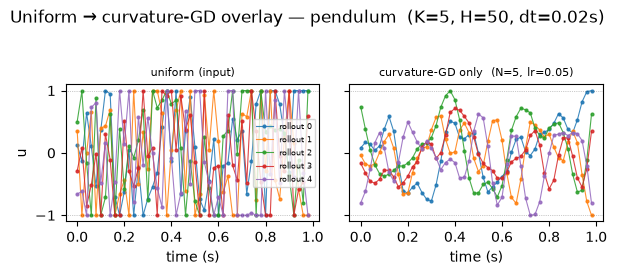

In [68]:
# Part 3b — uniform sampling + a few iterations of curvature GD, side-by-side overlay.
# Same visual style as cell 4dd4e669 (per-rollout colors, consistent across panels)
# but with curvature GD instead of L2-on-first-diff GD.
N_ITER_3B = 5      # "few iterations" as requested

controls_gd_curv_few, _ = smooth_descent_curv(
    controls_uni, n_iter=N_ITER_3B, lr=LR_CURV,
    u_min=task.u_min, u_max=task.u_max,
)

methods_3b = {
    "uniform (input)":                                     (controls_uni,          "lightgray"),
    f"curvature-GD only  (N={N_ITER_3B}, lr={LR_CURV})":     (controls_gd_curv_few,  "steelblue"),
}

cycle_3b = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(
    1, len(methods_3b),
    figsize=(3.2 * len(methods_3b), 2.6),
    sharex=True, sharey=True, squeeze=False,
)
for col, (name, (arr, _)) in enumerate(methods_3b.items()):
    ax = axes[0, col]
    for k in range(K):
        color = cycle_3b[k % len(cycle_3b)]
        for j in range(nu):
            ax.plot(ctrl.t_eval, arr[k, :, j],
                    color=color, marker="o", ms=2, lw=0.8, alpha=0.85,
                    label=(f"rollout {k}" if (col == 0 and j == 0) else None))
    for j in range(nu):
        ax.axhline(task.u_min[j], color="k", lw=0.5, ls=":", alpha=0.4)
        ax.axhline(task.u_max[j], color="k", lw=0.5, ls=":", alpha=0.4)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("time (s)")

axes[0, 0].set_ylabel("u")
axes[0, 0].legend(loc="best", fontsize=6, ncol=1)
fig.suptitle(
    f"Uniform → curvature-GD overlay — {TASK_NAME}  (K={K}, H={H}, dt={backend.dt}s)",
    y=1.04,
)
fig.tight_layout()
plt.show()

## Part 5 — Closed-loop comparison on the inverted-pendulum swing-up

Five configurations — same task, same K, same step budget, same plan horizon — to isolate the effect of (a) the sampler and (b) the cost representation:

| # | label                          | sampler                              | cost              |
|---|--------------------------------|--------------------------------------|-------------------|
| 1 | `mppi  (normal)`               | knot-Gaussian (existing `MPPIv2`)    | sum of penalties  |
| 2 | `mppi_cma  (normal)`           | knot-Gaussian + CMA (existing)       | sum of penalties  |
| 3 | `mppi  (fpl_discounted)`       | knot-Gaussian                        | FPL-DISCOUNTED    |
| 4 | `mppi_cma  (fpl_discounted)`   | knot-Gaussian + CMA                  | FPL-DISCOUNTED    |
| 5 | `uniform_gd  (fpl_discounted)` | per-step uniform + curvature GD (Part 4) — **new** | FPL-DISCOUNTED    |

The `UniformGD` class subclasses `SamplingController` and only overrides `sample_knots()` and `update_mean()`. The base class still handles state replication, batched MuJoCo rollouts, scoring (`_score_fpl` / `_score_normal`), and the warm-start shift. We use the trick `num_knots = H` with `tk = t_eval` so the base's `interpolate(..., "zero")` becomes the identity — the `(K, H, nu)` array returned by `sample_knots()` flows straight through as the per-step controls.

Each run renders frames via `mujoco.Renderer` and `imageio.mimsave` (mirroring `run.py:_run_record`) and is embedded inline as an mp4.

In [69]:
# =============================================================================
#  Hyperparameters — every knob in one place
# =============================================================================
# --- Experiment skip switch ---
SKIP_EXPERIMENTS    = True   # set True to skip every long-running closed-loop cell
                              # (Part 5, Part 6, Part 1b). Setup / class defs / hp cells
                              # still run; only the rollout loops and their plots are gated.

# --- Closed-loop sim ---
STEPS              = 500      # number of MPC steps (sim time = STEPS * backend.dt)
N_EPISODES         = 5        # episodes per config for the multi-episode study
K5                 = 1       # rollouts per planning step
H5_PLAN            = 1.0      # planning horizon (seconds)
NUM_KNOTS          = 1       # knot count for knot-based controllers
ITERATIONS         = 1        # optimization iterations per MPC step
SEED               = 0
SPLINE_TYPE        = "zero"

# --- FPL aggregator (only used when cost_mode != "normal") ---
FPL_P              = 0.1      # power-mean exponent (p -> 0 is geometric mean)
FPL_GAMMA          = 0.99     # temporal discount

# --- MPPI sampler ---
MPPI_NOISE_LEVEL   = 0.2
MPPI_TEMPERATURE   = 0.02

# --- MPPI-CMA sampler ---
CMA_INITIAL_NOISE  = 0.5
CMA_MIN_NOISE      = 0.1
CMA_TEMPERATURE    = 0.02
CMA_COV_RATE       = 0.1

# --- UniformGD sampler (uniform noise around best rollout + curvature GD) ---
UGD_NOISE_LEVEL    = 0.5      # per-step half-width of Uniform(-w, +w) noise around the running mean
UGD_N_ITER         = 50        # number of curvature-GD iterations per planning step
UGD_LR             = 0.05     # GD step size (must satisfy lr <= 1/16 for stability)

# --- GaussianGD sampler (per-step Gaussian around best rollout + curvature GD) ---
GGD_NOISE_LEVEL    = 0.1      # per-step Gaussian stddev around the running mean
GGD_N_ITER         = 50        # number of curvature-GD iterations per planning step
GGD_LR             = 0.05     # GD step size (must satisfy lr <= 1/16 for stability)

In [70]:
from analytic_mppi.controllers.sampling_base import SamplingController


class UniformGD(SamplingController):
    """Per-step uniform noise around the previous-best rollout, refined by curvature GD.

    Each planning step:
      1. Sample K perturbations  u_k = self.mean + Uniform(-noise_level, +noise_level)
         where `self.mean` is the previous iteration's best rollout (set by
         update_mean), warm-shifted forward by dt via the base class.
      2. Clip to [u_min, u_max].
      3. Run `n_gd_iter` iterations of curvature GD to suppress high-freq content.
      4. Roll out, score (FPL or normal), pick the highest-reward sample.

    Same num_knots = H / tk = t_eval / spline_type = "zero" trick: the base's
    interpolate() becomes the identity so sample_knots() emits per-step controls.
    """
    def __init__(self, task, backend, *, noise_level=0.3, n_gd_iter=5, gd_lr=0.05, **kwargs):
        kwargs.pop("spline_type", None)
        super().__init__(task, backend, spline_type="zero", **kwargs)
        self.num_knots = self.H
        self.tk = self.t_eval.copy()
        self.mean = np.zeros((self.num_knots, self.nu), dtype=np.float64)
        self.noise_level = float(noise_level)
        self.n_gd_iter = int(n_gd_iter)
        self.gd_lr = float(gd_lr)

    def sample_knots(self) -> np.ndarray:
        u_min = np.asarray(self.task.u_min, dtype=np.float64)
        u_max = np.asarray(self.task.u_max, dtype=np.float64)
        noise = self.rng.uniform(-self.noise_level, self.noise_level,
                                 size=(self.num_samples, self.H, self.nu))
        u = self.mean[None, ...] + noise
        np.clip(u, u_min, u_max, out=u)
        for _ in range(self.n_gd_iter):
            u -= self.gd_lr * smoothness_curv_grad(u)
            np.clip(u, u_min, u_max, out=u)
        return u                                   # (K, H, nu)  ==  (K, num_knots, nu)

    def update_mean(self, traj) -> np.ndarray:
        # When FPL is active, traj.reward is populated by _score_fpl (positive,
        # LARGER is better) — argmax it directly. For normal cost we fall back
        # to argmin on traj.scores (cost convention, smaller is better).
        if traj.reward is not None:
            best = int(traj.reward.argmax())
        else:
            best = int(traj.scores.argmin())
        return traj.controls[best].copy()          # (H, nu)  ==  (num_knots, nu)


class GaussianGD(SamplingController):
    """Per-step Gaussian samples around the previous-best rollout, refined by curvature GD.

    Same per-step (knot-free) parameterisation and best-of-K update as UniformGD;
    only the proposal distribution differs. Each planning step:

      1. Sample K perturbations  u_k = self.mean + N(0, noise_level^2)
         where `self.mean` is the previous iteration's best rollout (set by
         update_mean), warm-shifted forward by dt via the base class.
      2. Clip to [u_min, u_max].
      3. Run `n_gd_iter` iterations of curvature GD to suppress the high-freq
         content the iid Gaussian noise injects.
      4. Roll out, score (FPL or normal), pick the highest-reward sample as
         the new mean.

    Same num_knots=H / tk=t_eval / spline_type="zero" trick as UniformGD so
    sample_knots() can emit per-step controls directly.
    """
    def __init__(self, task, backend, *, noise_level=0.3, n_gd_iter=5, gd_lr=0.05, **kwargs):
        kwargs.pop("spline_type", None)
        super().__init__(task, backend, spline_type="zero", **kwargs)
        self.num_knots = self.H
        self.tk = self.t_eval.copy()
        self.mean = np.zeros((self.num_knots, self.nu), dtype=np.float64)
        self.noise_level = float(noise_level)
        self.n_gd_iter = int(n_gd_iter)
        self.gd_lr = float(gd_lr)

    def sample_knots(self) -> np.ndarray:
        u_min = np.asarray(self.task.u_min, dtype=np.float64)
        u_max = np.asarray(self.task.u_max, dtype=np.float64)
        noise = self.rng.normal(scale=self.noise_level,
                                size=(self.num_samples, self.H, self.nu))
        u = self.mean[None, ...] + noise
        np.clip(u, u_min, u_max, out=u)
        for _ in range(self.n_gd_iter):
            u -= self.gd_lr * smoothness_curv_grad(u)
            np.clip(u, u_min, u_max, out=u)
        return u                                   # (K, H, nu)  ==  (K, num_knots, nu)

    def update_mean(self, traj) -> np.ndarray:
        # Best-of-K, same convention as UniformGD: argmax reward (FPL) or argmin scores (normal).
        if traj.reward is not None:
            best = int(traj.reward.argmax())
        else:
            best = int(traj.scores.argmin())
        return traj.controls[best].copy()          # (H, nu)  ==  (num_knots, nu)



# =============================================================================
#  Pipeline assembly — everything below is derived from the knobs above
# =============================================================================

# Per-algo sampler kwargs (just refs to the constants above, kept here for clarity)
ALGO_KWARGS5 = {
    "mppi":     dict(noise_level=MPPI_NOISE_LEVEL, temperature=MPPI_TEMPERATURE),
    "mppi_cma": dict(initial_noise_level=CMA_INITIAL_NOISE,
                     temperature=CMA_TEMPERATURE,
                     minimum_noise_level=CMA_MIN_NOISE,
                     covariance_adaptation_rate=CMA_COV_RATE),
}

# The comparison grid: (display_label, algo_name, cost_mode)
#   algo_name: "mppi" | "mppi_cma" | "uniform_gd" | "gaussian_gd"
#   cost_mode: "normal" | "fpl_cost" | "fpl_discounted"
CONFIGS = [
    ("mppi  (normal)",                  "mppi",       "normal"),
    ("mppi_cma  (normal)",              "mppi_cma",   "normal"),
    ("mppi  (fpl_discounted)",          "mppi",       "fpl_discounted"),
    ("mppi_cma  (fpl_discounted)",      "mppi_cma",   "fpl_discounted"),
    ("uniform_gd  (fpl_discounted)",    "uniform_gd", "fpl_discounted"),
    ("gaussian_gd  (fpl_discounted)",    "gaussian_gd", "fpl_discounted"),
]


def _fpl_kwargs(mode):
    if mode == "fpl_discounted":
        return dict(use_fpl_discounted=True, fpl_p=FPL_P, fpl_gamma=FPL_GAMMA)
    if mode == "fpl_cost":
        return dict(use_fpl_cost=True,       fpl_p=FPL_P, fpl_gamma=FPL_GAMMA)
    return {}


def make_ctrl(algo, cost_mode, seed=None):
    """Fresh task + backend + controller (each backend is its own MuJoCo sim).

    `seed` defaults to the global SEED; pass an override for multi-episode studies.
    """
    t = make_task("pendulum")
    b = MujocoBackend(t.model_path)
    common = dict(
        num_samples=K5,
        num_knots=NUM_KNOTS,             # ignored by UniformGD / GaussianGD (overridden in __init__)
        plan_horizon=H5_PLAN,
        spline_type=SPLINE_TYPE,
        iterations=ITERATIONS,
        seed=(SEED if seed is None else int(seed)),
        **_fpl_kwargs(cost_mode),
    )
    if algo == "uniform_gd":
        c = UniformGD(t, b, noise_level=UGD_NOISE_LEVEL,
                      n_gd_iter=UGD_N_ITER, gd_lr=UGD_LR, **common)
    elif algo == "gaussian_gd":
        c = GaussianGD(t, b, noise_level=GGD_NOISE_LEVEL,
                       n_gd_iter=GGD_N_ITER, gd_lr=GGD_LR, **common)
    else:
        cls = SAMPLING_CONTROLLERS[algo]
        c = cls(t, b, **common, **ALGO_KWARGS5[algo])
    return t, b, c


print(f"STEPS = {STEPS}    K = {K5}    plan_horizon = {H5_PLAN}s    fpl(p={FPL_P}, gamma={FPL_GAMMA})\n")
for label, algo, cost_mode in CONFIGS:
    t, b, c = make_ctrl(algo, cost_mode)
    print(f"  {label:36s} -> {type(c).__name__:18s} K={c.num_samples} num_knots={c.num_knots} H={c.H}")


STEPS = 500    K = 1    plan_horizon = 1.0s    fpl(p=0.1, gamma=0.99)

  mppi  (normal)                       -> MPPIv2             K=1 num_knots=1 H=50
  mppi_cma  (normal)                   -> MppiCma            K=1 num_knots=1 H=50
  mppi  (fpl_discounted)               -> MPPIv2             K=1 num_knots=1 H=50
  mppi_cma  (fpl_discounted)           -> MppiCma            K=1 num_knots=1 H=50
  uniform_gd  (fpl_discounted)         -> UniformGD          K=1 num_knots=50 H=50
  gaussian_gd  (fpl_discounted)        -> GaussianGD         K=1 num_knots=50 H=50


In [71]:
import mujoco
import imageio.v2 as imageio
from IPython.display import Video, display, HTML
from pathlib import Path
import time

OUT_DIR = Path("/tmp/analytic_mppi_part5")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def _init_pendulum(b):
    """Mirror run.py:_set_initial_state for pendulum: hang down at theta=0."""
    s = b.get_state()
    s[1] = 0.0      # qpos
    s[2] = 0.0      # qvel
    b.set_state(s)
    return b.get_state()


def run_and_record(label, task, backend, ctrl, steps, out_path,
                   width=480, height=360):
    state = _init_pendulum(backend)
    fps = max(1, int(round(1.0 / backend.dt)))
    frames = []
    states_hist = [state.copy()]
    ctrls_hist  = []
    plan_times  = []
    renderer = mujoco.Renderer(backend.model, width=width, height=height)
    try:
        for _ in range(steps):
            t0 = time.perf_counter()
            u = ctrl.act(state)
            plan_times.append(time.perf_counter() - t0)
            state = backend.step(u)
            states_hist.append(state.copy())
            ctrls_hist.append(u.copy())
            renderer.update_scene(backend.data, camera=-1)
            frames.append(renderer.render().copy())
    finally:
        renderer.close()
    imageio.mimsave(str(out_path), frames, fps=fps,
                    codec="libx264", quality=8, macro_block_size=None)
    return dict(
        path=out_path,
        states=np.asarray(states_hist),       # (steps+1, nstate)
        ctrls=np.asarray(ctrls_hist),         # (steps, nu)
        plan_ms=1e3 * float(np.mean(plan_times)),
    )


def _slug(s):
    return (s.replace(" ", "")
             .replace("(", "")
             .replace(")", "")
             .replace("/", "_"))

if SKIP_EXPERIMENTS:
    print("[skipped] Part 5 video rendering (pendulum closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    # --- Run all 5 configs (fresh sim per controller) ---
    results = {}
    for label, algo, cost_mode in CONFIGS:
        t, b, c = make_ctrl(algo, cost_mode)
        out = OUT_DIR / f"pendulum_{_slug(label)}.mp4"
        print(f"running {label:36s} -> {out.name} ...", end="", flush=True)
        res = run_and_record(label, t, b, c, steps=STEPS, out_path=out)
        results[label] = res
        print(f"  done.  plan={res['plan_ms']:.1f} ms/step")


    # --- Summary: |theta_end - pi| (smaller = closer to upright), |theta_dot_end|, plan time ---
    print()
    print(f"{'config':40s}  {'|theta_end - pi|':>16s}  {'|theta_dot_end|':>16s}  {'plan ms/step':>14s}")
    for label, res in results.items():
        q_end = float(res["states"][-1, 1])
        v_end = float(res["states"][-1, 2])
        err   = abs(((q_end - np.pi + np.pi) % (2 * np.pi)) - np.pi)
        print(f"{label:40s}  {err:16.4f}  {abs(v_end):16.3f}  {res['plan_ms']:14.1f}")


    # --- Embed all 5 videos inline ---
    display(HTML(f"<h4>Pendulum swing-up &mdash; K={K5}, steps={STEPS}</h4>"))
    for label, res in results.items():
        display(HTML(f"<b>{label}</b> &mdash; <code>{res['path'].name}</code>"))
        display(Video(str(res["path"]), embed=True, width=360))


[skipped] Part 5 video rendering (pendulum closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run


In [72]:
# =============================================================================
#  Multi-episode study — for each config, run N_EPISODES with different seeds,
#  then plot mean ± std bands of (a) pendulum error, (b) control usage,
#  (c) running cost over time.  All knobs (incl. N_EPISODES) live in the
#  dedicated hyperparameter cell above.
# =============================================================================

def run_episode(algo, cost_mode, seed, steps):
    """Run one closed-loop episode from the pendulum hang-down state.

    Returns dict of histories: states (T+1, nstate), ctrls (T, nu), sd (T, nsd).
    """
    t, b, c = make_ctrl(algo, cost_mode, seed=seed)
    # initial state: pendulum hanging down (mirror run.py:_set_initial_state)
    s = b.get_state()
    s[1] = 0.0          # qpos
    s[2] = 0.0          # qvel
    b.set_state(s)
    state = b.get_state()

    states_hist = [state.copy()]
    ctrls_hist  = []
    sd_hist     = []
    for _ in range(steps):
        u = c.act(state)
        state = b.step(u)
        states_hist.append(state.copy())
        ctrls_hist.append(u.copy())
        sd_hist.append(np.asarray(b.data.sensordata, dtype=np.float64).copy())
    return dict(
        states=np.asarray(states_hist),     # (T+1, nstate)
        ctrls=np.asarray(ctrls_hist),       # (T,   nu)
        sd=np.asarray(sd_hist),             # (T,   nsensordata)
    )


# Reference task + dt for the time axis and post-hoc cost evaluation.
_task_ref = make_task("pendulum")
_b_ref    = MujocoBackend(_task_ref.model_path)
DT        = _b_ref.dt
del _b_ref


# ---- compute per-(episode, step) metrics ----
def metrics_for(res):
    states = res["states"]                  # (N_EP, T+1, nstate)
    ctrls  = res["ctrls"]                   # (N_EP, T,   nu)
    sd     = res["sd"]                      # (N_EP, T,   nsd)

    qpos = _task_ref.qpos_of(states)        # (N_EP, T+1, nq)
    qvel = _task_ref.qvel_of(states)        # (N_EP, T+1, nv)

    # Pendulum upright error: wrap-aware angular distance from theta = pi, in [0, pi].
    theta = qpos[..., 0]
    err = np.abs(((theta - np.pi + np.pi) % (2.0 * np.pi)) - np.pi)   # (N_EP, T+1)

    # Control usage: mean |u| across nu dims.
    u_mag = np.abs(ctrls).mean(axis=-1)                                # (N_EP, T)

    # Running cost (sum of all normal cost terms) — uses qpos/qvel BEFORE each
    # control was applied so shapes line up with ctrls and sd.
    qpos_u = qpos[:, :-1, :]
    qvel_u = qvel[:, :-1, :]
    terms  = _task_ref.running_cost_terms(qpos_u, qvel_u, sd, ctrls)   # (N_EP, T, n_terms)
    cost   = terms.sum(axis=-1)                                         # (N_EP, T)

    return dict(err=err, u_mag=u_mag, cost=cost)

if SKIP_EXPERIMENTS:
    print("[skipped] Part 5 multi-episode study (pendulum closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    # ---- run all configs × episodes ----
    study = {}
    for label, algo, cost_mode in CONFIGS:
        print(f"running {label:36s}", end="", flush=True)
        eps = []
        for ep in range(N_EPISODES):
            eps.append(run_episode(algo, cost_mode, seed=SEED + ep, steps=STEPS))
            print(".", end="", flush=True)
        study[label] = dict(
            states=np.stack([e["states"] for e in eps]),  # (N_EP, T+1, nstate)
            ctrls =np.stack([e["ctrls"]  for e in eps]),  # (N_EP, T,   nu)
            sd    =np.stack([e["sd"]     for e in eps]),  # (N_EP, T,   nsd)
        )
        print(" done")


    # ---- plot 3 panels: mean line + ±1 std shaded band ----
    t_axis_s = np.arange(STEPS + 1) * DT          # state grid (T+1)
    t_axis_u = np.arange(STEPS)     * DT          # control / cost grid (T)

    panel_specs = [
        ("err",   "Pendulum upright error",  "|θ − π|  (rad)", t_axis_s),
        ("u_mag", "Control usage",           "mean |u|",        t_axis_u),
        ("cost",  "Running cost (Σ terms)",  "cost",            t_axis_u),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharex=True)
    cmap = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (label, res) in enumerate(study.items()):
        m = metrics_for(res)
        color = cmap[i % len(cmap)]
        for ax, (key, _t, _y, xs) in zip(axes, panel_specs):
            arr = m[key]
            mu, sd_ = arr.mean(axis=0), arr.std(axis=0)
            ax.plot(xs, mu, color=color, lw=1.4, label=(label if key == "err" else None))
            ax.fill_between(xs, mu - sd_, mu + sd_, color=color, alpha=0.15, lw=0)

    for ax, (_, title, ylabel, _xs) in zip(axes, panel_specs):
        ax.set_xlabel("time (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    axes[0].legend(fontsize=7, loc="upper right")
    fig.suptitle(
        f"Closed-loop study — {N_EPISODES} episodes × {STEPS} steps per config",
        y=1.03,
    )
    fig.tight_layout()
    plt.show()


    # ---- summary: end-of-episode error / cost / control usage, averaged across episodes ----
    # Summary: one scalar per controller per metric — average across episodes AND time.
    print(f"\n{'config':40s}  {'<|θ − π|>':>12s}  {'<cost>':>10s}  {'<|u|>':>9s}")
    for label, res in study.items():
        m = metrics_for(res)
        print(f"{label:40s}  "
              f"{m['err'].mean():12.4f}  "
              f"{m['cost'].mean():10.4f}  "
              f"{m['u_mag'].mean():9.4f}")


[skipped] Part 5 multi-episode study (pendulum closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run


### Reading these results — caveats

These runs vary the **sampler** and the **cost representation** at the same time, so the traces are suggestive, not a controlled comparison. In particular:

- **`normal` vs. `fpl_discounted` is not apples-to-apples.** The two paths optimize *different objectives with separately hand-tuned weights* — the `normal` cost is a weighted sum of penalties (e.g. pendulum: `θ`, `θ̇`, control), while the FPL path aggregates per-term *fulfillments* in `[0, 1]` via a power-mean and a temporal discount. A gap between them therefore can't be attributed to the FPL **aggregation** alone; it also reflects how well each side's weights happen to be tuned. To isolate the aggregation, both paths must encode the *same* objective.
- **Part 5 runs at `K = 1` sample and `num_knots = 1`.** With a single sample there is essentially no sampling-based optimization happening, so these pendulum traces should not be read as evidence about sampler quality.
- **A walker normal-cost confound was just fixed.** The walker's normal-cost uprightness term was weighted `0.0` (and control `1e-10`), i.e. silently disabled, while the FPL path's `orientation_fulfillment` was active — biasing any walker `normal` vs. `fpl` comparison toward FPL. Those weights are now `10.0` / `0.001`, so earlier walker results predate the fix and need re-running.

### What the smoothness analysis (Parts 1–4) does show

On the **smoothness metrics themselves**, Gaussian noise + gradient descent on roughness scores higher than uniform noise + post-hoc low-pass filtering, and curvature-driven GD scores higher than L2-on-first-diff GD while producing visibly smoother trajectories. Note this is partly **by construction** — descending a roughness penalty necessarily raises the corresponding smoothness metric — so it is evidence about the *smoothness* of the refined samples, not yet about closed-loop task performance. Tying these smoothness gains to an actual task metric (settling time, tracking error, final reward) is the open follow-up, and requires the matched-objective, `K > 1` re-runs noted above.

## Part 6 — Closed-loop comparison on the planar walker

Same five-row comparison as Part 5, but on the `walker` task: a planar biped tracking
`target_velocity = 1.5 m/s` at `target_height = 1.2 m`, scored on (height tracking,
velocity tracking, uprightness, control). `nu = 6`, `dt = 0.01 s`, action range
`[-1, 1]^6`. Initial pose comes from the XML (standing, torso at z ≈ 1.3) — no
keyframe override needed.

Reuses the `UniformGD` and `GaussianGD` classes from cell 34 unchanged; everything
walker-specific is in the `W_` knobs below.


In [73]:
# =============================================================================
#  Walker hyperparameters — Part 6 knobs (W_ prefix to avoid clashing with Part 5)
# =============================================================================
# --- Closed-loop sim ---
W_STEPS              = 1000       # planning steps (= 3.0 s at dt=0.01)
W_N_EPISODES         = 5        # episodes per config
W_K                  = 128        # rollouts per planning step (walker needs more than pendulum)
W_PLAN_HORIZON       = 1.0       # planning horizon in seconds  (-> H = 50 steps)
W_NUM_KNOTS          = 6         # knot count for knot-based controllers
W_ITERATIONS         = 1
W_SEED               = 0
W_SPLINE_TYPE        = "zero"

# --- FPL aggregator ---
W_FPL_P              = 0.1
W_FPL_GAMMA          = 0.99

# --- MPPI sampler ---
W_MPPI_NOISE_LEVEL   = 0.3
W_MPPI_TEMPERATURE   = 0.05

# --- MPPI-CMA sampler ---
W_CMA_INITIAL_NOISE  = 0.5
W_CMA_MIN_NOISE      = 0.1
W_CMA_TEMPERATURE    = 0.05
W_CMA_COV_RATE       = 0.1

# --- UniformGD (uniform noise around best rollout + curvature GD) ---
W_UGD_NOISE_LEVEL    = 0.5
W_UGD_N_ITER         = 5
W_UGD_LR             = 0.05

# --- GaussianGD (Gaussian noise around best rollout + curvature GD) ---
W_GGD_NOISE_LEVEL    = 0.3
W_GGD_N_ITER         = 5
W_GGD_LR             = 0.05

In [74]:
# =============================================================================
#  Walker pipeline assembly — uses UniformGD / GaussianGD from cell 34 verbatim,
#  just swaps in walker-tuned knobs + the "walker" task name.
# =============================================================================

W_ALGO_KWARGS = {
    "mppi":     dict(noise_level=W_MPPI_NOISE_LEVEL, temperature=W_MPPI_TEMPERATURE),
    "mppi_cma": dict(initial_noise_level=W_CMA_INITIAL_NOISE,
                     temperature=W_CMA_TEMPERATURE,
                     minimum_noise_level=W_CMA_MIN_NOISE,
                     covariance_adaptation_rate=W_CMA_COV_RATE),
}

# Match the Part-5 layout: 4 MPPI rows + UniformGD + GaussianGD on the FPL side.
CONFIGS_W = [
    ("mppi  (normal)",                  "mppi",         "normal"),
    ("mppi_cma  (normal)",              "mppi_cma",     "normal"),
    ("mppi  (fpl_discounted)",          "mppi",         "fpl_discounted"),
    ("mppi_cma  (fpl_discounted)",      "mppi_cma",     "fpl_discounted"),
    ("uniform_gd  (fpl_discounted)",    "uniform_gd",   "fpl_discounted"),
    ("gaussian_gd  (fpl_discounted)",   "gaussian_gd",  "fpl_discounted"),
]


def _fpl_kwargs_w(mode):
    if mode == "fpl_discounted":
        return dict(use_fpl_discounted=True, fpl_p=W_FPL_P, fpl_gamma=W_FPL_GAMMA)
    if mode == "fpl_cost":
        return dict(use_fpl_cost=True,       fpl_p=W_FPL_P, fpl_gamma=W_FPL_GAMMA)
    return {}


def make_ctrl_walker(algo, cost_mode, seed=None):
    """Fresh walker task + backend + controller for one episode."""
    t = make_task("walker")
    b = MujocoBackend(t.model_path)
    common = dict(
        num_samples=W_K,
        num_knots=W_NUM_KNOTS,           # ignored by UniformGD/GaussianGD
        plan_horizon=W_PLAN_HORIZON,
        spline_type=W_SPLINE_TYPE,
        iterations=W_ITERATIONS,
        seed=(W_SEED if seed is None else int(seed)),
        **_fpl_kwargs_w(cost_mode),
    )
    if algo == "uniform_gd":
        c = UniformGD(t, b, noise_level=W_UGD_NOISE_LEVEL,
                      n_gd_iter=W_UGD_N_ITER, gd_lr=W_UGD_LR, **common)
    elif algo == "gaussian_gd":
        c = GaussianGD(t, b, noise_level=W_GGD_NOISE_LEVEL,
                       n_gd_iter=W_GGD_N_ITER, gd_lr=W_GGD_LR, **common)
    else:
        cls = SAMPLING_CONTROLLERS[algo]
        c = cls(t, b, **common, **W_ALGO_KWARGS[algo])
    return t, b, c


print(f"W_STEPS = {W_STEPS}    W_K = {W_K}    plan_horizon = {W_PLAN_HORIZON}s    "
      f"fpl(p={W_FPL_P}, gamma={W_FPL_GAMMA})\n")
for label, algo, cost_mode in CONFIGS_W:
    t, b, c = make_ctrl_walker(algo, cost_mode)
    print(f"  {label:36s} -> {type(c).__name__:18s} K={c.num_samples} num_knots={c.num_knots} H={c.H}")


W_STEPS = 1000    W_K = 128    plan_horizon = 1.0s    fpl(p=0.1, gamma=0.99)

  mppi  (normal)                       -> MPPIv2             K=128 num_knots=6 H=100
  mppi_cma  (normal)                   -> MppiCma            K=128 num_knots=6 H=100
  mppi  (fpl_discounted)               -> MPPIv2             K=128 num_knots=6 H=100
  mppi_cma  (fpl_discounted)           -> MppiCma            K=128 num_knots=6 H=100
  uniform_gd  (fpl_discounted)         -> UniformGD          K=128 num_knots=100 H=100
  gaussian_gd  (fpl_discounted)        -> GaussianGD         K=128 num_knots=100 H=100


In [75]:
# =============================================================================
#  Walker multi-episode study — for each config, run W_N_EPISODES episodes,
#  then plot mean ± std bands of (a) height tracking, (b) forward-velocity
#  tracking, (c) uprightness, (d) control usage. All knobs live in the
#  W_ hyperparameter cell above.
# =============================================================================

def run_episode_walker(algo, cost_mode, seed, steps):
    """One closed-loop walker episode from the XML's default standing pose."""
    t, b, c = make_ctrl_walker(algo, cost_mode, seed=seed)
    state = b.get_state()                       # default pose: torso upright at z ≈ 1.3
    states_hist = [state.copy()]
    ctrls_hist  = []
    sd_hist     = []
    for _ in range(steps):
        u = c.act(state)
        state = b.step(u)
        states_hist.append(state.copy())
        ctrls_hist.append(u.copy())
        sd_hist.append(np.asarray(b.data.sensordata, dtype=np.float64).copy())
    return dict(
        states=np.asarray(states_hist),         # (T+1, nstate)
        ctrls=np.asarray(ctrls_hist),           # (T,   nu)
        sd=np.asarray(sd_hist),                 # (T,   nsensordata)
    )


# Reference task + dt for the time axis and post-hoc metrics.
_task_ref_w = make_task("walker")
_b_ref_w    = MujocoBackend(_task_ref_w.model_path)
W_DT        = _b_ref_w.dt
del _b_ref_w


def metrics_for_walker(res):
    """Per-(episode, step) metrics computed from sensordata."""
    sd     = res["sd"]                           # (N_EP, T, nsd)
    ctrls  = res["ctrls"]                        # (N_EP, T, nu)
    pos_z  = sd[..., _task_ref_w._pos_adr + 2]   # (N_EP, T)
    vx     = sd[..., _task_ref_w._vel_adr]       # (N_EP, T)
    zax_z  = sd[..., _task_ref_w._zax_adr + 2]   # (N_EP, T)

    height_err = np.abs(pos_z - _task_ref_w.target_height)
    vel_err    = np.abs(vx    - _task_ref_w.target_velocity)
    upright    = zax_z                                  # 1 = upright, -1 = upside down
    u_mag      = np.abs(ctrls).mean(axis=-1)            # mean |u| across nu dims
    return dict(height_err=height_err, vel_err=vel_err, upright=upright, u_mag=u_mag)

if SKIP_EXPERIMENTS:
    print("[skipped] Part 6 multi-episode study (walker closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    # ---- run all configs × episodes ----
    study_w = {}
    for label, algo, cost_mode in CONFIGS_W:
        print(f"running {label:36s}", end="", flush=True)
        eps = []
        for ep in range(W_N_EPISODES):
            eps.append(run_episode_walker(algo, cost_mode, seed=W_SEED + ep, steps=W_STEPS))
            print(".", end="", flush=True)
        study_w[label] = dict(
            states=np.stack([e["states"] for e in eps]),  # (N_EP, T+1, nstate)
            ctrls =np.stack([e["ctrls"]  for e in eps]),  # (N_EP, T,   nu)
            sd    =np.stack([e["sd"]     for e in eps]),  # (N_EP, T,   nsd)
        )
        print(" done")


    # ---- plot 4 panels: mean line + ±1 std shaded band ----
    t_axis_w = np.arange(W_STEPS) * W_DT             # control / sd grid (T)

    panel_specs_w = [
        ("height_err", "Height tracking",    "|z − z*|  (m)",       t_axis_w),
        ("vel_err",    "Forward velocity",   "|vx − v*|  (m/s)",    t_axis_w),
        ("upright",    "Torso uprightness",  "torso·ẑ  (1=upright)", t_axis_w),
        ("u_mag",      "Control usage",      "mean |u|",            t_axis_w),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 3.6), sharex=True)
    cmap = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for i, (label, res) in enumerate(study_w.items()):
        m = metrics_for_walker(res)
        color = cmap[i % len(cmap)]
        for ax, (key, _t, _y, xs) in zip(axes, panel_specs_w):
            arr = m[key]
            mu, sd_ = arr.mean(axis=0), arr.std(axis=0)
            ax.plot(xs, mu, color=color, lw=1.4, label=(label if key == "height_err" else None))
            ax.fill_between(xs, mu - sd_, mu + sd_, color=color, alpha=0.15, lw=0)
    for ax, (_, title, ylabel, _xs) in zip(axes, panel_specs_w):
        ax.set_xlabel("time (s)"); ax.set_ylabel(ylabel); ax.set_title(title)
    axes[0].legend(fontsize=7, loc="upper right")
    fig.suptitle(
        f"Walker closed-loop — {W_N_EPISODES} episodes × {W_STEPS} steps per config",
        y=1.03,
    )
    fig.tight_layout()
    plt.show()


    # ---- summary table: per-config means across episodes and time ----
    print(f"\n{'config':40s}  {'<|Δz|>':>9s}  {'<|Δvx|>':>9s}  {'<upright>':>10s}  {'<|u|>':>8s}")
    for label, res in study_w.items():
        m = metrics_for_walker(res)
        print(f"{label:40s}  "
              f"{m['height_err'].mean():9.4f}  "
              f"{m['vel_err'].mean():9.4f}  "
              f"{m['upright'].mean():10.4f}  "
              f"{m['u_mag'].mean():8.4f}")


[skipped] Part 6 multi-episode study (walker closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run


In [76]:
# =============================================================================
#  Part 6 — video rendering (mirror of Part 5's cell 35 but for walker)
#  Records one mp4 per config using the "floating" trackcom camera defined
#  in walker.xml so the camera follows the torso as the biped moves forward.
# =============================================================================

W_OUT_DIR = Path("/tmp/analytic_mppi_part6")
W_OUT_DIR.mkdir(parents=True, exist_ok=True)


def run_and_record_walker(label, task, backend, ctrl, steps, out_path,
                          width=480, height=360, camera="floating"):
    """Closed-loop walker rollout that also dumps an mp4 of the rendered scene."""
    state = backend.get_state()                 # default standing pose (no override)
    fps = max(1, int(round(1.0 / backend.dt)))
    frames = []
    states_hist = [state.copy()]
    ctrls_hist  = []
    sd_hist     = []
    plan_times  = []
    # Resolve camera by name if possible — fall back to free cam (-1).
    try:
        cam_id = mujoco.mj_name2id(backend.model, mujoco.mjtObj.mjOBJ_CAMERA, camera)
        if cam_id < 0:
            cam_id = -1
    except Exception:
        cam_id = -1
    renderer = mujoco.Renderer(backend.model, width=width, height=height)
    try:
        for _ in range(steps):
            t0 = time.perf_counter()
            u = ctrl.act(state)
            plan_times.append(time.perf_counter() - t0)
            state = backend.step(u)
            states_hist.append(state.copy())
            ctrls_hist.append(u.copy())
            sd_hist.append(np.asarray(backend.data.sensordata, dtype=np.float64).copy())
            renderer.update_scene(backend.data, camera=cam_id)
            frames.append(renderer.render().copy())
    finally:
        renderer.close()
    imageio.mimsave(str(out_path), frames, fps=fps,
                    codec="libx264", quality=8, macro_block_size=None)
    return dict(
        path=out_path,
        states=np.asarray(states_hist),
        ctrls =np.asarray(ctrls_hist),
        sd    =np.asarray(sd_hist),
        plan_ms=1e3 * float(np.mean(plan_times)),
    )

if SKIP_EXPERIMENTS:
    print("[skipped] Part 6 video rendering (walker closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    # --- Run all walker configs (fresh sim per controller) ---
    results_w = {}
    for label, algo, cost_mode in CONFIGS_W:
        t, b, c = make_ctrl_walker(algo, cost_mode)
        out = W_OUT_DIR / f"walker_{_slug(label)}.mp4"
        print(f"running {label:36s} -> {out.name} ...", end="", flush=True)
        res = run_and_record_walker(label, t, b, c, steps=W_STEPS, out_path=out)
        results_w[label] = res
        print(f"  done.  plan={res['plan_ms']:.1f} ms/step")


    # --- End-of-episode summary: forward distance, |Δvx|_end, height_end, plan time ---
    print()
    print(f"{'config':40s}  {'x_end (m)':>10s}  {'|Δvx|_end':>10s}  {'z_end (m)':>10s}  {'plan ms/step':>14s}")
    for label, res in results_w.items():
        sd_end = res["sd"][-1]
        x_end  = float(sd_end[_task_ref_w._pos_adr])           # torso x
        z_end  = float(sd_end[_task_ref_w._pos_adr + 2])       # torso z
        vx_end = float(sd_end[_task_ref_w._vel_adr])
        dvx    = abs(vx_end - _task_ref_w.target_velocity)
        print(f"{label:40s}  {x_end:10.3f}  {dvx:10.3f}  {z_end:10.3f}  {res['plan_ms']:14.1f}")


    # --- Embed all walker videos inline ---
    display(HTML(f"<h4>Walker forward locomotion &mdash; K={W_K}, steps={W_STEPS}, "
                 f"target v*={_task_ref_w.target_velocity} m/s, z*={_task_ref_w.target_height} m</h4>"))
    for label, res in results_w.items():
        display(HTML(f"<b>{label}</b> &mdash; <code>{res['path'].name}</code>"))
        display(Video(str(res["path"]), embed=True, width=480))


[skipped] Part 6 video rendering (walker closed-loop) — set SKIP_EXPERIMENTS=False in cell 33 to run


# Multivariable Gaussian Distribution
We take the k best gaussian distribution based on the best rollouts and then sample using a mixture of gaussian, sort of similar to CMA where we find the best samples and then do a co-variance matrix. Instead of co-variance, we still keep it independent. Although, my suspicion is that co-variance matrix will yield better results. 

## Part 1a
Progression of Gaussian samples and using the top-k to create a mixture model. 

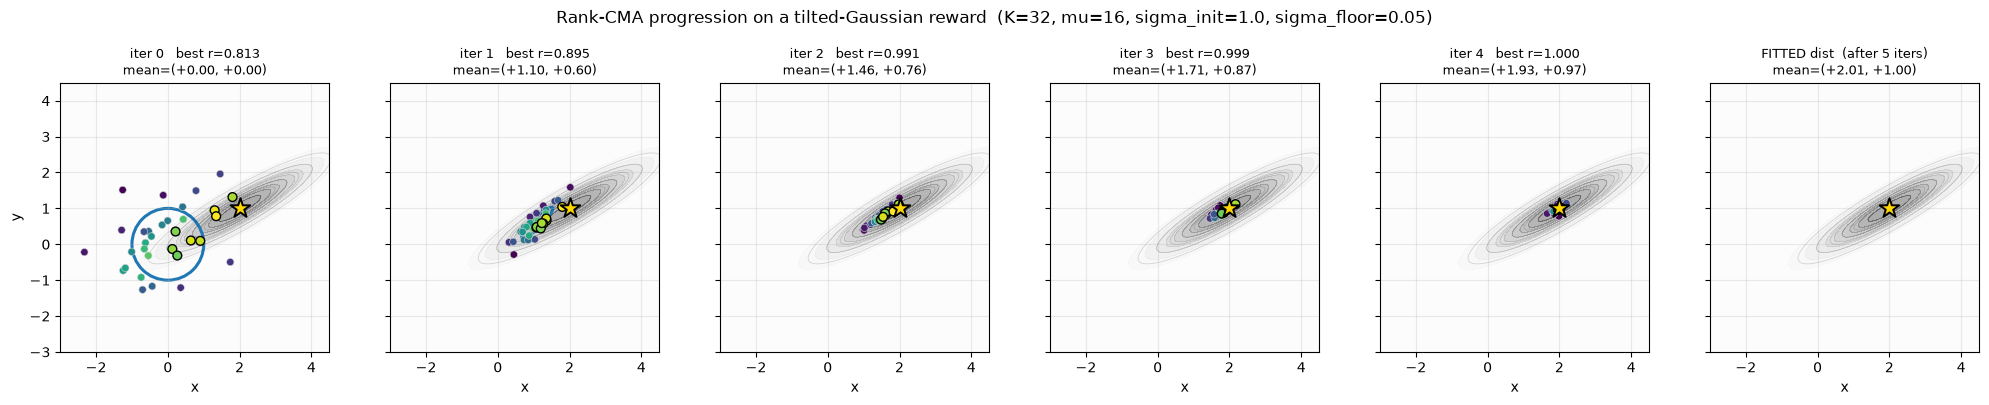

target = [2.0, 1.0]
 iter                  mean         sigma (eigvals)   best reward
    0      (+0.000, +0.000)          (1.000, 1.000)        0.8132
    1      (+1.101, +0.602)          (0.128, 0.598)        0.8951
    2      (+1.458, +0.762)          (0.050, 0.321)        0.9909
    3      (+1.706, +0.875)          (0.050, 0.167)        0.9992
    4      (+1.933, +0.970)          (0.050, 0.107)        1.0000
FITTED      (+2.007, +1.002)          (0.050, 0.050)             -


In [77]:
# Standalone visualization of the rank-CMA progression — no MuJoCo, no controllers.
# A toy 2D reward (elongated Gaussian bump, tilted) lets us see (a) the per-iteration
# sample cloud, (b) the rank ordering, (c) the resulting weighted mean + covariance
# that parameterises the NEXT iteration's distribution.
#
# Each iteration:
#   1. Draw K samples from N(mean, cov).
#   2. Score them with toy_reward; rank descending (best first).
#   3. CMA log-rank weights on the top-mu elites; others get weight 0.
#   4. new_mean = sum_k w_k * x_k     new_cov = sum_k w_k * (x_k - new_mean)(x_k - new_mean)^T
#   5. Eigenvalue floor on the cov so a direction can\'t collapse to a singularity.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# --- toy 2D reward: elongated tilted Gaussian bump, higher = better, in [0, 1] ---
TARGET   = np.array([2.0, 1.0])
SIGMA_X  = 1.5                                   # std along the bump\'s long axis
SIGMA_Y  = 0.3                                   # std along the bump\'s short axis
THETA    = np.pi / 6                             # rotation of the bump
_ROT     = np.array([[np.cos(THETA), -np.sin(THETA)],
                     [np.sin(THETA),  np.cos(THETA)]])
def toy_reward(X):
    """X: (..., 2) -> (...,) in (0, 1]. Pulls samples along an oblique ridge."""
    d_rot = (X - TARGET) @ _ROT
    return np.exp(-0.5 * ((d_rot[..., 0] / SIGMA_X) ** 2
                          + (d_rot[..., 1] / SIGMA_Y) ** 2))

# --- rank-CMA loop ---
K            = 32                                # samples per iteration
NUM_ELITES   = K // 2                            # top-mu kept
N_ITER       = 5
SIGMA_INIT   = 1.0                               # initial spherical stddev
SIGMA_FLOOR  = 0.05                              # eigenvalue floor (per axis)
SEED         = 0

rng  = np.random.default_rng(SEED)
mean = np.zeros(2, dtype=np.float64)
cov  = (SIGMA_INIT ** 2) * np.eye(2)

# Per-iteration snapshot: distribution USED to draw the samples (so panel t shows
# samples drawn from dist t; the dist for panel t+1 is what we fit from these).
history = []
for t in range(N_ITER):
    samples = rng.multivariate_normal(mean, cov, size=K)
    rewards = toy_reward(samples)
    order   = np.argsort(-rewards)               # descending: best at order[0]

    # CMA log-rank weights for top mu; rest get 0.
    ranks = np.arange(1, NUM_ELITES + 1, dtype=np.float64)
    w_top = np.maximum(0.0, np.log((NUM_ELITES + 1) / 2.0) - np.log(ranks))
    w_top /= w_top.sum()
    w = np.zeros(K, dtype=np.float64)
    w[order[:NUM_ELITES]] = w_top

    history.append(dict(samples=samples.copy(), rewards=rewards.copy(),
                        order=order.copy(), w=w.copy(),
                        mean=mean.copy(), cov=cov.copy()))

    # --- refit mean + cov ---
    new_mean = (w[:, None] * samples).sum(axis=0)
    delta    = samples - new_mean[None, :]
    new_cov  = (w[:, None, None] * delta[:, :, None] * delta[:, None, :]).sum(axis=0)
    eig, V   = np.linalg.eigh(new_cov)
    eig      = np.maximum(eig, SIGMA_FLOOR ** 2)
    new_cov  = V @ np.diag(eig) @ V.T

    mean, cov = new_mean, new_cov

# Final fitted distribution after all iterations (no samples shown).
history.append(dict(samples=None, rewards=None, order=None, w=None,
                    mean=mean.copy(), cov=cov.copy()))


# --- plot: one panel per iteration, plus a final "fitted distribution" panel ---
def _ellipse(ax, m, c, **kw):
    eigvals, eigvecs = np.linalg.eigh(c)
    angle = np.degrees(np.arctan2(eigvecs[1, -1], eigvecs[0, -1]))
    width, height = 2 * np.sqrt(eigvals[-1]), 2 * np.sqrt(eigvals[0])
    ax.add_patch(Ellipse(xy=m, width=width, height=height, angle=angle, fill=False, **kw))

# reward contour background
xs = np.linspace(-3.0, 4.5, 160)
ys = np.linspace(-3.0, 4.5, 160)
XX, YY = np.meshgrid(xs, ys)
R = toy_reward(np.stack([XX, YY], axis=-1))

n_panels = len(history)
fig, axes = plt.subplots(1, n_panels,
                          figsize=(3.4 * n_panels, 3.6),
                          sharex=True, sharey=True, squeeze=False)
axes = axes[0]
for t, snap in enumerate(history):
    ax = axes[t]
    ax.contourf(XX, YY, R, levels=10, cmap="Greys", alpha=0.35)
    ax.contour (XX, YY, R, levels=6,  colors="k",   alpha=0.15, linewidths=0.6)
    _ellipse(ax, snap["mean"], snap["cov"], edgecolor="tab:blue", lw=2.2, ls="-")

    if snap["samples"] is not None:
        samp, rew, order, w = snap["samples"], snap["rewards"], snap["order"], snap["w"]
        # rank colour: best (rank 0) = bright green, worst = grey
        rank_pos = np.argsort(order)                 # rank_pos[i] = rank of sample i (0=best)
        colours = plt.cm.viridis(1.0 - rank_pos / max(1, K - 1))
        # elites highlighted with a thick edge; non-elites thin grey edge
        is_elite = w > 0
        ax.scatter(samp[~is_elite, 0], samp[~is_elite, 1], c=colours[~is_elite],
                   s=28, edgecolor="lightgrey", linewidth=0.4, zorder=2)
        ax.scatter(samp[ is_elite, 0], samp[ is_elite, 1], c=colours[ is_elite],
                   s=40, edgecolor="k",         linewidth=1.0, zorder=3,
                   label=f"top {NUM_ELITES} elites")
        title = (f"iter {t}   best r={rew.max():.3f}\n"
                 f"mean=({snap['mean'][0]:+.2f}, {snap['mean'][1]:+.2f})")
    else:
        title = (f"FITTED dist  (after {N_ITER} iters)\n"
                 f"mean=({snap['mean'][0]:+.2f}, {snap['mean'][1]:+.2f})")

    ax.scatter(*TARGET, marker="*", s=220, color="gold", edgecolor="k", lw=1.4, zorder=5)
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.set_xlim(-3.0, 4.5); ax.set_ylim(-3.0, 4.5)

axes[0].set_ylabel("y")
for ax in axes:
    ax.set_xlabel("x")

fig.suptitle(
    f"Rank-CMA progression on a tilted-Gaussian reward  "
    f"(K={K}, mu={NUM_ELITES}, sigma_init={SIGMA_INIT}, sigma_floor={SIGMA_FLOOR})",
    y=1.04,
)
fig.tight_layout()
plt.show()

# Quick numeric summary so you can read the convergence without squinting at the plot.
print(f"target = {TARGET.tolist()}")
print(f"{'iter':>5s}  {'mean':>20s}  {'sigma (eigvals)':>22s}  {'best reward':>12s}")
for t, snap in enumerate(history):
    eig = np.sqrt(np.linalg.eigvalsh(snap["cov"]))
    rew = "-" if snap["rewards"] is None else f"{snap['rewards'].max():.4f}"
    mean_str = f"({snap['mean'][0]:+.3f}, {snap['mean'][1]:+.3f})"
    eig_str  = f"({eig[0]:.3f}, {eig[1]:.3f})"
    label    = "FITTED" if snap["samples"] is None else f"{t}"
    print(f"{label:>5s}  {mean_str:>20s}  {eig_str:>22s}  {rew:>12s}")


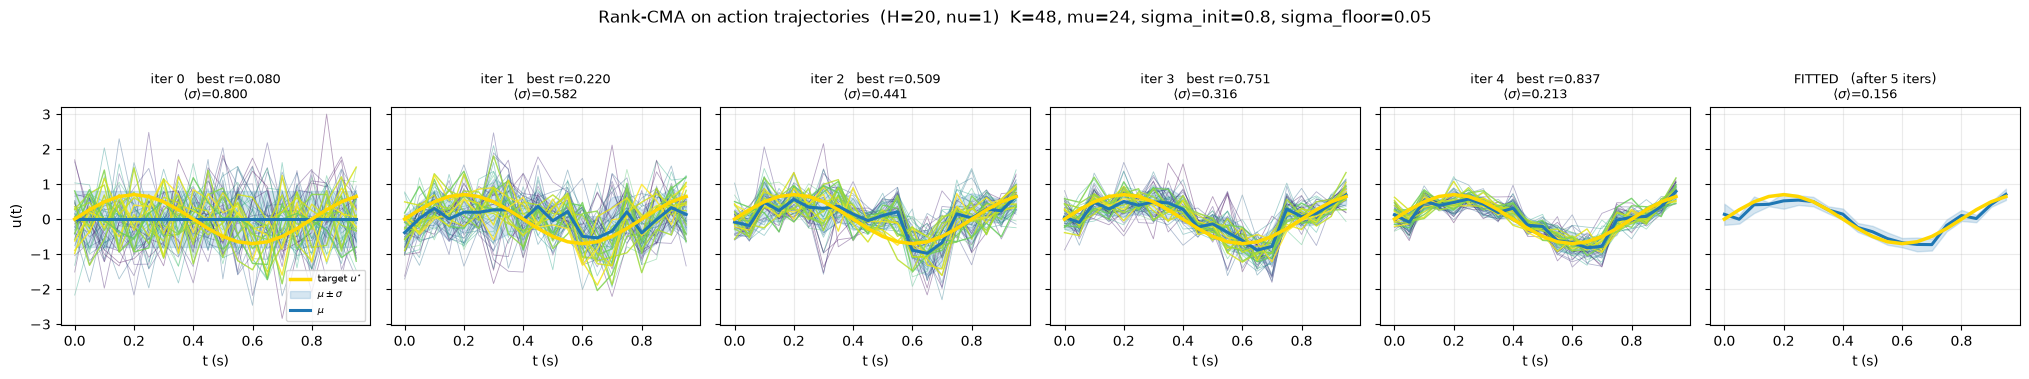

  iter   best reward     <|mu(t) - u*(t)|>     <sigma>
     0        0.0799                0.4224      0.8000
     1        0.2201                0.3461      0.5817
     2        0.5088                0.2471      0.4413
     3        0.7509                0.1927      0.3162
     4        0.8368                0.1591      0.2131
FITTED             -                0.1160      0.1556


In [78]:
# Rollout-space analog of the 2D demo above. Same rank-CMA recipe, but each
# sample is a full (H, nu) action trajectory drawn from a PER-STEP Gaussian
# (one (nu, nu) cov per horizon step). Reward = closeness to a target sine
# trajectory so we can watch the mean curve + per-step sigma band collapse
# toward the target as iterations proceed.
#
# The only conceptual change vs. cell 45 is dimensionality:
#   cell 45: samples in R^2,    cov is (2, 2),       ellipse visualisation
#   here:    samples in R^{H*nu}, cov is (H, nu, nu), mean-curve + sigma-band visualisation
import numpy as np
import matplotlib.pyplot as plt

# --- toy target trajectory ---
H         = 20                                              # horizon steps
DT_DEMO   = 0.05                                            # 1.5 s total
NU        = 1                                               # single actuator (1-D plot per panel)
T_GRID    = np.arange(H) * DT_DEMO
U_STAR    = 0.7 * np.sin(2.0 * np.pi * T_GRID / 0.8)        # target u(t), shape (H,)
SIGMA_OBJ = 0.30                                            # reward bandwidth (smaller = peakier)

def rollout_reward(U):
    """U: (..., H, nu) -> (...,) in (0, 1]. Mean-squared distance to U_STAR
    (averaged over H and nu), passed through a Gaussian bump."""
    target = U_STAR[..., None]                              # (H, 1) broadcasts to nu
    err2 = ((U - target) ** 2).mean(axis=(-2, -1))
    return np.exp(-0.5 * err2 / SIGMA_OBJ ** 2)

# --- rank-CMA loop (per-step distribution) ---
K            = 48
NUM_ELITES   = K // 2
N_ITER       = 5
SIGMA_INIT   = 0.8                                          # initial per-step stddev
SIGMA_FLOOR  = 0.05                                         # per-step eigenvalue floor
SEED         = 1

rng  = np.random.default_rng(SEED)
mean = np.zeros((H, NU), dtype=np.float64)                  # per-step mean
cov  = np.broadcast_to((SIGMA_INIT ** 2) * np.eye(NU),
                       (H, NU, NU)).copy()                  # per-step (nu, nu) cov

history = []
for t in range(N_ITER):
    # Per-step multivariate-normal sampling — same trick as RankCMA.sample_knots()
    samples = np.empty((K, H, NU), dtype=np.float64)
    for h in range(H):
        samples[:, h, :] = rng.multivariate_normal(mean[h], cov[h], size=K)
    rewards = rollout_reward(samples)
    order   = np.argsort(-rewards)                          # descending

    # CMA log-rank weights on the top mu rollouts
    ranks = np.arange(1, NUM_ELITES + 1, dtype=np.float64)
    w_top = np.maximum(0.0, np.log((NUM_ELITES + 1) / 2.0) - np.log(ranks))
    w_top /= w_top.sum()
    w = np.zeros(K, dtype=np.float64)
    w[order[:NUM_ELITES]] = w_top

    history.append(dict(samples=samples.copy(), rewards=rewards.copy(),
                        order=order.copy(), w=w.copy(),
                        mean=mean.copy(), cov=cov.copy()))

    # Refit per-step mean and covariance from weighted samples
    new_mean = np.einsum("k,khj->hj", w, samples)                   # (H, NU)
    delta    = samples - new_mean[None, ...]                        # (K, H, NU)
    new_cov  = np.einsum("k,khi,khj->hij", w, delta, delta)         # (H, NU, NU)
    eigvals, eigvecs = np.linalg.eigh(new_cov)                      # (H, NU), (H, NU, NU)
    eigvals  = np.maximum(eigvals, SIGMA_FLOOR ** 2)
    new_cov  = np.einsum("hij,hj,hkj->hik", eigvecs, eigvals, eigvecs)

    mean, cov = new_mean, new_cov

# Final fitted distribution after all iterations (no samples shown).
history.append(dict(samples=None, rewards=None, order=None, w=None,
                    mean=mean.copy(), cov=cov.copy()))


# --- plot: one panel per iteration, plus a final "fitted distribution" panel ---
n_panels = len(history)
fig, axes = plt.subplots(1, n_panels,
                          figsize=(3.4 * n_panels, 3.6),
                          sharex=True, sharey=True, squeeze=False)
axes = axes[0]

# y-limits picked from full data so panels are comparable
all_samp = np.concatenate([h["samples"].reshape(-1, H, NU)
                           for h in history if h["samples"] is not None], axis=0)
y_lo = min(float(all_samp.min()), float(U_STAR.min())) - 0.2
y_hi = max(float(all_samp.max()), float(U_STAR.max())) + 0.2

for t, snap in enumerate(history):
    ax = axes[t]

    # Target trajectory (gold)
    ax.plot(T_GRID, U_STAR, color="gold", lw=2.5, zorder=5,
            label=r"target $u^{\star}$" if t == 0 else None)

    # Mean curve + per-step +/-1 sigma band (the distribution that DREW these samples)
    m_curve     = snap["mean"][:, 0]
    sigma_curve = np.sqrt(np.maximum(snap["cov"][:, 0, 0], 0.0))
    ax.fill_between(T_GRID, m_curve - sigma_curve, m_curve + sigma_curve,
                    color="tab:blue", alpha=0.18,
                    label=r"$\mu \pm \sigma$" if t == 0 else None)
    ax.plot(T_GRID, m_curve, color="tab:blue", lw=2.2, zorder=4,
            label=r"$\mu$" if t == 0 else None)

    # Samples — colored by rank (viridis: bright = best, dim = worst); elites bold.
    if snap["samples"] is not None:
        samp     = snap["samples"]
        order    = snap["order"]
        w        = snap["w"]
        rank_pos = np.argsort(order)                                # 0 = best
        colours  = plt.cm.viridis(1.0 - rank_pos / max(1, K - 1))
        is_elite = w > 0
        # non-elites first (background), elites on top
        for k in np.where(~is_elite)[0]:
            ax.plot(T_GRID, samp[k, :, 0], color=colours[k], lw=0.6, alpha=0.40, zorder=1)
        for k in np.where( is_elite)[0]:
            ax.plot(T_GRID, samp[k, :, 0], color=colours[k], lw=1.0, alpha=0.85, zorder=2)
        title = (f"iter {t}   best r={snap['rewards'].max():.3f}\n"
                 fr"$\langle\sigma\rangle$={sigma_curve.mean():.3f}")
    else:
        title = (f"FITTED   (after {N_ITER} iters)\n"
                 fr"$\langle\sigma\rangle$={sigma_curve.mean():.3f}")

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("t (s)")
    ax.set_ylim(y_lo, y_hi)
    ax.grid(alpha=0.25)
    if t == 0:
        ax.legend(loc="lower right", fontsize=7)

axes[0].set_ylabel("u(t)")
fig.suptitle(
    f"Rank-CMA on action trajectories  (H={H}, nu={NU})  "
    f"K={K}, mu={NUM_ELITES}, sigma_init={SIGMA_INIT}, sigma_floor={SIGMA_FLOOR}",
    y=1.04,
)
fig.tight_layout()
plt.show()


# --- numeric summary ---
print(f"{'iter':>6s}  {'best reward':>12s}  {'<|mu(t) - u*(t)|>':>20s}  {'<sigma>':>10s}")
for t, snap in enumerate(history):
    err = float(np.abs(snap["mean"][:, 0] - U_STAR).mean())
    sig = float(np.sqrt(snap["cov"][:, 0, 0]).mean())
    rew = "-" if snap["rewards"] is None else f"{snap['rewards'].max():.4f}"
    label = "FITTED" if snap["samples"] is None else f"{t}"
    print(f"{label:>6s}  {rew:>12s}  {err:>20.4f}  {sig:>10.4f}")


In [79]:
# =============================================================================
#  RankCMA hyperparameters — used by both pendulum (Part 5) and walker (Part 6)
#  via the make_ctrl monkey-patches further down.
# =============================================================================

SKIP_EXPERIMENTS = False

# --- pendulum knobs ---
RCMA_SIGMA_INIT      = 0.5    # cov resets to sigma_init^2 * I each MPC step
RCMA_SIGMA_FLOOR     = 0.1    # eigenvalue floor on cov
RCMA_NUM_ELITES      = None   # top-rank samples that get nonzero weight (None -> K // 2)
RCMA_N_GD_ITER       = 5      # curvature-GD smoothing iters applied to each sampled rollout (0 to disable)
RCMA_GD_LR           = 0.05   # GD step size (must satisfy gd_lr <= 1/16 for stability)
RCMA_ITERATIONS      = 1      # CMA refit rounds per MPC step (sample -> rollout -> update mean & cov)
RCMA_BETA            = 10.0   # FplValueCMA softmax temperature on FPL reward (r in [0,1])
RCMA_COV_EMA_ALPHA   = 0.1    # EMA rate on cov update (only used when use_cov_update=True).
                              # alpha=1.0 -> wholesale replacement (previous behaviour, noisy).
                              # alpha=0.1 -> 10% new estimate + 90% old, smooths the cov estimate
                              # across MPC steps so accumulated elite directions persist.
                              # alpha=0.0 -> cov never updates (degenerates to mean-only).

# --- walker knobs ---
# NUM_ELITES tightened from None (= K // 2 = 64) to 8 and BETA raised from 10 to
# 25 so the FplValueCMA crossover gap (rank-prior spread / beta) matches the
# pendulum's. See the cov-EMA discussion above for what alpha controls.
W_RCMA_SIGMA_INIT      = 0.5
W_RCMA_SIGMA_FLOOR     = 0.1
W_RCMA_NUM_ELITES      = 8      # was None (= K // 2 = 64); tightens truncation
W_RCMA_N_GD_ITER       = 5
W_RCMA_GD_LR           = 0.05
W_RCMA_ITERATIONS      = 1
W_RCMA_BETA            = 25.0   # was 10.0; shrinks crossover Delta_r
W_RCMA_COV_EMA_ALPHA   = 0.1    # EMA rate on cov update (cov-on variants only)

# --- Part 1d: cost-GD refinement (per-rollout BPTT) knobs ---
# Per MPC step, on top of the K samples, the top-`num_refine` rollouts (by raw
# score) get `MPC_GD_ITERATIONS` rounds of gradient descent on the total cost
# wrt actions. The gradient is computed via BPTT through mujoco.mjd_transitionFD
# (single-step Jacobians) plus a per-step FD on the pure-numpy cost function.
# When iterations=0 the wrapper falls through to the unmodified rollout, so the
# unsuffixed algos remain reproducible.
MPC_GD_ITERATIONS              = 5      # GD steps per MPC step per rollout
MPC_GD_LR                      = 10.0   # GD step size. NB: FPL J=-reward with reward in [0,1]
                                        # keeps gradients in O(5e-3); lr~10 yields a ~15% per-MPC-step
                                        # cost reduction with iters=2 on pendulum. lr=0.05 is invisible.
                                        # For NORMAL cost mode where J has natural O(1) scale, lr~0.05 is fine.
MPC_GD_FD_EPS                  = 1e-6   # finite-difference epsilon for mjd_transitionFD AND cost FD
MPC_GD_FLG_CENTERED            = 1      # 1 = centered FD (2x cost, more accurate); 0 = one-sided
MPC_GD_USE_SENSOR_JAC_FROM_FD  = False  # if True: collect C from mjd_transitionFD instead of recomputing via mj_forward
MPC_GD_REFIT_KNOTS             = True   # project refined per-step controls back onto the knot basis via lstsq
MPC_GD_NUM_REFINE              = None   # rollouts to refine per MPC step. None -> ctrl.num_elites, else min(8, K)

# walker variant of the same knobs (kept separate so we can dial each task independently)
W_MPC_GD_ITERATIONS              = 2
W_MPC_GD_LR                      = 10.0    # same scaling reasoning as pendulum
W_MPC_GD_FD_EPS                  = 1e-6
W_MPC_GD_FLG_CENTERED            = 1
W_MPC_GD_USE_SENSOR_JAC_FROM_FD  = False
W_MPC_GD_REFIT_KNOTS             = True
W_MPC_GD_NUM_REFINE              = None


In [80]:
# =============================================================================
#  RankCMA — per-step multivariate Gaussian sampler with within-step rank-based
#  CMA refit. See the markdown above for the algorithmic motivation.
# =============================================================================

def _clamp_eigenvalues_local(cov, min_eig):
    """Per-knot symmetric eigenvalue clamp. cov: (H, nu, nu) -> same shape.
    Inlined from analytic_mppi/controllers/mppi_cma.py:_clamp_eigenvalues so this
    notebook section is self-contained.
    """
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, min_eig)
    return np.einsum("...ij,...j,...kj->...ik", eigvecs, eigvals, eigvecs)


class RankCMA(SamplingController):
    """Per-step multivariate-Gaussian sampler with within-step rank-weighted CMA refit.

    Each MPC step (for `iterations` internal rounds):
      a. Sample (K, H, nu) controls: per step h, draw K samples from
         N(self.mean[h], self.cov[h]). Clip to [u_min, u_max].
      b. Roll out and score (FPL or normal).
      c. Rank the K samples 1 (best) .. K (worst).
      d. Build STRIPPED-DOWN ACTIVE CMA-ES weights:
           * Positives:  w_i^+ = log(mu + 0.5) - log(i)            for i = 1..mu
                         normalised so sum(w^+) = 1.               (mu = num_elites)
                         All strictly positive, monotonically decreasing.
           * Negatives:  w_j^- magnitudes = log((K-mu) + 0.5) - log((K-mu) + 1 - j)
                         for j = 1..K-mu, then sign-flipped and scaled so
                         sum(w^-) = -alpha_neg.                    (alpha_neg knob)
                         Smallest magnitude at rank mu+1 (least bad), largest
                         at rank K (worst).
      e. mean[h]  <- sum_k w^+_k * sample_k[h]                 # POSITIVES ONLY
         cov[h]   <- (1 - cov_ema_alpha) * cov[h]              # EMA blend so
                   +  cov_ema_alpha * sum_k (w^+_k or w^-_k) * delta_k delta_k^T
         then eigenvalue-floored at sigma_floor^2.
      Final action sequence is the new mean (warm-shifted by dt via base).

    The cov update is gated by `use_cov_update` (default False). When False, the
    per-step cov stays at sigma_init^2 * I forever — only the rank-weighted mean
    update carries elite info between rounds / MPC steps. When True, the
    rank-mu (+ active-CMA tail) cov fit is blended into self.cov via an EMA
    with rate `cov_ema_alpha`. The eigenvalue floor is applied AFTER the blend.

    Why the EMA blend (vs wholesale replacement):
      Wholesale replacement each MPC step throws away whatever cov shape was
      learned in the previous step. The new estimate is fit from mu elites only
      (mu = 8 typical), which is heavily noise-dominated for any nontrivial nu.
      The EMA accumulates cov shape across steps, so good directions persist
      while bad ones decay -- mirrors MppiCma's covariance_adaptation_rate and
      is the cheap analogue of full CMA-ES cumulation.

    Differences from MppiCma:
      * Per-STEP, not per-knot — uses the (num_knots = H, tk = t_eval, spline_type="zero")
        trick so sample_knots() emits per-step controls directly.
      * Cov is WARM-SHIFTED across MPC steps (cov[h] <- cov[h+1], last slot
        reset to sigma_init**2 * I), mirroring the base class's mean warm-start.
        Elite directions therefore accumulate across the closed-loop run.
      * Weights come from CMA log-rank weights on the FPL ranking, not softmax of scores.
    """
    def __init__(self, task, backend, *, sigma_init=0.5, sigma_floor=0.1,
                 num_elites=None, alpha_neg=1.0,
                 n_gd_iter=5, gd_lr=0.05, use_cov_update=False,
                 cov_ema_alpha=0.1, **kwargs):
        kwargs.pop("spline_type", None)
        super().__init__(task, backend, spline_type="zero", **kwargs)
        self.num_knots = self.H
        self.tk = self.t_eval.copy()
        self.mean = np.zeros((self.num_knots, self.nu), dtype=np.float64)
        self.sigma_init  = float(sigma_init)
        self.sigma_floor = float(sigma_floor)
        self.num_elites  = (int(num_elites) if num_elites is not None
                            else max(1, self.num_samples // 2))
        # Negative-tail scaling. alpha_neg = 0 disables active negatives entirely
        # (rank-mu-only, mean+cov from positives). alpha_neg = 1 matches the
        # "balanced" intuition where neg contributions sum to -1 in magnitude.
        self.alpha_neg = float(alpha_neg)
        # If False, cov stays isotropic at sigma_init^2 * I and only the mean
        # update propagates elite info. If True, apply the rank-mu (+ active-CMA
        # tail) cov fit via EMA blend with eigenvalue floor.
        self.use_cov_update = bool(use_cov_update)
        # EMA rate for the cov update (used only when use_cov_update=True).
        # cov <- (1 - alpha) * cov + alpha * new_sample_cov, then eigenvalue-floored.
        self.cov_ema_alpha = float(cov_ema_alpha)
        # Curvature-GD smoothing applied to each sampled rollout BEFORE it is
        # rolled out and ranked. Matches UniformGD / GaussianGD: the rank-based
        # cov update is then fitted from smoothed trajectories, so the
        # distribution itself tracks smoothness-respecting rollouts.
        self.n_gd_iter = int(n_gd_iter)
        self.gd_lr     = float(gd_lr)
        eye = np.eye(self.nu, dtype=np.float64)
        self.cov = np.broadcast_to(
            (self.sigma_init ** 2) * eye,
            (self.num_knots, self.nu, self.nu),
        ).copy()

    def act(self, state):
        # NOTE: we intentionally do NOT reset cov each MPC step. The cov
        # learned from this step's elites carries into the next step (after
        # being warm-shifted by dt below), so good directions accumulate
        # across the closed-loop run rather than being re-discovered each step.
        u0 = super().act(state)
        # The base class already shifted self.mean by dt; do the same for cov
        # so the per-step (nu, nu) entries stay aligned with the per-step mean.
        self._shift_cov(self.backend.dt)
        return u0

    def _shift_cov(self, dt):
        """Warm-shift self.cov forward by one MPC step.

        Same idea as _shift_mean for spline_type="zero" / tk = t_eval:
            cov[h] <- cov[h + 1]   for h in [0, H - 1)
            cov[H - 1] <- sigma_init**2 * I   (fresh exploration at horizon end)
        """
        if self.num_knots <= 1:
            return
        new_cov = np.empty_like(self.cov)
        new_cov[:-1] = self.cov[1:]
        eye = np.eye(self.nu, dtype=np.float64)
        new_cov[-1]  = (self.sigma_init ** 2) * eye
        self.cov = new_cov

    def sample_knots(self):
        K, H = self.num_samples, self.num_knots
        out = np.empty((K, H, self.nu), dtype=np.float64)
        zero = np.zeros(self.nu)
        for h in range(H):
            out[:, h, :] = self.rng.multivariate_normal(zero, self.cov[h], size=K)
        out += self.mean[None, ...]
        u_min = np.asarray(self.task.u_min, dtype=np.float64)
        u_max = np.asarray(self.task.u_max, dtype=np.float64)
        np.clip(out, u_min, u_max, out=out)
        # Curvature-GD smoothing on the raw samples — same recipe as UniformGD /
        # GaussianGD. The downstream update_mean then fits the cov from these
        # smoothed trajectories, so the per-step covariance reflects the smoothed
        # distribution rather than the raw iid Gaussian draws.
        for _ in range(self.n_gd_iter):
            out -= self.gd_lr * smoothness_curv_grad(out)
            np.clip(out, u_min, u_max, out=out)
        return out

    def update_mean(self, traj):
        # Rank samples 1 (best) .. K (worst).
        if traj.reward is not None:
            order = np.argsort(-traj.reward)        # FPL: higher reward = better
        else:
            order = np.argsort(traj.scores)         # normal: lower cost = better

        K, mu = self.num_samples, self.num_elites
        alpha = self.alpha_neg

        # ---- Positive weights for ranks 1..mu --------------------------------
        # log(mu + 0.5) - log(i): strictly positive for all i in [1, mu], so the
        # whole top-mu cohort contributes (unlike log((mu+1)/2) - log(i) which
        # silently halves mu via the max-zero clamp).
        pos_ranks = np.arange(1, mu + 1, dtype=np.float64)
        w_pos = np.log(mu + 0.5) - np.log(pos_ranks)
        w_pos /= w_pos.sum()                         # sum(w_pos) = 1

        # ---- Negative weights for ranks mu+1..K (active-CMA tail) ------------
        # Mirror the same log-rank shape across the bad half and flip sign so
        # sum(w_neg) = -alpha_neg. Magnitudes increase toward rank K (the worst
        # rollout gets the strongest "push variance away from this direction"
        # contribution to the cov update).
        n_neg = K - mu
        if n_neg > 0 and alpha > 0.0:
            j = np.arange(1, n_neg + 1, dtype=np.float64)
            w_neg_mag = np.log(n_neg + 0.5) - np.log(n_neg + 1 - j)
            w_neg = -alpha * w_neg_mag / w_neg_mag.sum()   # sum(w_neg) = -alpha
        else:
            w_neg = np.zeros(max(n_neg, 0), dtype=np.float64)

        # ---- Scatter into K-length vectors in SAMPLE order ------------------
        # `order[i]` is the sample index whose rank is i+1. The MEAN update uses
        # positives only; the COV update uses positives + negatives.
        w_mean = np.zeros(K, dtype=np.float64)
        w_cov  = np.zeros(K, dtype=np.float64)
        w_mean[order[:mu]] = w_pos
        w_cov[order[:mu]]  = w_pos
        if n_neg > 0:
            w_cov[order[mu:]] = w_neg

        # ---- Mean update (positives only) -----------------------------------
        new_mean = np.einsum("k,khj->hj", w_mean, traj.knots)

        # ---- Cov update (positives + negatives) -----------------------------
        # Gated by use_cov_update. EMA blend with rate cov_ema_alpha so the
        # per-step cov accumulates across MPC steps instead of being thrown
        # away each round. Negative outer products are no longer guaranteed
        # PSD; the eigenvalue floor acts as a safety net (analytic PSD
        # guarantees require the full c_1 / c_mu / cumulation machinery we
        # don't have here).
        if self.use_cov_update:
            delta = traj.knots - new_mean[None, ...]
            new_sample_cov = np.einsum("k,khi,khj->hij", w_cov, delta, delta)
            blended = (1.0 - self.cov_ema_alpha) * self.cov + self.cov_ema_alpha * new_sample_cov
            self.cov = _clamp_eigenvalues_local(blended, self.sigma_floor ** 2)
        return new_mean


### FPL value-weighted sampling — math

**Setup.** At each MPC step we draw $K$ rollouts and assign each one a non-negative weight $w_k$ ($\sum_k w_k = 1$). The new sampling mean (per timestep $h$) is

$$
\boldsymbol{\mu}_h \;\leftarrow\; \sum_{k=1}^K w_k\, \mathbf{u}_{k,h}.
$$

The only freedom is how to choose $w_k$ from the rollout scores.

### Why the obvious designs fail

**RankCMA (the strong baseline).** Log-rank weights inside the top-$\mu$:

$$
w_k^{\text{rank}} \;\propto\; \log(\mu + \tfrac12) - \log(\text{rank}(k))\qquad k \in \text{top-}\mu, \quad \text{else } 0.
$$

For $\mu = 4$: $w^{\text{rank}} \approx (0.524, 0.282, 0.141, 0.041)$ — *always* this exact distribution, independent of reward magnitudes. Throws away FPL absolute-scale info, but **strongly asymmetric**.

**v1 attempt: softmax over all $K$.** $w_k \propto \exp(\beta r_k)$.

Failure: when rewards cluster (early phase, all $r \approx 0.05$), softmax is near-uniform → no truncation, no asymmetry → mean barely moves. Stalls.

**v2 attempt: top-$\mu$ truncation, then softmax-on-value within elites.**

Failure (subtler): in the clustered regime the within-elite softmax is *still* near-uniform → $w \approx (0.27, 0.26, 0.24, 0.23)$ over the elites. The $K$ samples were drawn iid from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, so a near-uniform average over half of them returns approximately $\boldsymbol{\mu}$ itself — **the new mean equals the prior mean** (modulo sampling noise). The controller has nothing to refine and stalls.

The key insight that v2 missed: **RankCMA's strength is not "rank carries information," it's "log-rank weights are asymmetric ($w_1 = 0.52$ regardless of gap size), which breaks the symmetry of the iid sample cloud and forces directional progress."** Any value-only weighting that lets weights become near-uniform loses this property.

### v3 (current): log-rank "prior" × value-softmax "bonus"

Combine the two multiplicatively inside the top-$\mu$ elites. In log-space:

$$
\boxed{\;\log w_k \;\propto\; \underbrace{\log\!\bigl[\log(\mu + \tfrac12) - \log(\text{rank}(k))\bigr]}_{\displaystyle \ell_k^{\text{rank}}\;\text{(asymmetric commitment)}} \;+\; \underbrace{\beta\, r_k}_{\displaystyle \ell_k^{\text{val}}\;\text{(FPL absolute-scale bonus)}}\;}
$$

then softmax-normalise over the elites. Equivalently:

$$
w_k \;\propto\; \bigl[\log(\mu + \tfrac12) - \log(\text{rank}(k))\bigr] \cdot \exp(\beta r_k), \qquad k \in \text{top-}\mu.
$$

**Spread arithmetic** (for $\mu = 4$):

- Rank-prior spread: $\ell_1^{\text{rank}} - \ell_\mu^{\text{rank}} = \log(1.504) - \log(0.118) \approx 2.55$ nats. Constant, independent of rewards.
- Value-bonus spread: $\beta (r_1 - r_\mu)$. Proportional to the *absolute* reward gap.

Whichever spread is larger dominates the weighting:

| Regime | $\Delta r$ over top-$\mu$ | Value spread ($\beta = 10$) | Dominant term | Resulting $w$ on top-$\mu$ | Mean behaviour |
|---|---|---|---|---|---|
| Clustered / all bad | $\sim 0.05$ | $0.5$ | rank prior (2.55) | $\approx (0.52, 0.28, 0.14, 0.04)$ | matches RankCMA — asymmetric, commits |
| Mixed | $\sim 0.30$ | $3.0$ | comparable | $\approx (0.74, 0.18, 0.06, 0.01)$ | leans toward winner, still committed |
| Clear winner | $\sim 0.55$ | $5.5$ | value bonus | $\approx (0.96, 0.03, 0.006, 0.0003)$ | near-greedy on the absolute winner |

The crossover gap where the value bonus starts overtaking the rank prior is $\Delta r \approx 2.55 / \beta$. With $\beta = 10$, that's $\Delta r \approx 0.25$ — once the reward gap is "real," the absolute-scale info takes over. With $\beta = 5$, the crossover moves to $\Delta r \approx 0.5$ (more conservative). With $\beta = 20$, to $\Delta r \approx 0.13$ (more aggressive on the FPL signal).

### Limiting cases

| $\beta$ | Weights collapse to | Equivalent to |
|---|---|---|
| $0$ | $w_k \propto \log(\mu + \tfrac12) - \log(\text{rank}(k))$ | **RankCMA exactly** |
| $\infty$ | $w_k = \delta_{k, \arg\max r}$ | argmax-reward, one-hot |
| finite | smooth interpolation | log-rank prior with value-softmax modulation |

So `FplValueCMA` is **strictly never worse than RankCMA** in expectation — it inherits RankCMA's commitment in the clustered regime ($\beta r$ contribution drops out when reward magnitudes are flat) and only adds extra concentration when the FPL absolute scale provides a real signal.

### Why FPL is the enabling ingredient

With normal cost, $J_k$ has no fixed scale across tasks: it may live in $[0, 10]$ on pendulum and $[0, 10^6]$ on walker. No single $\beta$ makes the $\beta J_k$ term meaningful across tasks. FPL's $[0, 1]$ contract is what makes the value bonus task-agnostic — the same $\beta = 10$ has the same gap-to-weight semantics everywhere.

### Cov update (when `use_cov_update=True`)

The same combined weights drive a standard MPPI-CMA-style outer-product fit:

$$
\boldsymbol{\Sigma}_h \;\leftarrow\; \sum_k w_k \,(\mathbf{u}_{k,h} - \boldsymbol{\mu}_h)(\mathbf{u}_{k,h} - \boldsymbol{\mu}_h)^\top,
$$

eigenvalue-floored at $\sigma_{\text{floor}}^2$. Non-elite weights are $0$ and elite weights are strictly positive (product of two positive factors), so the sum is PSD by construction — no active-CMA negative-tail machinery needed.


In [81]:
# =============================================================================
#  FplValueCMA — log-rank "prior" times value-softmax "bonus" on the top-mu
#  elites. See the markdown above for the diagnostic of why simpler designs
#  (pure value softmax, with or without truncation) stalled empirically.
#
#  Requires FPL mode (use_fpl_cost or use_fpl_discounted).
# =============================================================================

class FplValueCMA(RankCMA):
    """Per-step Gaussian sampler combining RankCMA's asymmetric-commitment rank
    weighting with an FPL-value-softmax "bonus" inside the top-mu elite cohort.

    Mean weight construction (per MPC refit round):

      1. Truncate to top-mu elites by FPL reward (argsort on -r).
      2. Build two unnormalised log-weights on the mu elites:
           log_rank_k = log( log(mu + 0.5) - log(rank(k)) )      # always > -inf
           log_val_k  = beta * r_k                                # r_k in [0, 1]
      3. Combine multiplicatively (additively in log-space):
           w_k proportional to  exp(log_rank_k + log_val_k)
                            =  [log(mu+0.5) - log(rank(k))] * exp(beta * r_k)
         then normalize so sum(w_k) = 1 over the elites.
      4. Non-elite samples get weight 0.

    Why the combination is multiplicative:
      The rank-prior provides ASYMMETRIC commitment that breaks the symmetry of
      the iid Gaussian sample cloud. Without it (pure value-softmax v2), in the
      clustered-reward regime (all r near 0.05, spread ~0.04) the softmax
      collapses to near-uniform over the elites and the weighted mean tends
      back to the centroid of the symmetric sample cloud, i.e. to the prior
      mean -- the controller stops making directional progress and stalls.

      The value-bonus uses the FPL absolute scale: when ONE elite is clearly
      better in absolute terms (e.g. r_1 = 0.95 vs r_2 = 0.40), beta * (r_1-r_2)
      = 5.5 dominates the ~2.5 nat rank-prior spread and the algorithm
      concentrates aggressively on the winner. RankCMA cannot see this
      distinction because its rank weights are independent of magnitudes.

    Limiting cases:
      beta = 0        : pure RankCMA log-rank weights (no value info)
      beta -> infinity: one-hot on argmax_k r_k (pure greedy on absolute value)
      beta = 10       : crossover gap is approx Delta_r ~ 2.5 / 10 = 0.25 --
                        below that, rank dominates; above, value dominates.

    Knobs:
      beta            : softmax temperature on FPL reward.
      num_elites      : top-rank truncation (inherited; defaults to K // 2).
      use_cov_update  : if True, the SAME combined weights drive a rank-mu-style
                        cov fit (Sigma <- sum_k w_k delta_k delta_k^T) blended
                        into self.cov via EMA at rate cov_ema_alpha, then
                        eigenvalue-floored. If False, cov stays at sigma_init^2 * I.
      cov_ema_alpha   : EMA rate on the cov update (inherited from RankCMA).
                        alpha=1.0 -> wholesale replacement (noisy).
                        alpha=0.1 -> smooth accumulation across MPC steps.

    Strict difference from RankCMA:
      * within-elite weights are LOG-RANK times VALUE-SOFTMAX, not log-rank only
      * no active-CMA negative tail on the cov update (positivity of weights
        keeps the outer-product sum PSD without rank-1 machinery)
    """

    def __init__(self, *args, beta=10.0, **kwargs):
        super().__init__(*args, **kwargs)
        if not (self.use_fpl_cost or self.use_fpl_discounted):
            raise ValueError(
                "FplValueCMA requires FPL mode (use_fpl_cost or use_fpl_discounted). "
                "Normal-cost mode has no fixed reward scale and absolute-value "
                "weighting is undefined there -- use RankCMA / MppiCma instead."
            )
        self.beta = float(beta)

    def update_mean(self, traj):
        if traj.reward is None:
            raise RuntimeError("FplValueCMA: traj.reward is None; FPL scoring did not populate it.")
        r = traj.reward                                       # (K,) in [0, 1]
        K, mu = self.num_samples, self.num_elites

        # ---- Stage 1: top-mu truncation by FPL reward ----------------------
        order = np.argsort(-r)                                # best -> worst
        elite_idx = order[:mu]
        r_elites = r[elite_idx]                               # (mu,)

        # ---- Stage 2a: log-rank prior (asymmetric commitment) --------------
        # log_rank_k = log( log(mu + 0.5) - log(rank) ), ranks 1..mu.
        # Spread is about 2.5 nats for mu=4 (log(1.504) - log(0.118) ~ 2.55).
        # This drives the asymmetric weighting that breaks sample-cloud symmetry
        # and produces directional progress even when rewards are clustered.
        pos_ranks = np.arange(1, mu + 1, dtype=np.float64)
        rank_raw = np.log(mu + 0.5) - np.log(pos_ranks)       # (mu,), strictly > 0
        log_rank = np.log(rank_raw)                           # (mu,), unnormalised log-weights

        # ---- Stage 2b: FPL value bonus -------------------------------------
        # beta * r_k uses the absolute [0, 1] scale of FPL reward. When the
        # reward gap is meaningful (~ 0.25 with beta=10), this term takes over
        # and the combined weighting concentrates on the absolute winner.
        log_val = self.beta * r_elites                        # (mu,)

        # ---- Stage 2c: combine in log-space and softmax --------------------
        log_w = log_rank + log_val                            # (mu,)
        log_w = log_w - log_w.max()                           # numerical stability
        w_elites = np.exp(log_w)
        s = w_elites.sum()
        if s <= 0.0 or not np.isfinite(s):
            # Pathological case (shouldn't happen with finite beta and r in [0,1]).
            best = int(np.argmax(r))
            return traj.knots[best].copy()
        w_elites = w_elites / s                               # (mu,) sums to 1

        # ---- Scatter into K-length weight vector --------------------------
        w = np.zeros(K, dtype=np.float64)
        w[elite_idx] = w_elites

        # ---- Mean update ---------------------------------------------------
        new_mean = np.einsum("k,khj->hj", w, traj.knots)

        # ---- Cov update (optional) ----------------------------------------
        # EMA blend (rate cov_ema_alpha inherited from RankCMA) so the per-step
        # cov accumulates across MPC steps instead of being thrown away each
        # round. Non-elite weights are 0 and elite weights are positive, so the
        # outer-product sum is PSD by construction; the eigenvalue floor is a
        # numerical safety net.
        if self.use_cov_update:
            delta = traj.knots - new_mean[None, ...]          # (K, H, nu)
            new_sample_cov = np.einsum("k,khi,khj->hij", w, delta, delta)
            blended = (1.0 - self.cov_ema_alpha) * self.cov + self.cov_ema_alpha * new_sample_cov
            self.cov = _clamp_eigenvalues_local(blended, self.sigma_floor ** 2)
        return new_mean


In [82]:
# =============================================================================
#  Wire RankCMA / FplValueCMA into the existing make_ctrl / make_ctrl_walker
#  factories from Parts 5 / 6 via a monkey-patch. Keeps all per-class code in
#  this section so the wiring + implementation live together. Re-runnable: the
#  original factories are captured only on the FIRST execution of this cell;
#  subsequent re-runs preserve the originals so make_ctrl can't recurse into
#  itself.
#
#  Algo strings dispatched here:
#    "rank_cma"           -> RankCMA, use_cov_update=False   (rank, mean-only)
#    "rank_cma_cov"       -> RankCMA, use_cov_update=True    (rank, mean + cov w/ EMA)
#    "fpl_value_cma"      -> FplValueCMA, use_cov_update=False (value, mean-only)
#    "fpl_value_cma_cov"  -> FplValueCMA, use_cov_update=True  (value, mean + cov w/ EMA)
# =============================================================================

# Idempotent capture: only save the originals once. Without this guard, re-running
# this cell would set _make_ctrl_orig = (already-patched make_ctrl), and the patched
# version would call itself -> RecursionError.
if "_make_ctrl_orig" not in globals():
    _make_ctrl_orig = make_ctrl
if "_make_ctrl_walker_orig" not in globals():
    # make_ctrl_walker only exists after Part 6 has been run; tolerate its absence
    # so this cell can run even if you skipped Part 6.
    _make_ctrl_walker_orig = globals().get("make_ctrl_walker", None)

_RANK_ALGOS = ("rank_cma", "rank_cma_cov")
_FPL_VAL_ALGOS = ("fpl_value_cma", "fpl_value_cma_cov")
_RCMA_ALGOS = _RANK_ALGOS + _FPL_VAL_ALGOS


def make_ctrl(algo, cost_mode, seed=None):
    if algo not in _RCMA_ALGOS:
        return _make_ctrl_orig(algo, cost_mode, seed=seed)
    t = make_task("pendulum")
    b = MujocoBackend(t.model_path)
    common = dict(
        num_samples=K5,
        num_knots=NUM_KNOTS,             # ignored by RankCMA (it overrides num_knots = H)
        plan_horizon=H5_PLAN,
        spline_type=SPLINE_TYPE,
        iterations=RCMA_ITERATIONS,      # internal CMA refit rounds per MPC step
        seed=(SEED if seed is None else int(seed)),
        **_fpl_kwargs(cost_mode),
    )
    use_cov = algo in ("rank_cma_cov", "fpl_value_cma_cov")
    if algo in _RANK_ALGOS:
        c = RankCMA(t, b, sigma_init=RCMA_SIGMA_INIT,
                    sigma_floor=RCMA_SIGMA_FLOOR,
                    num_elites=RCMA_NUM_ELITES,
                    n_gd_iter=RCMA_N_GD_ITER, gd_lr=RCMA_GD_LR,
                    use_cov_update=use_cov,
                    cov_ema_alpha=RCMA_COV_EMA_ALPHA,
                    **common)
    else:
        c = FplValueCMA(t, b, sigma_init=RCMA_SIGMA_INIT,
                        sigma_floor=RCMA_SIGMA_FLOOR,
                        num_elites=RCMA_NUM_ELITES,
                        n_gd_iter=RCMA_N_GD_ITER, gd_lr=RCMA_GD_LR,
                        use_cov_update=use_cov,
                        cov_ema_alpha=RCMA_COV_EMA_ALPHA,
                        beta=RCMA_BETA,
                        **common)
    return t, b, c


def make_ctrl_walker(algo, cost_mode, seed=None):
    if algo not in _RCMA_ALGOS:
        if _make_ctrl_walker_orig is None:
            raise NameError("make_ctrl_walker not defined — run Part 6 cells first")
        return _make_ctrl_walker_orig(algo, cost_mode, seed=seed)
    t = make_task("walker")
    b = MujocoBackend(t.model_path)
    common = dict(
        num_samples=W_K,
        num_knots=W_NUM_KNOTS,
        plan_horizon=W_PLAN_HORIZON,
        spline_type=W_SPLINE_TYPE,
        iterations=W_RCMA_ITERATIONS,    # internal CMA refit rounds per MPC step
        seed=(W_SEED if seed is None else int(seed)),
        **_fpl_kwargs_w(cost_mode),
    )
    use_cov = algo in ("rank_cma_cov", "fpl_value_cma_cov")
    if algo in _RANK_ALGOS:
        c = RankCMA(t, b, sigma_init=W_RCMA_SIGMA_INIT,
                    sigma_floor=W_RCMA_SIGMA_FLOOR,
                    num_elites=W_RCMA_NUM_ELITES,
                    n_gd_iter=W_RCMA_N_GD_ITER, gd_lr=W_RCMA_GD_LR,
                    use_cov_update=use_cov,
                    cov_ema_alpha=W_RCMA_COV_EMA_ALPHA,
                    **common)
    else:
        c = FplValueCMA(t, b, sigma_init=W_RCMA_SIGMA_INIT,
                        sigma_floor=W_RCMA_SIGMA_FLOOR,
                        num_elites=W_RCMA_NUM_ELITES,
                        n_gd_iter=W_RCMA_N_GD_ITER, gd_lr=W_RCMA_GD_LR,
                        use_cov_update=use_cov,
                        cov_ema_alpha=W_RCMA_COV_EMA_ALPHA,
                        beta=W_RCMA_BETA,
                        **common)
    return t, b, c


print("RankCMA + FplValueCMA wired via algos:")
print('  "rank_cma"          -> RankCMA(rank, mean-only)')
print('  "rank_cma_cov"      -> RankCMA(rank, mean+cov w/ EMA alpha=%g)' % RCMA_COV_EMA_ALPHA)
print('  "fpl_value_cma"     -> FplValueCMA(value, mean-only)   [requires FPL cost_mode]')
print('  "fpl_value_cma_cov" -> FplValueCMA(value, mean+cov w/ EMA alpha=%g)   [requires FPL cost_mode]' % RCMA_COV_EMA_ALPHA)


RankCMA + FplValueCMA wired via algos:
  "rank_cma"          -> RankCMA(rank, mean-only)
  "rank_cma_cov"      -> RankCMA(rank, mean+cov w/ EMA alpha=0.1)
  "fpl_value_cma"     -> FplValueCMA(value, mean-only)   [requires FPL cost_mode]
  "fpl_value_cma_cov" -> FplValueCMA(value, mean+cov w/ EMA alpha=0.1)   [requires FPL cost_mode]


## Part 1d — Cost-gradient refined MPC (BPTT through mjd_transitionFD)

Adds a `_costgd` variant of every sampling-MPC algorithm. At each MPC step:

1. The base algorithm samples its `K` candidate knot sequences as before.
2. The candidates are interpolated to per-step controls and rolled out in parallel (cheap multi-threaded `mujoco.rollout`).
3. The top-`num_refine` rollouts by raw score are picked (`num_refine = num_elites` by default).
4. **NEW**: each of those gets `MPC_GD_ITERATIONS` gradient-descent steps on the total trajectory cost via BPTT through `mujoco.mjd_transitionFD`.
5. If `refit_knots`, the refined per-step controls are projected back onto the knot basis via least-squares so the downstream weighted-mean / rank / value-softmax update operates on the refined parameterisation.
6. Standard scoring + update proceeds, unchanged downstream.

### Cost gradient (BPTT)

Let $J$ be the total trajectory cost. For each refined rollout we want $\partial J / \partial u_t$, $t = 0, \dots, H-1$.

The cost chain after the rollout is pure numpy:

$$J \;=\; \text{score}\bigl(q(s_{0..H-1}),\; v(s_{0..H-1}),\; \text{sensor}_{0..H-1},\; u_{0..H-1}\bigr).$$

We compute $\partial J / \partial q_t, \partial J / \partial v_t, \partial J / \partial \text{sensor}_t, \partial J / \partial u_t$ analytically (chain rule through the cost aggregation) combined with **per-step FD** on `running_cost_terms[_f]` for the inner Jacobian — one FD call per slot column, vectorised across the $M \times H$ batch. The cost aggregation gradient is closed-form for `normal`, `fpl_cost`, and `fpl_discounted` modes.

Sensor gradient: under the MVP, assume sensors are pure functions of state and fold $\partial J / \partial \text{sensor}_t$ into $\partial J / \partial q_t / \partial v_t$ via `mj_forward`-based FD. Toggle `MPC_GD_USE_SENSOR_JAC_FROM_FD=True` to use the $C$ matrix from `mjd_transitionFD` instead.

### BPTT recurrence

Per-step Jacobians come from `mujoco.mjd_transitionFD`: $A_t = \partial s_{t+1} / \partial s_t$ and $B_t = \partial s_{t+1} / \partial u_t$, both in mujoco's velocity-space $(2n_v + n_a)$. For walker / pendulum, $n_q = n_v$ so the velocity-space layout aligns with the FULLPHYSICS layout used in the rollouts.

Reverse-mode adjoint:

$$\text{adj}_{H-1} = \partial J / \partial s_{H-1}, \quad \text{grad}_{H-1} = \partial J / \partial u_{H-1} + B_{H-1}^\top \text{adj}_{H-1}$$
$$\text{adj}_t = \partial J / \partial s_t + A_{t+1}^\top \text{adj}_{t+1}, \quad \text{grad}_t = \partial J / \partial u_t + B_t^\top \text{adj}_t \quad (t = H-2, \dots, 0)$$

### Cost mitigation

Walker has $K = 128$ and $H = 100$; per-step Jacobians would be ~100× the baseline. We refine only the top-`num_refine` rollouts (defaults to `num_elites` = 8 on walker, 4 on pendulum), so the GD pass touches a small subset. Roughly $6-8\times$ slowdown on walker, $2-3\times$ on pendulum.

### Limiting cases

`MPC_GD_ITERATIONS = 0` short-circuits the entire wrapper, reproducing the un-suffixed baselines bit-exactly. This is the seed-stable equivalence check.


In [83]:
# =============================================================================
#  Part 1d helpers — rollout_with_jacobians, sensor-Jacobian-via-mj_forward,
#  analytic gradient through cost aggregation, BPTT.
# =============================================================================
import numpy as np
import mujoco
from types import MethodType


def rollout_with_jacobians(backend, initial, controls, fd_eps=1e-6, flg_centered=1,
                            use_sensor_jac_from_FD=False):
    """Stepped rollout collecting per-step Jacobians via mujoco.mjd_transitionFD.

    Returns:
        states (M, H, nstate), sensordata (M, H, ns_sensor),
        A_seq (M, H, ns_v, ns_v), B_seq (M, H, ns_v, nu),
        C_seq (M, H, ns_sensor, ns_v) or None,
        D_seq (M, H, ns_sensor, nu) or None.
    Note ns_v = 2*nv + na (mjd_transitionFD's velocity-space layout).
    """
    model = backend.model
    M, H, nu = controls.shape
    nstate = backend.nstate
    nv = int(model.nv)
    na = int(model.na)
    ns_v = 2 * nv + na
    ns_sensor = backend.nsensordata

    states = np.empty((M, H, nstate), dtype=np.float64)
    sensordata = np.empty((M, H, ns_sensor), dtype=np.float64)
    A_seq = np.empty((M, H, ns_v, ns_v), dtype=np.float64)
    B_seq = np.empty((M, H, ns_v, nu), dtype=np.float64)
    C_seq = np.empty((M, H, ns_sensor, ns_v), dtype=np.float64) if use_sensor_jac_from_FD else None
    D_seq = np.empty((M, H, ns_sensor, nu), dtype=np.float64) if use_sensor_jac_from_FD else None

    A_buf = np.empty((ns_v, ns_v), dtype=np.float64)
    B_buf = np.empty((ns_v, nu), dtype=np.float64)
    C_buf = np.empty((ns_sensor, ns_v), dtype=np.float64) if use_sensor_jac_from_FD else None
    D_buf = np.empty((ns_sensor, nu), dtype=np.float64) if use_sensor_jac_from_FD else None

    state_spec_int = int(backend.state_spec)
    data = mujoco.MjData(model)

    for m in range(M):
        mujoco.mj_setState(model, data, initial[m], state_spec_int)
        mujoco.mj_forward(model, data)
        for t in range(H):
            data.ctrl[:] = controls[m, t]
            mujoco.mjd_transitionFD(model, data, fd_eps, flg_centered, A_buf, B_buf, C_buf, D_buf)
            A_seq[m, t] = A_buf
            B_seq[m, t] = B_buf
            if use_sensor_jac_from_FD:
                C_seq[m, t] = C_buf
                D_seq[m, t] = D_buf
            mujoco.mj_step(model, data)
            mujoco.mj_getState(model, data, states[m, t], state_spec_int)
            sensordata[m, t] = data.sensordata

    return states, sensordata, A_seq, B_seq, C_seq, D_seq


def sensor_jac_via_forward(backend, states_full, fd_eps=1e-6):
    """Per-step sensor Jacobian d(sensor)/d(qpos, qvel) via mj_forward + FD.

    For each (m, t) state, perturb qpos[j] / qvel[j] by eps, call mj_forward, read sensor.
    Costs M*H*(nq+nv) mj_forward calls. Assumes sensor depends only on state.
    """
    model = backend.model
    M, H, nstate = states_full.shape
    nq = int(model.nq)
    nv = int(model.nv)
    ns = backend.nsensordata
    state_spec_int = int(backend.state_spec)
    qpos_start = backend.qpos_slice.start
    qvel_start = backend.qvel_slice.start

    dsens_dqpos = np.empty((M, H, ns, nq), dtype=np.float64)
    dsens_dqvel = np.empty((M, H, ns, nv), dtype=np.float64)

    data = mujoco.MjData(model)

    for m in range(M):
        for t in range(H):
            state_ref = states_full[m, t]
            for j in range(nq):
                sp = state_ref.copy(); sp[qpos_start + j] += fd_eps
                sm = state_ref.copy(); sm[qpos_start + j] -= fd_eps
                mujoco.mj_setState(model, data, sp, state_spec_int); mujoco.mj_forward(model, data)
                splus = data.sensordata.copy()
                mujoco.mj_setState(model, data, sm, state_spec_int); mujoco.mj_forward(model, data)
                sminus = data.sensordata.copy()
                dsens_dqpos[m, t, :, j] = (splus - sminus) / (2 * fd_eps)
            for j in range(nv):
                sp = state_ref.copy(); sp[qvel_start + j] += fd_eps
                sm = state_ref.copy(); sm[qvel_start + j] -= fd_eps
                mujoco.mj_setState(model, data, sp, state_spec_int); mujoco.mj_forward(model, data)
                splus = data.sensordata.copy()
                mujoco.mj_setState(model, data, sm, state_spec_int); mujoco.mj_forward(model, data)
                sminus = data.sensordata.copy()
                dsens_dqvel[m, t, :, j] = (splus - sminus) / (2 * fd_eps)
    return dsens_dqpos, dsens_dqvel


def _power_mean_and_grad(terms, p, eps=1e-8):
    """Power mean over the last axis and its gradient.

    Gradient is zero where the original term was below eps (clipping creates a flat region).
    """
    t = np.clip(terms, eps, None)
    n = t.shape[-1]
    if p == 0:
        pm = np.exp(np.mean(np.log(t), axis=-1))
        d_pm_d_t = pm[..., None] / (n * t)
    else:
        avg = np.sum(t ** p, axis=-1) / n
        pm = avg ** (1.0 / p)
        d_pm_d_t = (1.0 / n) * (pm[..., None] ** (1.0 - p)) * (t ** (p - 1.0))
    mask = (terms >= eps).astype(np.float64)
    return pm, d_pm_d_t * mask


def _score_grad_normal(rt, tt, dt):
    """J = rt.sum * dt + tt.sum. Returns (J (M,), dJ_drt (M,H,n_run), dJ_dtt (M,n_term))."""
    J = rt.sum(axis=(1, 2)) * dt + tt.sum(axis=-1)
    return J, np.full_like(rt, dt), np.ones_like(tt)


def _score_grad_fpl_cost(rt_f, tt_f, p, gamma):
    """Mirrors sampling_base._score_fpl with use_fpl_cost branch, plus analytic gradient.
    J = -reward.
    """
    M, H, n_run = rt_f.shape
    n_term = tt_f.shape[-1]
    H1 = H + 1
    discounts_full = gamma ** np.arange(H1, dtype=np.float64)
    norm_full = (1.0 - gamma) / (1.0 - gamma ** H1)
    discounts_run = gamma ** np.arange(H, dtype=np.float64)
    norm_run = (1.0 - gamma) / (1.0 - gamma ** H) if H > 1 else 1.0

    per_step_run, d_per_step_run_d_rt = _power_mean_and_grad(rt_f, p)

    if n_term > 0:
        per_step_term, d_per_step_term_d_tt = _power_mean_and_grad(tt_f, p)
        per_step = np.concatenate([per_step_run, per_step_term[:, None]], axis=1)
        reward = (per_step * discounts_full[None, :]).sum(axis=1) * norm_full
        d_reward_d_rt = (discounts_full[:H] * norm_full)[None, :, None] * d_per_step_run_d_rt
        d_reward_d_tt = (discounts_full[H] * norm_full) * d_per_step_term_d_tt
    else:
        reward = (per_step_run * discounts_run[None, :]).sum(axis=1) * norm_run
        d_reward_d_rt = (discounts_run * norm_run)[None, :, None] * d_per_step_run_d_rt
        d_reward_d_tt = np.zeros((M, 0), dtype=np.float64)
    return -reward, -d_reward_d_rt, -d_reward_d_tt


def _score_grad_fpl_discounted(rt_f, tt_f, p, gamma):
    """Mirrors sampling_base._score_fpl with use_fpl_discounted branch + analytic gradient."""
    M, H, n_run = rt_f.shape
    n_term = tt_f.shape[-1]
    H1 = H + 1
    discounts_full = gamma ** np.arange(H1, dtype=np.float64)
    norm_full = (1.0 - gamma) / (1.0 - gamma ** H1)
    discounts_run = gamma ** np.arange(H, dtype=np.float64)
    norm_run = (1.0 - gamma) / (1.0 - gamma ** H) if H > 1 else 1.0

    chunks = []
    if n_term > 0:
        per_term_sum_a = (
            (rt_f[..., :n_term] * discounts_full[:H, None]).sum(axis=1)
            + tt_f * discounts_full[H]
        ) * norm_full
        chunks.append(per_term_sum_a)
    if n_run > n_term:
        per_term_sum_b = (rt_f[..., n_term:] * discounts_run[:, None]).sum(axis=1) * norm_run
        chunks.append(per_term_sum_b)
    per_term_sums = np.concatenate(chunks, axis=-1)
    reward, d_reward_d_per_term = _power_mean_and_grad(per_term_sums, p)

    d_reward_d_rt = np.zeros((M, H, n_run), dtype=np.float64)
    d_reward_d_tt = np.zeros((M, n_term), dtype=np.float64)
    if n_term > 0:
        d_reward_d_rt[..., :n_term] = (
            d_reward_d_per_term[:, None, :n_term] * (discounts_full[:H] * norm_full)[None, :, None]
        )
        d_reward_d_tt = d_reward_d_per_term[:, :n_term] * (discounts_full[H] * norm_full)
    if n_run > n_term:
        d_reward_d_rt[..., n_term:] = (
            d_reward_d_per_term[:, None, n_term:] * (discounts_run * norm_run)[None, :, None]
        )
    return -reward, -d_reward_d_rt, -d_reward_d_tt


def cost_and_grad(qpos, qvel, sensordata, controls, task, cost_mode, dt, fpl_p, fpl_gamma,
                   fd_eps=1e-6):
    """Returns (J, dJ_dqpos, dJ_dqvel, dJ_dsens, dJ_du,
                dJ_dqpos_T, dJ_dqvel_T, dJ_dsens_T).

    Strategy: per-step FD on running_cost_terms[_f] for d(rt)/d(slot) (cheap — pointwise in t).
    Then chain through the cost aggregation analytically.
    """
    M, H = qpos.shape[:2]
    nq, nv, ns, nu = qpos.shape[-1], qvel.shape[-1], sensordata.shape[-1], controls.shape[-1]

    if cost_mode == "normal":
        rt = task.running_cost_terms(qpos, qvel, sensordata, controls)
        tt = task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1])
        get_rt = task.running_cost_terms
        get_tt = task.terminal_cost_terms
        J, dJ_drt, dJ_dtt = _score_grad_normal(rt, tt, dt)
    elif cost_mode == "fpl_cost":
        rt = task.running_cost_terms_f(qpos, qvel, sensordata, controls)
        tt = task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])
        get_rt = task.running_cost_terms_f
        get_tt = task.terminal_cost_terms_f
        J, dJ_drt, dJ_dtt = _score_grad_fpl_cost(rt, tt, fpl_p, fpl_gamma)
    elif cost_mode == "fpl_discounted":
        rt = task.running_cost_terms_f(qpos, qvel, sensordata, controls)
        tt = task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])
        get_rt = task.running_cost_terms_f
        get_tt = task.terminal_cost_terms_f
        J, dJ_drt, dJ_dtt = _score_grad_fpl_discounted(rt, tt, fpl_p, fpl_gamma)
    else:
        raise ValueError(f"Unknown cost_mode: {cost_mode}")

    # ---- Per-step FD on running terms ----
    def _fd_running(var_arr, var_name):
        D = var_arr.shape[-1]
        n_rt = rt.shape[-1]
        jac = np.empty((M, H, D, n_rt), dtype=np.float64)
        for j in range(D):
            vp = var_arr.copy(); vp[..., j] += fd_eps
            vm = var_arr.copy(); vm[..., j] -= fd_eps
            if   var_name == 'qpos':       rp, rm = get_rt(vp, qvel, sensordata, controls), get_rt(vm, qvel, sensordata, controls)
            elif var_name == 'qvel':       rp, rm = get_rt(qpos, vp, sensordata, controls), get_rt(qpos, vm, sensordata, controls)
            elif var_name == 'sensordata': rp, rm = get_rt(qpos, qvel, vp, controls),       get_rt(qpos, qvel, vm, controls)
            elif var_name == 'controls':   rp, rm = get_rt(qpos, qvel, sensordata, vp),     get_rt(qpos, qvel, sensordata, vm)
            jac[..., j, :] = (rp - rm) / (2 * fd_eps)
        return jac

    drt_dq = _fd_running(qpos,       'qpos')
    drt_dv = _fd_running(qvel,       'qvel')
    drt_ds = _fd_running(sensordata, 'sensordata')
    drt_du = _fd_running(controls,   'controls')

    # ---- Chain (dJ_drt has shape (M, H, n_rt); jacobians have (M, H, D, n_rt)) ----
    dJ_dqpos = np.einsum("mhn,mhdn->mhd", dJ_drt, drt_dq)
    dJ_dqvel = np.einsum("mhn,mhdn->mhd", dJ_drt, drt_dv)
    dJ_dsens = np.einsum("mhn,mhdn->mhd", dJ_drt, drt_ds)
    dJ_du    = np.einsum("mhn,mhdn->mhd", dJ_drt, drt_du)

    # ---- Per-step FD on terminal terms (M-batched, last step only) ----
    def _fd_terminal(var_arr_T, var_name):
        D = var_arr_T.shape[-1]
        n_tt = tt.shape[-1]
        jac = np.empty((M, D, n_tt), dtype=np.float64)
        q_T, v_T, s_T = qpos[:, -1], qvel[:, -1], sensordata[:, -1]
        for j in range(D):
            vp = var_arr_T.copy(); vp[..., j] += fd_eps
            vm = var_arr_T.copy(); vm[..., j] -= fd_eps
            if   var_name == 'qpos':       tp, tm = get_tt(vp, v_T, s_T), get_tt(vm, v_T, s_T)
            elif var_name == 'qvel':       tp, tm = get_tt(q_T, vp, s_T), get_tt(q_T, vm, s_T)
            elif var_name == 'sensordata': tp, tm = get_tt(q_T, v_T, vp), get_tt(q_T, v_T, vm)
            jac[..., j, :] = (tp - tm) / (2 * fd_eps)
        return jac

    dtt_dq_T = _fd_terminal(qpos[:, -1],       'qpos')
    dtt_dv_T = _fd_terminal(qvel[:, -1],       'qvel')
    dtt_ds_T = _fd_terminal(sensordata[:, -1], 'sensordata')

    dJ_dqpos_T = np.einsum("mn,mdn->md", dJ_dtt, dtt_dq_T)
    dJ_dqvel_T = np.einsum("mn,mdn->md", dJ_dtt, dtt_dv_T)
    dJ_dsens_T = np.einsum("mn,mdn->md", dJ_dtt, dtt_ds_T)

    return J, dJ_dqpos, dJ_dqvel, dJ_dsens, dJ_du, dJ_dqpos_T, dJ_dqvel_T, dJ_dsens_T


def bptt_grad_du(A_seq, B_seq, dJ_dstate, dJ_du):
    """Reverse-mode adjoint backprop. A_seq[t] = ds_{t+1}/ds_t, B_seq[t] = ds_{t+1}/du_t.
    dJ_dstate: direct gradient of J w.r.t. state[t] (post-step, includes terminal fold-in).
    dJ_du: direct gradient of J w.r.t. u[t].
    Returns grad (M, H, nu).
    """
    M, H, ns_v, _ = A_seq.shape
    nu = B_seq.shape[-1]
    grad = np.empty((M, H, nu), dtype=np.float64)
    adj = dJ_dstate[:, -1].copy()
    grad[:, -1] = dJ_du[:, -1] + np.einsum("mji,mj->mi", B_seq[:, -1], adj)
    for t in range(H - 2, -1, -1):
        adj = dJ_dstate[:, t] + np.einsum("mji,mj->mi", A_seq[:, t + 1], adj)
        grad[:, t] = dJ_du[:, t] + np.einsum("mji,mj->mi", B_seq[:, t], adj)
    return grad


print("Part 1d helpers loaded: rollout_with_jacobians, sensor_jac_via_forward,")
print("  _power_mean_and_grad, _score_grad_{normal,fpl_cost,fpl_discounted},")
print("  cost_and_grad, bptt_grad_du.")


Part 1d helpers loaded: rollout_with_jacobians, sensor_jac_via_forward,
  _power_mean_and_grad, _score_grad_{normal,fpl_cost,fpl_discounted},
  cost_and_grad, bptt_grad_du.


In [84]:
# =============================================================================
#  Part 1d — gd_refine_topmu orchestrator and controller wrapper.
# =============================================================================

from analytic_mppi.controllers.sampling_base import Trajectory
from analytic_mppi.controllers.spline import interpolate


def _knot_basis_matrix(tk, t_eval, spline_type):
    """Phi (H, num_knots): controls = Phi @ knots for unit knots.
    Computed by feeding one-hot knot sequences through `interpolate` and stacking."""
    num_knots = tk.shape[0]
    H = t_eval.shape[0]
    Phi = np.zeros((H, num_knots), dtype=np.float64)
    for k in range(num_knots):
        onehot = np.zeros((1, num_knots, 1), dtype=np.float64)
        onehot[0, k, 0] = 1.0
        Phi[:, k] = interpolate(onehot, tk, t_eval, spline_type)[0, :, 0]
    return Phi


def gd_refine_topmu(backend, task, initial, controls, pre_scores, pre_states, pre_sensordata,
                     cost_mode, dt, fpl_p, fpl_gamma,
                     gd_iterations, gd_lr, num_refine, u_min, u_max,
                     fd_eps=1e-6, flg_centered=1, use_sensor_jac_from_FD=False):
    """Refine the top-`num_refine` rollouts via BPTT-cost-GD.

    Returns:
        refined_controls (K, H, nu)   — non-elites untouched.
        refined_states   (K, H, ns)   — non-elites = pre_states.
        refined_sensor   (K, H, nsensordata)
        elite_idx        (num_refine,)
    """
    K, H, nu = controls.shape
    nv = int(backend.model.nv); na = int(backend.model.na)
    nq = int(backend.model.nq)
    if nq != nv:
        raise NotImplementedError(
            "nq != nv (quaternion-bearing joints) not handled in MVP. Pendulum/walker have nq == nv."
        )
    ns_v = 2 * nv + na

    # Pick elites
    M = min(num_refine, K)
    elite_idx = np.argpartition(pre_scores, M - 1)[:M] if M < K else np.arange(K)
    elite_idx = np.sort(elite_idx)

    initial_e = initial[elite_idx].copy()
    controls_e = controls[elite_idx].copy()

    u_min = np.asarray(u_min, dtype=np.float64)
    u_max = np.asarray(u_max, dtype=np.float64)

    for gd_iter in range(gd_iterations):
        # Forward pass + per-step Jacobians
        states_e, sensordata_e, A_seq, B_seq, C_seq, D_seq = rollout_with_jacobians(
            backend, initial_e, controls_e,
            fd_eps=fd_eps, flg_centered=flg_centered,
            use_sensor_jac_from_FD=use_sensor_jac_from_FD,
        )
        qpos_e = task.qpos_of(states_e)
        qvel_e = task.qvel_of(states_e)

        # Cost gradient (post-rollout, pure numpy + per-step FD on the cost)
        (J, dJ_dq, dJ_dv, dJ_ds, dJ_du,
         dJ_dq_T, dJ_dv_T, dJ_ds_T) = cost_and_grad(
            qpos_e, qvel_e, sensordata_e, controls_e,
            task, cost_mode, dt, fpl_p, fpl_gamma, fd_eps=fd_eps,
        )

        # Fold terminal pieces into the last-step running gradient
        dJ_dq = dJ_dq.copy(); dJ_dv = dJ_dv.copy(); dJ_ds = dJ_ds.copy()
        dJ_dq[:, -1] += dJ_dq_T
        dJ_dv[:, -1] += dJ_dv_T
        dJ_ds[:, -1] += dJ_ds_T

        # Fold sensor gradient into (qpos, qvel) gradient
        if np.any(dJ_ds):
            if use_sensor_jac_from_FD and C_seq is not None:
                # C layout: rows = sensor, cols = velocity-space state (2*nv + na).
                # For nq == nv, first nv are qpos-like, next nv are qvel.
                dsens_dq = C_seq[..., :nv]
                dsens_dv = C_seq[..., nv:2*nv]
            else:
                dsens_dq, dsens_dv = sensor_jac_via_forward(backend, states_e, fd_eps=fd_eps)
            dJ_dq = dJ_dq + np.einsum("mhs,mhsj->mhj", dJ_ds, dsens_dq)
            dJ_dv = dJ_dv + np.einsum("mhs,mhsj->mhj", dJ_ds, dsens_dv)

        # Assemble velocity-space state gradient
        dJ_dstate = np.zeros((M, H, ns_v), dtype=np.float64)
        dJ_dstate[..., :nv]       = dJ_dq
        dJ_dstate[..., nv:2*nv]   = dJ_dv
        # last na slots stay zero (we don't differentiate w.r.t. actuator state directly here)

        # BPTT
        grad = bptt_grad_du(A_seq, B_seq, dJ_dstate, dJ_du)

        # GD step + clip
        controls_e = np.clip(controls_e - gd_lr * grad, u_min, u_max)

    # Final forward pass (parallel) to get refined states + sensor for scoring.
    final_states_e, final_sensor_e = backend.rollout(initial_e, controls_e)

    refined_controls = controls.copy()
    refined_states = pre_states.copy()
    refined_sensor = pre_sensordata.copy()
    refined_controls[elite_idx] = controls_e
    refined_states[elite_idx]   = final_states_e
    refined_sensor[elite_idx]   = final_sensor_e

    return refined_controls, refined_states, refined_sensor, elite_idx


def wrap_controller_with_gd_refine(ctrl, gd_iterations, gd_lr, num_refine=None,
                                     fd_eps=1e-6, flg_centered=1,
                                     use_sensor_jac_from_FD=False, refit_knots=True):
    """Monkey-patch ctrl._rollout_and_score to add per-rollout cost-GD on top-mu elites.
    Idempotent: re-wrapping leaves the same effective behaviour.
    """
    # Resolve num_refine default
    if num_refine is None:
        num_refine_eff = ctrl.num_elites if (hasattr(ctrl, "num_elites") and ctrl.num_elites is not None) else min(8, ctrl.num_samples)
    else:
        num_refine_eff = int(num_refine)
    num_refine_eff = max(1, min(num_refine_eff, ctrl.num_samples))

    # Resolve cost_mode
    if ctrl.use_fpl_cost:
        cost_mode = "fpl_cost"
    elif ctrl.use_fpl_discounted:
        cost_mode = "fpl_discounted"
    else:
        cost_mode = "normal"

    # Build the knot-basis Phi if refit needed and num_knots < H
    Phi = None
    if refit_knots and ctrl.num_knots != ctrl.H:
        Phi = _knot_basis_matrix(ctrl.tk, ctrl.t_eval, ctrl.spline_type)

    def wrapped_rollout_and_score(self, state):
        K, H = self.num_samples, self.H

        knots = self.sample_knots()
        knots = np.clip(knots, self.task.u_min, self.task.u_max)
        controls = interpolate(knots, self.tk, self.t_eval, self.spline_type)

        initial = np.broadcast_to(state, (K, self.backend.nstate)).copy()

        # Cheap parallel pre-rollout
        pre_states, pre_sensordata = self.backend.rollout(initial, controls)

        if gd_iterations > 0:
            # Pre-score for top-mu selection — use the controller's existing scoring
            qpos_pre = self.task.qpos_of(pre_states)
            qvel_pre = self.task.qvel_of(pre_states)
            traj_pre = Trajectory(
                knots=knots, controls=controls, states=pre_states, sensordata=pre_sensordata,
                qpos=qpos_pre, qvel=qvel_pre,
            )
            if self.use_fpl_cost or self.use_fpl_discounted:
                traj_pre.running_terms_f = self.task.running_cost_terms_f(qpos_pre, qvel_pre, pre_sensordata, controls)
                traj_pre.terminal_terms_f = self.task.terminal_cost_terms_f(qpos_pre[:, -1], qvel_pre[:, -1], pre_sensordata[:, -1])
                pre_scores = self._score_fpl(traj_pre)
            else:
                traj_pre.running_terms = self.task.running_cost_terms(qpos_pre, qvel_pre, pre_sensordata, controls)
                traj_pre.terminal_terms = self.task.terminal_cost_terms(qpos_pre[:, -1], qvel_pre[:, -1], pre_sensordata[:, -1])
                pre_scores = self._score_normal(traj_pre)

            # Refine top-num_refine
            refined_controls, refined_states, refined_sensor, elite_idx = gd_refine_topmu(
                self.backend, self.task, initial, controls,
                pre_scores, pre_states, pre_sensordata,
                cost_mode, self.backend.dt, self.fpl_p, self.fpl_gamma,
                gd_iterations, gd_lr, num_refine_eff,
                self.task.u_min, self.task.u_max,
                fd_eps=fd_eps, flg_centered=flg_centered,
                use_sensor_jac_from_FD=use_sensor_jac_from_FD,
            )
            controls = refined_controls
            states = refined_states
            sensordata = refined_sensor

            # Knot refit so the downstream weighted-mean update sees the refined parameterisation
            if refit_knots and elite_idx.size > 0:
                if self.num_knots == self.H:
                    # spline_type == "zero", knots == controls along the H axis
                    knots = knots.copy()
                    knots[elite_idx] = controls[elite_idx]
                elif Phi is not None:
                    knots = knots.copy()
                    M_e = elite_idx.shape[0]
                    nu = controls.shape[-1]
                    c_e = controls[elite_idx]                                # (M_e, H, nu)
                    rhs = c_e.transpose(1, 0, 2).reshape(self.H, M_e * nu)   # (H, M_e * nu)
                    sol, *_ = np.linalg.lstsq(Phi, rhs, rcond=None)          # (num_knots, M_e * nu)
                    knots[elite_idx] = sol.reshape(self.num_knots, M_e, nu).transpose(1, 0, 2)
        else:
            states = pre_states
            sensordata = pre_sensordata

        qpos = self.task.qpos_of(states)
        qvel = self.task.qvel_of(states)

        traj = Trajectory(
            knots=knots, controls=controls, states=states, sensordata=sensordata,
            qpos=qpos, qvel=qvel,
        )
        if self.use_fpl_cost or self.use_fpl_discounted:
            traj.running_terms_f = self.task.running_cost_terms_f(qpos, qvel, sensordata, controls)
            traj.terminal_terms_f = self.task.terminal_cost_terms_f(qpos[:, -1], qvel[:, -1], sensordata[:, -1])
            traj.scores = self._score_fpl(traj)
        else:
            traj.running_terms = self.task.running_cost_terms(qpos, qvel, sensordata, controls)
            traj.terminal_terms = self.task.terminal_cost_terms(qpos[:, -1], qvel[:, -1], sensordata[:, -1])
            traj.scores = self._score_normal(traj)
        return traj

    ctrl._rollout_and_score = MethodType(wrapped_rollout_and_score, ctrl)
    ctrl._costgd_wrapped = True
    ctrl._costgd_num_refine = num_refine_eff
    ctrl._costgd_iterations = gd_iterations
    return ctrl


print("Part 1d wrapper utilities loaded: gd_refine_topmu, _knot_basis_matrix, wrap_controller_with_gd_refine.")


Part 1d wrapper utilities loaded: gd_refine_topmu, _knot_basis_matrix, wrap_controller_with_gd_refine.


In [87]:
# =============================================================================
#  Part 1d — algo dispatch for _costgd variants. Idempotent monkey-patch on
#  make_ctrl / make_ctrl_walker.
# =============================================================================

_COSTGD_SUFFIX = "_costgd"
_COSTGD_BASE_ALGOS = {
    "mppi", "mppi_cma",
    "rank_cma", "rank_cma_cov",
    "fpl_value_cma", "fpl_value_cma_cov",
    "uniform_gd", "gaussian_gd",
}


def _is_costgd_algo(algo):
    return isinstance(algo, str) and algo.endswith(_COSTGD_SUFFIX)


def _strip_costgd(algo):
    return algo[:-len(_COSTGD_SUFFIX)] if _is_costgd_algo(algo) else algo


# Idempotent capture of the current factory (after CMA + FplValueCMA patches)
if "_make_ctrl_pre_costgd" not in globals():
    _make_ctrl_pre_costgd = make_ctrl
if "_make_ctrl_walker_pre_costgd" not in globals():
    _make_ctrl_walker_pre_costgd = globals().get("make_ctrl_walker", None)


def make_ctrl(algo, cost_mode, seed=None):
    if not _is_costgd_algo(algo):
        return _make_ctrl_pre_costgd(algo, cost_mode, seed=seed)
    base = _strip_costgd(algo)
    if base not in _COSTGD_BASE_ALGOS:
        raise ValueError(f"unknown _costgd base algo: {base!r}")
    t, b, c = _make_ctrl_pre_costgd(base, cost_mode, seed=seed)
    wrap_controller_with_gd_refine(
        c,
        gd_iterations=MPC_GD_ITERATIONS,
        gd_lr=MPC_GD_LR,
        num_refine=MPC_GD_NUM_REFINE,
        fd_eps=MPC_GD_FD_EPS,
        flg_centered=MPC_GD_FLG_CENTERED,
        use_sensor_jac_from_FD=MPC_GD_USE_SENSOR_JAC_FROM_FD,
        refit_knots=MPC_GD_REFIT_KNOTS,
    )
    return t, b, c


def make_ctrl_walker(algo, cost_mode, seed=None):
    if not _is_costgd_algo(algo):
        if _make_ctrl_walker_pre_costgd is None:
            raise NameError("make_ctrl_walker not defined — run Part 6 cells first")
        return _make_ctrl_walker_pre_costgd(algo, cost_mode, seed=seed)
    base = _strip_costgd(algo)
    if base not in _COSTGD_BASE_ALGOS:
        raise ValueError(f"unknown _costgd base algo: {base!r}")
    t, b, c = _make_ctrl_walker_pre_costgd(base, cost_mode, seed=seed)
    wrap_controller_with_gd_refine(
        c,
        gd_iterations=W_MPC_GD_ITERATIONS,
        gd_lr=W_MPC_GD_LR,
        num_refine=W_MPC_GD_NUM_REFINE,
        fd_eps=W_MPC_GD_FD_EPS,
        flg_centered=W_MPC_GD_FLG_CENTERED,
        use_sensor_jac_from_FD=W_MPC_GD_USE_SENSOR_JAC_FROM_FD,
        refit_knots=W_MPC_GD_REFIT_KNOTS,
    )
    return t, b, c


print('Part 1d _costgd variants wired (pendulum iters=%d lr=%g; walker iters=%d lr=%g):' % (
    MPC_GD_ITERATIONS, MPC_GD_LR, W_MPC_GD_ITERATIONS, W_MPC_GD_LR))
for base in sorted(_COSTGD_BASE_ALGOS):
    print(f"  {base}_costgd")


Part 1d _costgd variants wired (pendulum iters=5 lr=10; walker iters=2 lr=10):
  fpl_value_cma_costgd
  fpl_value_cma_cov_costgd
  gaussian_gd_costgd
  mppi_costgd
  mppi_cma_costgd
  rank_cma_costgd
  rank_cma_cov_costgd
  uniform_gd_costgd


## Part 1b — Closed-loop pendulum comparison with RankCMA added (Part 5 redux)

Same task / steps / horizon / K / seeds as Part 5, just with `rank_cma  (fpl_discounted)`
appended to `CONFIGS`. Reuses `make_ctrl` (monkey-patched above to dispatch
`algo="rank_cma"`), `run_and_record`, `run_episode`, and `metrics_for` from
cells 34–36 — make sure Part 5 has been run first so those names exist.
Note that all controllers share the same per-MPC-step sample budget (`K = K5 = 8`),
so RankCMA's per-step `(nu, nu)` cov is fitted from only 8 samples → ~4 elites
on pendulum (nu=1) — a stress test for whether the method holds up at low K.


In [88]:
# RankCMA / FplValueCMA / Part-1d-costgd augmented config list. Defined as a copy
# so the original CONFIGS (used elsewhere in the notebook) is untouched.
CONFIGS_RCMA = list(CONFIGS) + [
    ("rank_cma           (fpl_discounted)", "rank_cma",           "fpl_discounted"),
    ("rank_cma_cov       (fpl_discounted)", "rank_cma_cov",       "fpl_discounted"),
    ("fpl_value_cma      (fpl_discounted)", "fpl_value_cma",      "fpl_discounted"),
    ("fpl_value_cma_cov  (fpl_discounted)", "fpl_value_cma_cov",  "fpl_discounted"),
    # --- Part 1d: _costgd variants (cost-GD on top-mu rollouts per MPC step) ---
    ("mppi_costgd                (fpl_discounted)", "mppi_costgd",                "fpl_discounted"),
    ("mppi_cma_costgd            (fpl_discounted)", "mppi_cma_costgd",            "fpl_discounted"),
    ("rank_cma_costgd            (fpl_discounted)", "rank_cma_costgd",            "fpl_discounted"),
    ("rank_cma_cov_costgd        (fpl_discounted)", "rank_cma_cov_costgd",        "fpl_discounted"),
    ("fpl_value_cma_costgd       (fpl_discounted)", "fpl_value_cma_costgd",       "fpl_discounted"),
    ("fpl_value_cma_cov_costgd   (fpl_discounted)", "fpl_value_cma_cov_costgd",   "fpl_discounted"),
    ("uniform_gd_costgd          (fpl_discounted)", "uniform_gd_costgd",          "fpl_discounted"),
    ("gaussian_gd_costgd         (fpl_discounted)", "gaussian_gd_costgd",         "fpl_discounted"),
]

print(f"STEPS = {STEPS}    K = {K5}    plan_horizon = {H5_PLAN}s    "
      f"fpl(p={FPL_P}, gamma={FPL_GAMMA})    beta={RCMA_BETA}    "
      f"costgd_iters={MPC_GD_ITERATIONS} lr={MPC_GD_LR}\n")
for label, algo, cost_mode in CONFIGS_RCMA:
    t, b, c = make_ctrl(algo, cost_mode)
    print(f"  {label:48s} -> {type(c).__name__:15s} K={c.num_samples} num_knots={c.num_knots} H={c.H}")


STEPS = 500    K = 1    plan_horizon = 1.0s    fpl(p=0.1, gamma=0.99)    beta=10.0    costgd_iters=5 lr=10.0

  mppi  (normal)                                   -> MPPIv2          K=1 num_knots=1 H=50
  mppi_cma  (normal)                               -> MppiCma         K=1 num_knots=1 H=50
  mppi  (fpl_discounted)                           -> MPPIv2          K=1 num_knots=1 H=50
  mppi_cma  (fpl_discounted)                       -> MppiCma         K=1 num_knots=1 H=50
  uniform_gd  (fpl_discounted)                     -> UniformGD       K=1 num_knots=50 H=50
  gaussian_gd  (fpl_discounted)                    -> GaussianGD      K=1 num_knots=50 H=50
  rank_cma           (fpl_discounted)              -> RankCMA         K=1 num_knots=50 H=50
  rank_cma_cov       (fpl_discounted)              -> RankCMA         K=1 num_knots=50 H=50
  fpl_value_cma      (fpl_discounted)              -> FplValueCMA     K=1 num_knots=50 H=50
  fpl_value_cma_cov  (fpl_discounted)              -> FplValueCMA 

In [89]:
# Mirrors cell 35 (Part 5 video rendering), but over CONFIGS_RCMA.
# Writes mp4s to a separate dir so the Part 5 outputs aren\'t overwritten.
RCMA_OUT_DIR = Path("/tmp/analytic_mppi_part1b")
RCMA_OUT_DIR.mkdir(parents=True, exist_ok=True)

if SKIP_EXPERIMENTS:
    print("[skipped] Part 1b video rendering (pendulum + RankCMA) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    results_rcma = {}
    for label, algo, cost_mode in CONFIGS_RCMA:
        t, b, c = make_ctrl(algo, cost_mode)
        out = RCMA_OUT_DIR / f"pendulum_{_slug(label)}.mp4"
        print(f"running {label:36s} -> {out.name} ...", end="", flush=True)
        res = run_and_record(label, t, b, c, steps=STEPS, out_path=out)
        results_rcma[label] = res
        print(f"  done.  plan={res['plan_ms']:.1f} ms/step")


    # --- per-config summary: |theta_end - pi|, |theta_dot_end|, plan time ---
    print()
    print(f"{'config':40s}  {'|theta_end - pi|':>16s}  {'|theta_dot_end|':>16s}  {'plan ms/step':>14s}")
    for label, res in results_rcma.items():
        q_end = float(res["states"][-1, 1])
        v_end = float(res["states"][-1, 2])
        err   = abs(((q_end - np.pi + np.pi) % (2 * np.pi)) - np.pi)
        print(f"{label:40s}  {err:16.4f}  {abs(v_end):16.3f}  {res['plan_ms']:14.1f}")


    # --- embed all videos inline ---
    display(HTML(f"<h4>Pendulum swing-up with RankCMA &mdash; K={K5}, steps={STEPS}</h4>"))
    for label, res in results_rcma.items():
        display(HTML(f"<b>{label}</b> &mdash; <code>{res['path'].name}</code>"))
        display(Video(str(res["path"]), embed=True, width=360))


running mppi  (normal)                       -> pendulum_mppinormal.mp4 ...  done.  plan=0.3 ms/step
running mppi_cma  (normal)                   -> pendulum_mppi_cmanormal.mp4 ...  done.  plan=0.3 ms/step
running mppi  (fpl_discounted)               -> pendulum_mppifpl_discounted.mp4 ...  done.  plan=0.2 ms/step
running mppi_cma  (fpl_discounted)           -> pendulum_mppi_cmafpl_discounted.mp4 ...  done.  plan=0.3 ms/step
running uniform_gd  (fpl_discounted)         -> pendulum_uniform_gdfpl_discounted.mp4 ...  done.  plan=0.4 ms/step
running gaussian_gd  (fpl_discounted)        -> pendulum_gaussian_gdfpl_discounted.mp4 ...  done.  plan=0.4 ms/step
running rank_cma           (fpl_discounted)  -> pendulum_rank_cmafpl_discounted.mp4 ...  done.  plan=1.0 ms/step
running rank_cma_cov       (fpl_discounted)  -> pendulum_rank_cma_covfpl_discounted.mp4 ...  done.  plan=1.0 ms/step
running fpl_value_cma      (fpl_discounted)  -> pendulum_fpl_value_cmafpl_discounted.mp4 ...  done.  plan=1.0 m

running mppi  (normal)                                ..... done
running mppi_cma  (normal)                            ..... done
running mppi  (fpl_discounted)                        ..... done
running mppi_cma  (fpl_discounted)                    ..... done
running uniform_gd  (fpl_discounted)                  ..... done
running gaussian_gd  (fpl_discounted)                 ..... done
running rank_cma           (fpl_discounted)           ..... done
running rank_cma_cov       (fpl_discounted)           ..... done
running fpl_value_cma      (fpl_discounted)           ..... done
running fpl_value_cma_cov  (fpl_discounted)           ..... done
running mppi_costgd                (fpl_discounted)   ..... done
running mppi_cma_costgd            (fpl_discounted)   ..... done
running rank_cma_costgd            (fpl_discounted)   ..... done
running rank_cma_cov_costgd        (fpl_discounted)   ..... done
running fpl_value_cma_costgd       (fpl_discounted)   ..... done
running fpl_value_cma_cov

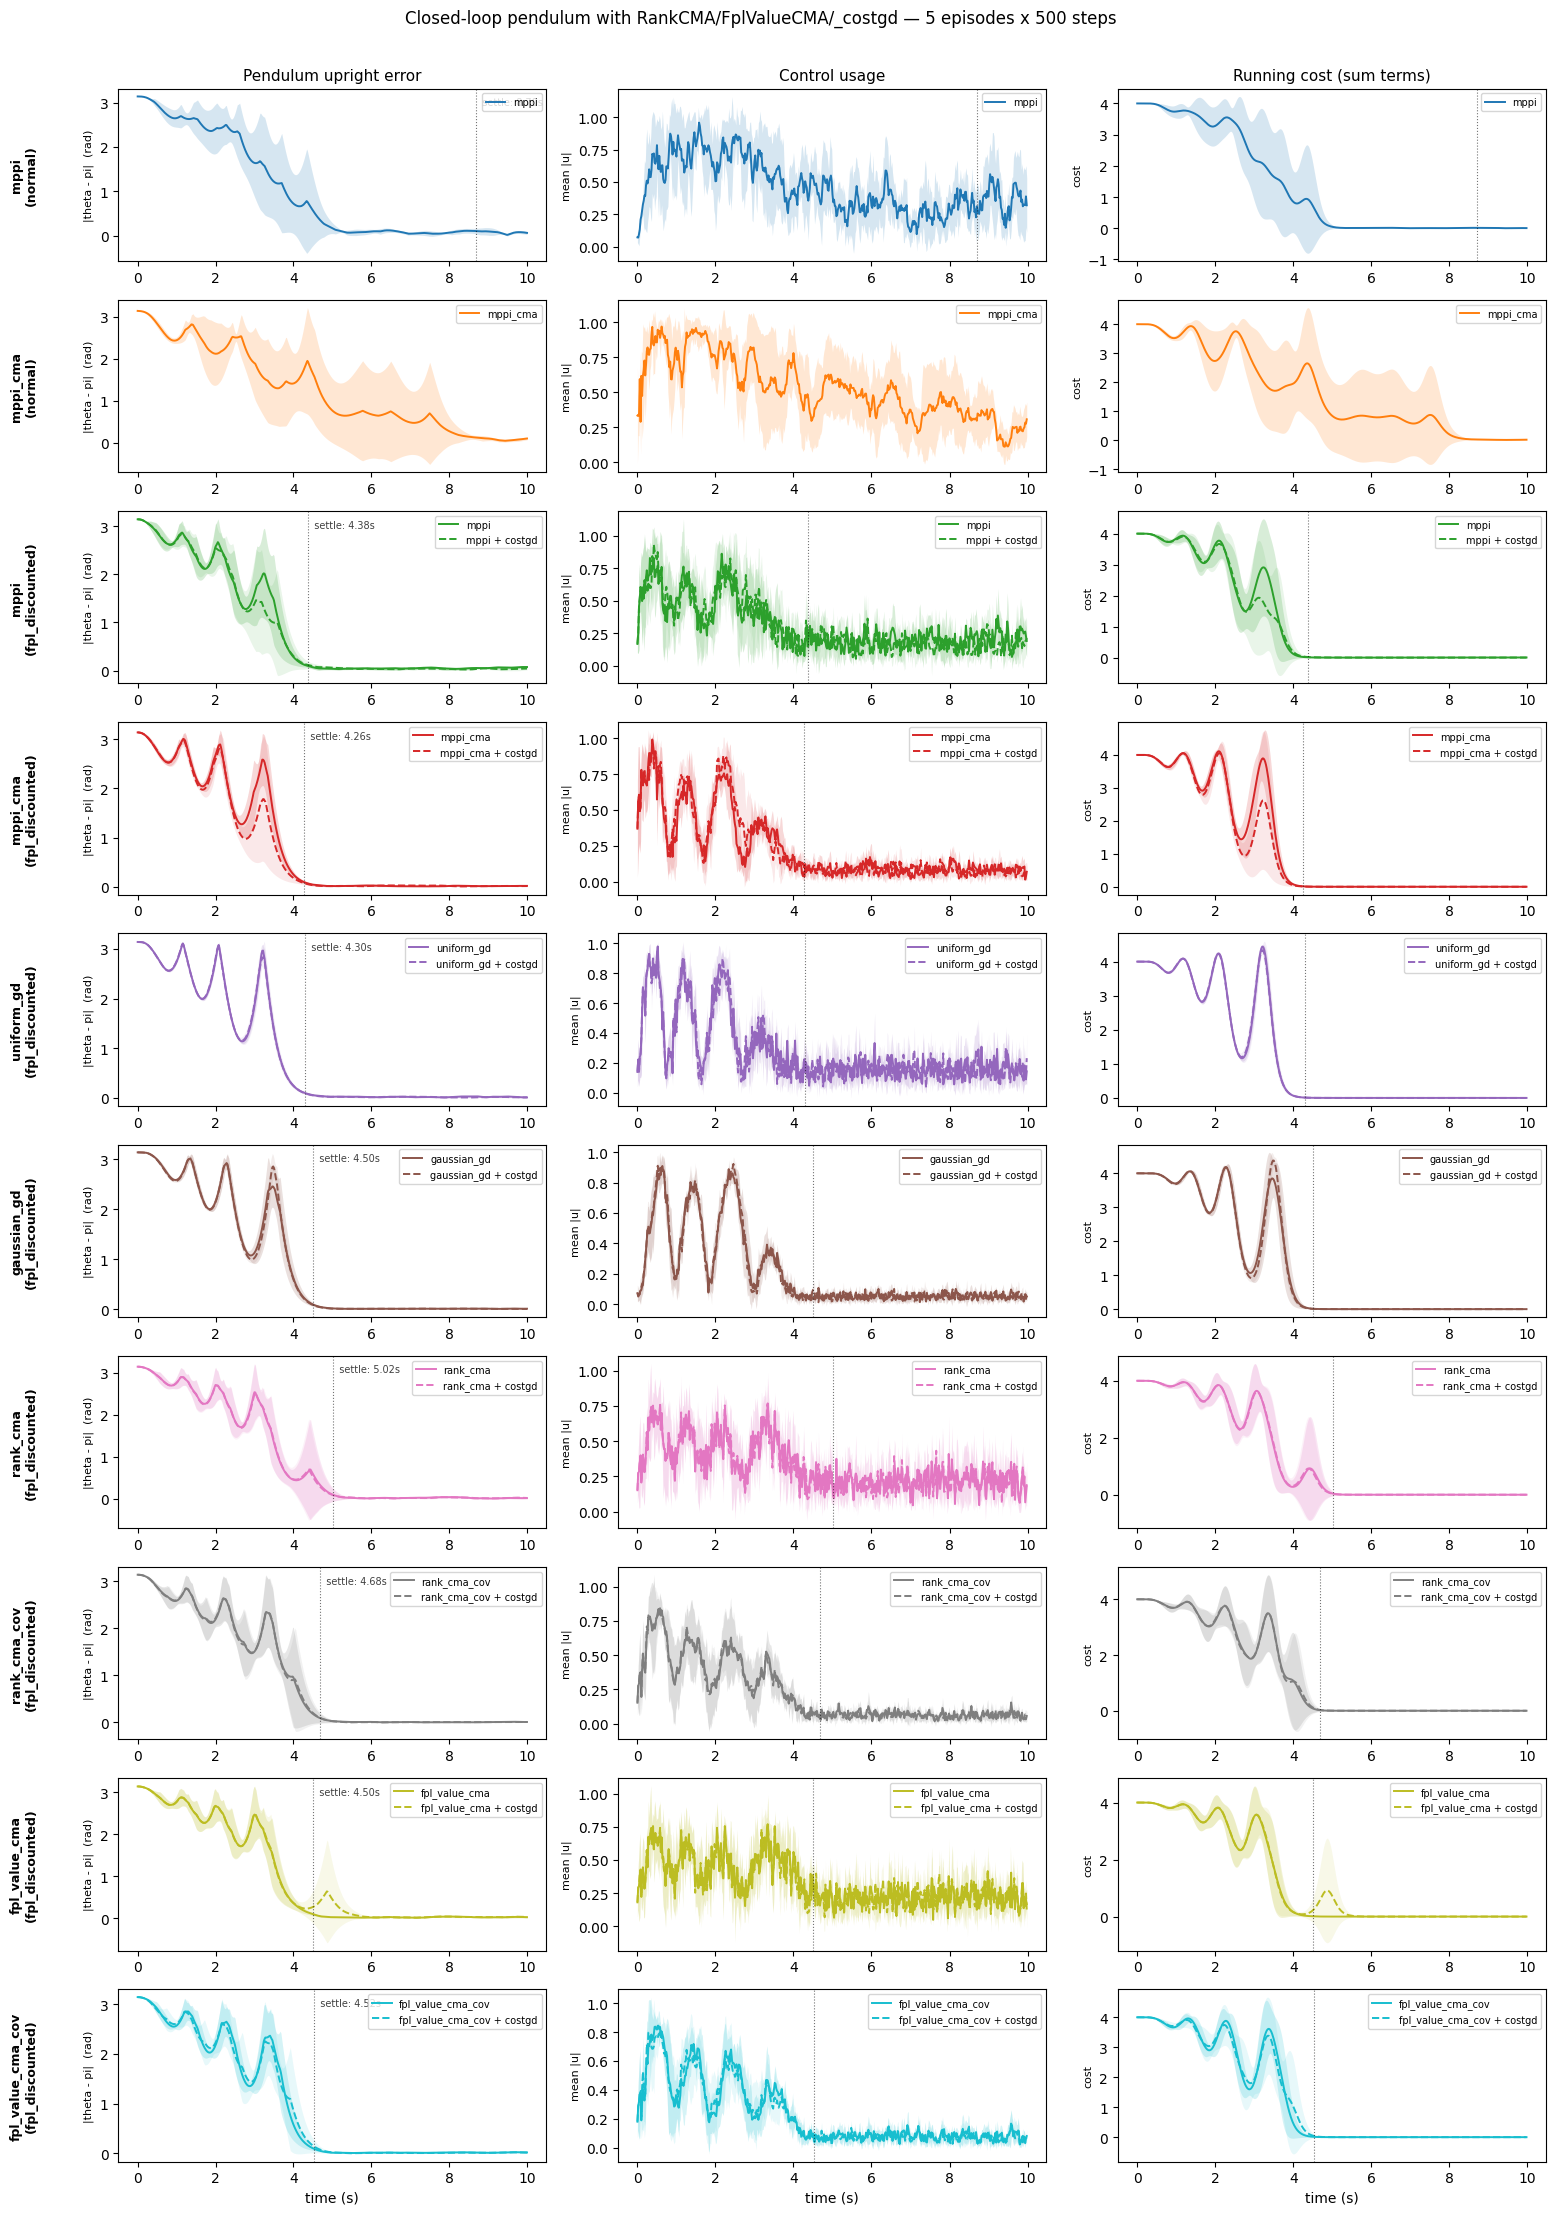


config                                            <|theta-pi|>      <cost>      <|u|>   settle (s)
mppi  (normal)                                          0.9848      1.2930     0.4605         8.70
mppi_cma  (normal)                                      1.2554      1.6612     0.5310            —
mppi  (fpl_discounted)                                  0.8791      1.1676     0.3058         4.38
mppi_cma  (fpl_discounted)                              0.8732      1.1955     0.2302         4.26
uniform_gd  (fpl_discounted)                            0.8754      1.1895     0.2726         4.30
gaussian_gd  (fpl_discounted)                           0.9244      1.2620     0.2069         4.50
rank_cma           (fpl_discounted)                     0.9567      1.2986     0.3195         5.02
rank_cma_cov       (fpl_discounted)                     0.9335      1.2807     0.2182         4.68
fpl_value_cma      (fpl_discounted)                     0.9227      1.2492     0.3260         4.50
fpl_value

In [ ]:
# Mirrors cell 36 (Part 5 multi-episode study), but over CONFIGS_RCMA. Saves to
# study_rcma so the original `study` dict is preserved.
#
# Layout: ONE ROW per (base_algo, cost_mode) family. Within each row, the base
# algo is drawn SOLID and its `_costgd` variant is drawn DASHED in the SAME
# colour, so the base-vs-cost-GD pair relationship is visually obvious at a
# glance. A black dotted vertical line marks the settling time = first t after
# which mean upright error stays below SETTLE_RAD for the rest of the episode.

SETTLE_RAD = 0.1   # rad; ~5.7 deg from upright (knob)


def _strip_costgd_suffix(algo):
    return algo[:-len("_costgd")] if algo.endswith("_costgd") else algo


def _group_configs_by_family(configs):
    """Group (label, algo, cost_mode) tuples into base / costgd pairs.

    Returns list of (family_key, base_entry_or_None, costgd_entry_or_None) preserving
    first-appearance order. family_key = (base_algo, cost_mode).
    """
    groups, order = {}, []
    for label, algo, cost_mode in configs:
        base_algo = _strip_costgd_suffix(algo)
        key = (base_algo, cost_mode)
        is_costgd = algo.endswith("_costgd")
        if key not in groups:
            groups[key] = [None, None]
            order.append(key)
        groups[key][1 if is_costgd else 0] = (label, algo, cost_mode)
    return [(k, groups[k][0], groups[k][1]) for k in order]


def _settle_time(mean_err, dt, thresh):
    """First t such that mean_err[t..] stays below `thresh` for the rest of the
    array. Returns None if the series never settles within the episode.
    """
    below = mean_err < thresh
    if not below.any():
        return None
    above_idx = np.where(~below)[0]
    if above_idx.size == 0:
        return 0.0
    last_above = int(above_idx[-1])
    if last_above + 1 >= len(mean_err):
        return None
    return (last_above + 1) * dt


if SKIP_EXPERIMENTS:
    print("[skipped] Part 1b multi-episode study (pendulum + RankCMA) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    # ---- run all configs × episodes (unchanged from the original cell) ----
    study_rcma = {}
    for label, algo, cost_mode in CONFIGS_RCMA:
        print(f"running {label:46s}", end="", flush=True)
        eps = []
        for ep in range(N_EPISODES):
            eps.append(run_episode(algo, cost_mode, seed=SEED + ep, steps=STEPS))
            print(".", end="", flush=True)
        study_rcma[label] = dict(
            states=np.stack([e["states"] for e in eps]),
            ctrls =np.stack([e["ctrls"]  for e in eps]),
            sd    =np.stack([e["sd"]     for e in eps]),
        )
        print(" done")

    # ---- plot: ONE ROW PER FAMILY, 3 columns (err, control, cost) ----
    t_axis_s = np.arange(STEPS + 1) * DT
    t_axis_u = np.arange(STEPS)     * DT
    panel_specs = [
        ("err",   "Pendulum upright error",  "|theta - pi|  (rad)", t_axis_s),
        ("u_mag", "Control usage",           "mean |u|",             t_axis_u),
        ("cost",  "Running cost (sum terms)", "cost",                 t_axis_u),
    ]

    family_groups = _group_configs_by_family(CONFIGS_RCMA)
    n_families = len(family_groups)
    cmap = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, axes = plt.subplots(n_families, 3, figsize=(16, 2.2 * n_families), squeeze=False)

    for row_idx, (family_key, base_entry, costgd_entry) in enumerate(family_groups):
        base_algo, cost_mode = family_key
        family_label = f"{base_algo}\n({cost_mode})"
        family_color = cmap[row_idx % len(cmap)]

        # Compute settling time from BASE if available, else costgd. Vertical line
        # on every panel of this row uses this single value.
        settle_t = None

        for entry, linestyle, suffix, fill_alpha in [
            (base_entry,    "-",  "",          0.18),
            (costgd_entry,  "--", " + costgd", 0.10),
        ]:
            if entry is None:
                continue
            label, algo, cm = entry
            res = study_rcma.get(label)
            if res is None:
                continue
            m = metrics_for(res)

            if settle_t is None:
                settle_t = _settle_time(m["err"].mean(axis=0), DT, SETTLE_RAD)

            for ax, (key, _, _, xs) in zip(axes[row_idx], panel_specs):
                arr = m[key]
                mu, std_ = arr.mean(axis=0), arr.std(axis=0)
                ax.plot(xs, mu, color=family_color, lw=1.4, linestyle=linestyle,
                        label=f"{base_algo}{suffix}")
                ax.fill_between(xs, mu - std_, mu + std_,
                                color=family_color, alpha=fill_alpha, lw=0)

        # Row label (family name) on the leftmost edge
        axes[row_idx, 0].text(-0.22, 0.5, family_label,
                              transform=axes[row_idx, 0].transAxes,
                              rotation=90, ha="center", va="center",
                              fontsize=9, fontweight="bold")

        for col_idx, (ax, (_, title, ylabel, _xs)) in enumerate(zip(axes[row_idx], panel_specs)):
            if row_idx == 0:
                ax.set_title(title, fontsize=11)
            if row_idx == n_families - 1:
                ax.set_xlabel("time (s)")
            ax.set_ylabel(ylabel, fontsize=8)
            ax.legend(loc="upper right", fontsize=7)

            if settle_t is not None:
                ax.axvline(settle_t, color="black", linestyle=":", lw=0.8, alpha=0.55)
                if col_idx == 0:
                    ax.text(settle_t, 0.95, f"  settle: {settle_t:.2f}s",
                            transform=ax.get_xaxis_transform(),
                            fontsize=7, va="top", ha="left",
                            color="black", alpha=0.75)

    fig.suptitle(
        f"Closed-loop pendulum with RankCMA/FplValueCMA/_costgd — {N_EPISODES} episodes x {STEPS} steps",
        y=1.005, fontsize=12,
    )
    fig.tight_layout(rect=[0.03, 0, 1, 1])
    plt.show()

    # --- summary table ---
    print(f"\n{'config':46s}  {'<|theta-pi|>':>14s}  {'<cost>':>10s}  {'<|u|>':>9s}  {'settle (s)':>11s}")
    for label, res in study_rcma.items():
        m = metrics_for(res)
        st = _settle_time(m["err"].mean(axis=0), DT, SETTLE_RAD)
        st_str = f"{st:.2f}" if st is not None else " —"
        print(f"{label:46s}  "
              f"{m['err'].mean():14.4f}  "
              f"{m['cost'].mean():10.4f}  "
              f"{m['u_mag'].mean():9.4f}  "
              f"{st_str:>11s}")


## Part 1c — Closed-loop walker comparison with RankCMA added (Part 6 redux)

Same task / steps / horizon / K / seeds as Part 6, just with `rank_cma  (fpl_discounted)`
appended to `CONFIGS_W`. Reuses `make_ctrl_walker` (monkey-patched in the MGD section
to dispatch `algo="rank_cma"`), `run_and_record_walker`, `run_episode_walker`, and
`metrics_for_walker` from Part 6 — make sure Part 6 was run first so those names exist.
The walker is the real "multivariate" test case for RankCMA since `nu = 6` makes
the per-step `(nu, nu)` covariance non-trivial (the pendulum has `nu = 1`, so its
"covariance" is just a per-step variance).


In [ ]:
# Walker — RankCMA / FplValueCMA / Part-1d-costgd augmented config list.
CONFIGS_W_RCMA = list(CONFIGS_W) + [
    ("rank_cma           (fpl_discounted)", "rank_cma",           "fpl_discounted"),
    ("rank_cma_cov       (fpl_discounted)", "rank_cma_cov",       "fpl_discounted"),
    ("fpl_value_cma      (fpl_discounted)", "fpl_value_cma",      "fpl_discounted"),
    ("fpl_value_cma_cov  (fpl_discounted)", "fpl_value_cma_cov",  "fpl_discounted"),
    # --- Part 1d: _costgd variants (cost-GD on top-mu rollouts per MPC step) ---
    ("mppi_costgd                (fpl_discounted)", "mppi_costgd",                "fpl_discounted"),
    ("mppi_cma_costgd            (fpl_discounted)", "mppi_cma_costgd",            "fpl_discounted"),
    ("rank_cma_costgd            (fpl_discounted)", "rank_cma_costgd",            "fpl_discounted"),
    ("rank_cma_cov_costgd        (fpl_discounted)", "rank_cma_cov_costgd",        "fpl_discounted"),
    ("fpl_value_cma_costgd       (fpl_discounted)", "fpl_value_cma_costgd",       "fpl_discounted"),
    ("fpl_value_cma_cov_costgd   (fpl_discounted)", "fpl_value_cma_cov_costgd",   "fpl_discounted"),
    ("uniform_gd_costgd          (fpl_discounted)", "uniform_gd_costgd",          "fpl_discounted"),
    ("gaussian_gd_costgd         (fpl_discounted)", "gaussian_gd_costgd",         "fpl_discounted"),
]

print(f"W_STEPS = {W_STEPS}    W_K = {W_K}    plan_horizon = {W_PLAN_HORIZON}s    "
      f"fpl(p={W_FPL_P}, gamma={W_FPL_GAMMA})    beta={W_RCMA_BETA}    "
      f"costgd_iters={W_MPC_GD_ITERATIONS} lr={W_MPC_GD_LR}\n")
for label, algo, cost_mode in CONFIGS_W_RCMA:
    t, b, c = make_ctrl_walker(algo, cost_mode)
    print(f"  {label:48s} -> {type(c).__name__:15s} K={c.num_samples} num_knots={c.num_knots} H={c.H}")


W_STEPS = 1000    W_K = 128    plan_horizon = 1.0s    fpl(p=0.1, gamma=0.99)    beta=25.0    costgd_iters=2 lr=0.05

  mppi  (normal)                                   -> MPPIv2          K=128 num_knots=6 H=100
  mppi_cma  (normal)                               -> MppiCma         K=128 num_knots=6 H=100
  mppi  (fpl_discounted)                           -> MPPIv2          K=128 num_knots=6 H=100
  mppi_cma  (fpl_discounted)                       -> MppiCma         K=128 num_knots=6 H=100
  uniform_gd  (fpl_discounted)                     -> UniformGD       K=128 num_knots=100 H=100
  gaussian_gd  (fpl_discounted)                    -> GaussianGD      K=128 num_knots=100 H=100
  rank_cma           (fpl_discounted)              -> RankCMA         K=128 num_knots=100 H=100
  rank_cma_cov       (fpl_discounted)              -> RankCMA         K=128 num_knots=100 H=100
  fpl_value_cma      (fpl_discounted)              -> FplValueCMA     K=128 num_knots=100 H=100
  fpl_value_cma_cov  (fpl_d

In [ ]:
# Mirrors cell 42 (Part 6 video rendering), but over CONFIGS_W_RCMA.
# Writes mp4s to a separate dir so the Part 6 outputs aren\'t overwritten.
W_RCMA_OUT_DIR = Path("/tmp/analytic_mppi_part1c")
W_RCMA_OUT_DIR.mkdir(parents=True, exist_ok=True)

if SKIP_EXPERIMENTS:
    print("[skipped] Part 1c video rendering (walker + RankCMA) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    results_w_rcma = {}
    for label, algo, cost_mode in CONFIGS_W_RCMA:
        t, b, c = make_ctrl_walker(algo, cost_mode)
        out = W_RCMA_OUT_DIR / f"walker_{_slug(label)}.mp4"
        print(f"running {label:36s} -> {out.name} ...", end="", flush=True)
        res = run_and_record_walker(label, t, b, c, steps=W_STEPS, out_path=out)
        results_w_rcma[label] = res
        print(f"  done.  plan={res['plan_ms']:.1f} ms/step")


    # --- end-of-episode summary ---
    print()
    print(f"{'config':40s}  {'x_end (m)':>10s}  {'|delta vx|_end':>14s}  {'z_end (m)':>10s}  {'plan ms/step':>14s}")
    for label, res in results_w_rcma.items():
        sd_end = res["sd"][-1]
        x_end  = float(sd_end[_task_ref_w._pos_adr])
        z_end  = float(sd_end[_task_ref_w._pos_adr + 2])
        vx_end = float(sd_end[_task_ref_w._vel_adr])
        dvx    = abs(vx_end - _task_ref_w.target_velocity)
        print(f"{label:40s}  {x_end:10.3f}  {dvx:14.3f}  {z_end:10.3f}  {res['plan_ms']:14.1f}")


    # --- embed all videos inline ---
    display(HTML(f"<h4>Walker forward locomotion with RankCMA &mdash; K={W_K}, steps={W_STEPS}, "
                 f"target v*={_task_ref_w.target_velocity} m/s, z*={_task_ref_w.target_height} m</h4>"))
    for label, res in results_w_rcma.items():
        display(HTML(f"<b>{label}</b> &mdash; <code>{res['path'].name}</code>"))
        display(Video(str(res["path"]), embed=True, width=480))


running mppi  (normal)                       -> walker_mppinormal.mp4 ...  done.  plan=5.5 ms/step
running mppi_cma  (normal)                   -> walker_mppi_cmanormal.mp4 ...  done.  plan=5.8 ms/step
running mppi  (fpl_discounted)               -> walker_mppifpl_discounted.mp4 ...  done.  plan=5.8 ms/step
running mppi_cma  (fpl_discounted)           -> walker_mppi_cmafpl_discounted.mp4 ...  done.  plan=6.3 ms/step
running uniform_gd  (fpl_discounted)         -> walker_uniform_gdfpl_discounted.mp4 ...  done.  plan=8.5 ms/step
running gaussian_gd  (fpl_discounted)        -> walker_gaussian_gdfpl_discounted.mp4 ...  done.  plan=8.9 ms/step
running rank_cma           (fpl_discounted)  -> walker_rank_cmafpl_discounted.mp4 ...  done.  plan=11.3 ms/step
running rank_cma_cov       (fpl_discounted)  -> walker_rank_cma_covfpl_discounted.mp4 ...  done.  plan=13.3 ms/step
running fpl_value_cma      (fpl_discounted)  -> walker_fpl_value_cmafpl_discounted.mp4 ...  done.  plan=11.4 ms/step
running 

In [ ]:
# Mirrors cell 41 (Part 6 multi-episode study), but over CONFIGS_W_RCMA. Saves
# to study_w_rcma. Same row-per-family layout as Part 1b above; settling time
# uses velocity-tracking error (since walker is locomoting, not stabilising).

W_SETTLE_VEL = 0.2   # m/s; vel tracking tolerance for settling (knob)


# Helpers re-defined here so the cell is self-contained (no dependency on Part 1b
# having been executed first).
def _strip_costgd_suffix(algo):
    return algo[:-len("_costgd")] if algo.endswith("_costgd") else algo


def _group_configs_by_family(configs):
    groups, order = {}, []
    for label, algo, cost_mode in configs:
        base_algo = _strip_costgd_suffix(algo)
        key = (base_algo, cost_mode)
        is_costgd = algo.endswith("_costgd")
        if key not in groups:
            groups[key] = [None, None]
            order.append(key)
        groups[key][1 if is_costgd else 0] = (label, algo, cost_mode)
    return [(k, groups[k][0], groups[k][1]) for k in order]


def _settle_time(mean_err, dt, thresh):
    below = mean_err < thresh
    if not below.any():
        return None
    above_idx = np.where(~below)[0]
    if above_idx.size == 0:
        return 0.0
    last_above = int(above_idx[-1])
    if last_above + 1 >= len(mean_err):
        return None
    return (last_above + 1) * dt


if SKIP_EXPERIMENTS:
    print("[skipped] Part 1c multi-episode study (walker + RankCMA) — set SKIP_EXPERIMENTS=False in cell 33 to run")
else:
    study_w_rcma = {}
    for label, algo, cost_mode in CONFIGS_W_RCMA:
        print(f"running {label:46s}", end="", flush=True)
        eps = []
        for ep in range(W_N_EPISODES):
            eps.append(run_episode_walker(algo, cost_mode, seed=W_SEED + ep, steps=W_STEPS))
            print(".", end="", flush=True)
        study_w_rcma[label] = dict(
            states=np.stack([e["states"] for e in eps]),
            ctrls =np.stack([e["ctrls"]  for e in eps]),
            sd    =np.stack([e["sd"]     for e in eps]),
        )
        print(" done")

    # ---- plot: ONE ROW PER FAMILY, 4 columns (height, vel, upright, control) ----
    t_axis_w = np.arange(W_STEPS) * W_DT
    panel_specs_w = [
        ("height_err", "Height tracking",    "|z - z*|  (m)",            t_axis_w),
        ("vel_err",    "Forward velocity",   "|vx - v*|  (m/s)",         t_axis_w),
        ("upright",    "Torso uprightness",  "torso . z_hat (1=upright)", t_axis_w),
        ("u_mag",      "Control usage",      "mean |u|",                 t_axis_w),
    ]

    family_groups_w = _group_configs_by_family(CONFIGS_W_RCMA)
    n_families_w = len(family_groups_w)
    cmap = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, axes = plt.subplots(n_families_w, 4, figsize=(20, 2.2 * n_families_w), squeeze=False)

    for row_idx, (family_key, base_entry, costgd_entry) in enumerate(family_groups_w):
        base_algo, cost_mode = family_key
        family_label = f"{base_algo}\n({cost_mode})"
        family_color = cmap[row_idx % len(cmap)]

        settle_t = None

        for entry, linestyle, suffix, fill_alpha in [
            (base_entry,   "-",  "",          0.18),
            (costgd_entry, "--", " + costgd", 0.10),
        ]:
            if entry is None:
                continue
            label, algo, cm = entry
            res = study_w_rcma.get(label)
            if res is None:
                continue
            m = metrics_for_walker(res)

            if settle_t is None:
                settle_t = _settle_time(m["vel_err"].mean(axis=0), W_DT, W_SETTLE_VEL)

            for ax, (key, _, _, xs) in zip(axes[row_idx], panel_specs_w):
                arr = m[key]
                mu, std_ = arr.mean(axis=0), arr.std(axis=0)
                ax.plot(xs, mu, color=family_color, lw=1.4, linestyle=linestyle,
                        label=f"{base_algo}{suffix}")
                ax.fill_between(xs, mu - std_, mu + std_,
                                color=family_color, alpha=fill_alpha, lw=0)

        axes[row_idx, 0].text(-0.20, 0.5, family_label,
                              transform=axes[row_idx, 0].transAxes,
                              rotation=90, ha="center", va="center",
                              fontsize=9, fontweight="bold")

        for col_idx, (ax, (_, title, ylabel, _xs)) in enumerate(zip(axes[row_idx], panel_specs_w)):
            if row_idx == 0:
                ax.set_title(title, fontsize=11)
            if row_idx == n_families_w - 1:
                ax.set_xlabel("time (s)")
            ax.set_ylabel(ylabel, fontsize=8)
            ax.legend(loc="upper right", fontsize=7)

            if settle_t is not None:
                ax.axvline(settle_t, color="black", linestyle=":", lw=0.8, alpha=0.55)
                if col_idx == 0:
                    ax.text(settle_t, 0.95, f"  settle: {settle_t:.2f}s",
                            transform=ax.get_xaxis_transform(),
                            fontsize=7, va="top", ha="left",
                            color="black", alpha=0.75)

    fig.suptitle(
        f"Walker closed-loop with RankCMA/FplValueCMA/_costgd — {W_N_EPISODES} episodes x {W_STEPS} steps",
        y=1.005, fontsize=12,
    )
    fig.tight_layout(rect=[0.03, 0, 1, 1])
    plt.show()

    # --- summary table ---
    print(f"\n{'config':46s}  {'<|dz|>':>9s}  {'<|dvx|>':>9s}  {'<upright>':>10s}  {'<|u|>':>8s}  {'settle (s)':>11s}")
    for label, res in study_w_rcma.items():
        m = metrics_for_walker(res)
        st = _settle_time(m["vel_err"].mean(axis=0), W_DT, W_SETTLE_VEL)
        st_str = f"{st:.2f}" if st is not None else " —"
        print(f"{label:46s}  "
              f"{m['height_err'].mean():9.4f}  "
              f"{m['vel_err'].mean():9.4f}  "
              f"{m['upright'].mean():10.4f}  "
              f"{m['u_mag'].mean():8.4f}  "
              f"{st_str:>11s}")


[skipped] Part 1c multi-episode study (walker + RankCMA) — set SKIP_EXPERIMENTS=False in cell 33 to run
